Heatmaps generated successfully!

Data Overview:
- Minibus Capacities: [np.int64(6), np.int64(8)]
- Minibus Ratios: [np.float64(0.01), np.float64(0.03), np.float64(0.05)]
- Total Experiments: 120


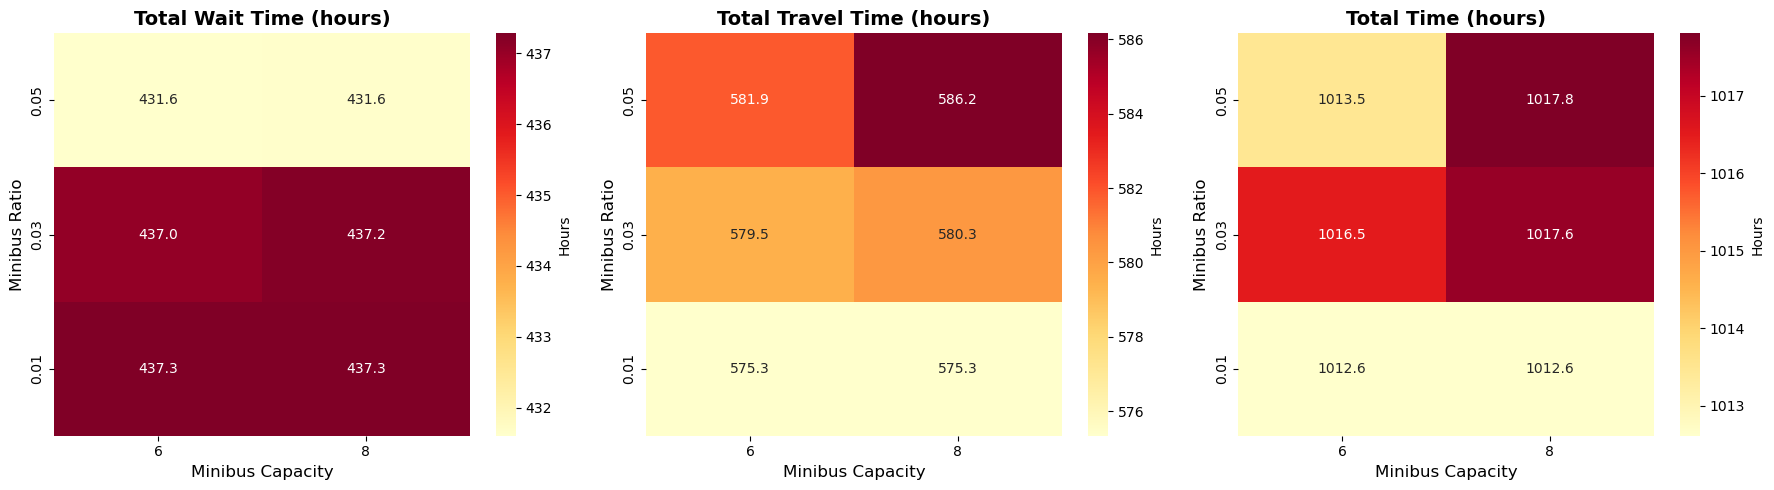

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('batch_results/Minibus_ratio_results_pre/experiment_summary.csv')

# Create three heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data - create pivot tables for each metric
metrics = [
    ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
    ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
    ('total_total_time_hours', 'Total Time (hours)', axes[2])
]

for metric_col, title, ax in metrics:
    # Create pivot table with capacity as columns
    pivot_data = df.pivot_table(
        values=metric_col,
        index='minibus_ratio',
        columns='minibus_capacity',
        aggfunc='mean'
    )
    
    # Plot heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax,
        cbar_kws={'label': 'Hours'}
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Minibus Capacity', fontsize=12)
    ax.set_ylabel('Minibus Ratio', fontsize=12)
    
    # Invert y-axis so ratio goes from small to large
    ax.invert_yaxis()

plt.tight_layout()


print("Heatmaps generated successfully!")
print(f"\nData Overview:")
print(f"- Minibus Capacities: {sorted(df['minibus_capacity'].unique())}")
print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
print(f"- Total Experiments: {len(df)}")

3D heatmaps generated successfully!

Data Overview:
- Minibus Capacities: [np.int64(6), np.int64(8)]
- Minibus Ratios: [np.float64(0.01), np.float64(0.03), np.float64(0.05)]
- Number of Minibuses: [np.int64(1), np.int64(2), np.int64(3), np.int64(5)]
- Total Experiments: 120


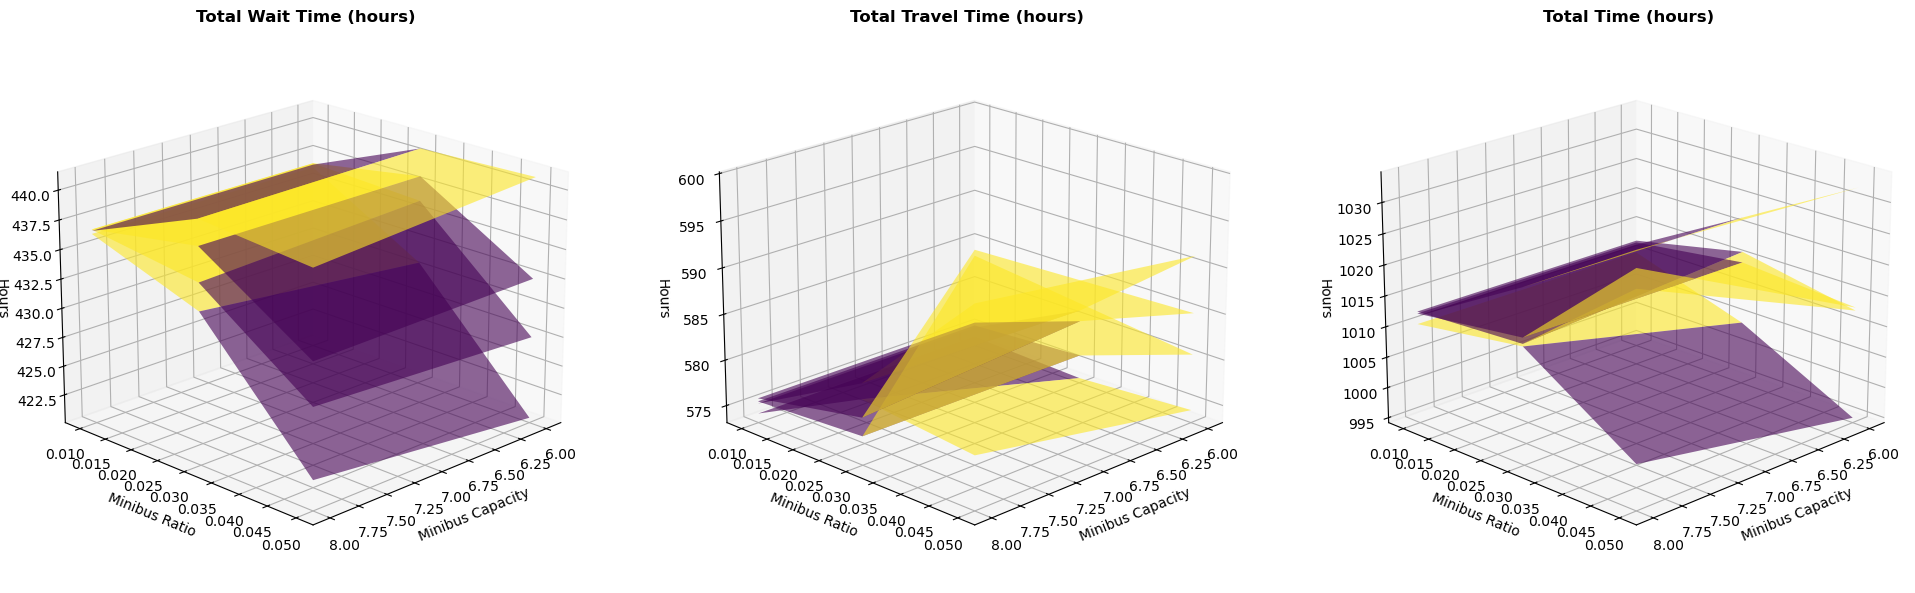

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Read CSV file
df = pd.read_csv('batch_results/Minibus_ratio_results_pre/experiment_summary.csv')

# Create figure with 3 subplots for 3D visualization
fig = plt.figure(figsize=(20, 6))

# Metrics to plot
metrics = [
    ('total_wait_time_hours', 'Total Wait Time (hours)'),
    ('total_travel_time_hours', 'Total Travel Time (hours)'),
    ('total_total_time_hours', 'Total Time (hours)')
]

for idx, (metric_col, title) in enumerate(metrics, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    
    # Get unique values for each dimension
    capacities = sorted(df['minibus_capacity'].unique())
    ratios = sorted(df['minibus_ratio'].unique())
    num_minibuses = sorted(df['num_minibuses'].unique())
    
    # Create meshgrid
    X, Y = np.meshgrid(capacities, ratios)
    
    # Create Z values for each num_minibuses
    for n_buses in num_minibuses:
        Z = np.zeros_like(X, dtype=float)
        
        for i, ratio in enumerate(ratios):
            for j, capacity in enumerate(capacities):
                # Find matching row
                mask = (df['minibus_capacity'] == capacity) & \
                       (df['minibus_ratio'] == ratio) & \
                       (df['num_minibuses'] == n_buses)
                
                if mask.any():
                    Z[i, j] = df.loc[mask, metric_col].values[0]
                else:
                    Z[i, j] = np.nan
        
        # Plot surface for this num_minibuses
        surf = ax.plot_surface(X, Y, Z, alpha=0.6, cmap=cm.viridis, 
                               label=f'n={n_buses}', edgecolor='none')
    
    ax.set_xlabel('Minibus Capacity', fontsize=10)
    ax.set_ylabel('Minibus Ratio', fontsize=10)
    ax.set_zlabel('Hours', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Adjust viewing angle
    ax.view_init(elev=20, azim=45)

plt.tight_layout()


print("3D heatmaps generated successfully!")
print(f"\nData Overview:")
print(f"- Minibus Capacities: {sorted(df['minibus_capacity'].unique())}")
print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
print(f"- Number of Minibuses: {sorted(df['num_minibuses'].unique())}")
print(f"- Total Experiments: {len(df)}")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('batch_results/Minibus_ratio_results/experiment_summary.csv')

# Create a label column for display
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)

# Create a sorting key to control the order (2×6, 2×8, 2×10, 3×6, 3×8, 3×10)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("Unique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']].drop_duplicates().sort_values('sort_key'))

# Create three heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Prepare data - create pivot tables for each metric
metrics = [
    ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
    ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
    ('total_total_time_hours', 'Total Time (hours)', axes[2])
]

for metric_col, title, ax in metrics:
    # Create pivot table with capacity_label as columns
    pivot_data = df.pivot_table(
        values=metric_col,
        index='minibus_ratio',
        columns='sort_key',
        aggfunc='mean'
    )
    
    # Create mapping from sort_key to display label
    label_mapping = df[['sort_key', 'capacity_label']].drop_duplicates().set_index('sort_key')['capacity_label'].to_dict()
    
    # Rename columns to display labels
    pivot_data.columns = [label_mapping[col] for col in pivot_data.columns]
    
    # Plot heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt='.1f',
        cmap='YlOrRd',
        ax=ax,
        cbar_kws={'label': 'Hours'}
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Number × Capacity', fontsize=12)
    ax.set_ylabel('Minibus Ratio', fontsize=12)
    
    # Invert y-axis so ratio goes from small to large
    ax.invert_yaxis()

plt.tight_layout()

print("\nHeatmaps generated successfully!")
print(f"\nData Overview:")
print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
print(f"- Total Experiments: {len(df)}")

FileNotFoundError: [Errno 2] No such file or directory: 'batch_results/Minibus_ratio_results/experiment_summary.csv'

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('batch_results/Minibus_ratio_results/experiment_summary.csv')

# Check if optimization_interval column exists
if 'optimization_interval' not in df.columns:
    print("Warning: 'optimization_interval' column not found. Using original visualization.")
    has_optimize_interval = False
else:
    has_optimize_interval = True
    print(f"Found optimization_interval values: {sorted(df['optimization_interval'].unique())}")

# Create a label column for display
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)

# Create a sorting key to control the order (2×6, 2×8, 2×10, 3×6, 3×8, 3×10)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("\nUnique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']].drop_duplicates().sort_values('sort_key'))

# ============================================================================
# OPTION 1: Separate plots for each optimization_interval
# ============================================================================
if has_optimize_interval:
    optimize_intervals = sorted(df['optimization_interval'].unique())
    
    for opt_interval in optimize_intervals:
        # Filter data for this optimization_interval
        df_filtered = df[df['optimization_interval'] == opt_interval]
        
        # Create three heatmaps
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Optimize Interval = {opt_interval}s ({opt_interval//60} min)', 
                     fontsize=16, fontweight='bold', y=1.02)
        
        # Prepare data - create pivot tables for each metric
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time (hours)', axes[2])
        ]
        
        for metric_col, title, ax in metrics:
            # Create pivot table with capacity_label as columns
            pivot_data = df_filtered.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='sort_key',
                aggfunc='mean'
            )
            
            # Create mapping from sort_key to display label
            label_mapping = df_filtered[['sort_key', 'capacity_label']].drop_duplicates().set_index('sort_key')['capacity_label'].to_dict()
            
            # Rename columns to display labels
            pivot_data.columns = [label_mapping[col] for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel('Number × Capacity', fontsize=12)
            ax.set_ylabel('Minibus Ratio', fontsize=12)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        plt.tight_layout()
        # plt.savefig(f'heatmap_opt_{opt_interval}s.png', dpi=300, bbox_inches='tight')
        # print(f"\nSaved: heatmap_opt_{opt_interval}s.png")

# ============================================================================
# OPTION 2: Combined comparison plots showing effect of optimization_interval
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating comparison plots across optimize intervals...")
    print("="*70)
    
    # For each capacity configuration, show how metrics vary with optimization_interval and ratio
    capacity_configs = df.groupby(['num_minibuses', 'minibus_capacity']).size().index.tolist()
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f'Configuration: {num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=1.02)
        
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time (hours)', axes[2])
        ]
        
        for metric_col, title, ax in metrics:
            # Create pivot table: ratio vs optimization_interval
            pivot_data = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            
            # Rename columns to show minutes
            pivot_data.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=12)
            ax.set_ylabel('Minibus Ratio', fontsize=12)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        plt.tight_layout()
        filename = f'comparison_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# OPTION 3: Line plots showing trends
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating line plots showing trends...")
    print("="*70)
    
    # Create line plots for each metric
    metrics_to_plot = [
        ('total_wait_time_hours', 'Total Wait Time (hours)'),
        ('total_travel_time_hours', 'Total Travel Time (hours)'),
        ('total_total_time_hours', 'Total Time (hours)'),
        ('service_rate', 'Service Rate (%)')
    ]
    
    for metric_col, metric_name in metrics_to_plot:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'{metric_name} - Effect of Optimize Interval', 
                     fontsize=16, fontweight='bold', y=1.00)
        axes = axes.flatten()
        
        # For each capacity configuration
        for idx, (num_minibuses, capacity) in enumerate(capacity_configs):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            df_config = df[(df['num_minibuses'] == num_minibuses) & 
                           (df['minibus_capacity'] == capacity)]
            
            # Plot lines for each minibus_ratio
            for ratio in sorted(df_config['minibus_ratio'].unique()):
                df_ratio = df_config[df_config['minibus_ratio'] == ratio]
                df_ratio_sorted = df_ratio.sort_values('optimization_interval')
                
                ax.plot(df_ratio_sorted['optimization_interval'], 
                       df_ratio_sorted[metric_col],
                       marker='o', 
                       label=f'Ratio {ratio}',
                       linewidth=2,
                       markersize=6)
            
            ax.set_title(f'{num_minibuses} Minibuses × {capacity} Capacity', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval (seconds)', fontsize=10)
            ax.set_ylabel(metric_name, fontsize=10)
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add secondary x-axis showing minutes
            ax2 = ax.twiny()
            ax2.set_xlim(ax.get_xlim())
            ax2.set_xticks(ax.get_xticks())
            ax2.set_xticklabels([f'{int(x//60)}min' for x in ax.get_xticks()], fontsize=8)
        
        # Hide unused subplots
        for idx in range(len(capacity_configs), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        filename = f'lineplot_{metric_col}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# Summary Statistics
# ============================================================================
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

if has_optimize_interval:
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Optimize Intervals: {sorted(df['optimization_interval'].unique())} seconds")
    print(f"- Total Experiments: {len(df)}")
    
    # Find best configurations for each metric
    print("\n" + "-"*70)
    print("BEST CONFIGURATIONS (lowest values):")
    print("-"*70)
    
    for metric_col, metric_name in [
        ('total_wait_time_hours', 'Total Wait Time'),
        ('total_travel_time_hours', 'Total Travel Time'),
        ('total_total_time_hours', 'Total Time')
    ]:
        best_row = df.loc[df[metric_col].idxmin()]
        print(f"\n{metric_name}:")
        print(f"  Value: {best_row[metric_col]:.2f} hours")
        print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
        print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
        print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Best service rate
    best_row = df.loc[df['service_rate'].idxmax()]
    print(f"\nService Rate (highest):")
    print(f"  Value: {best_row['service_rate']:.2f}%")
    print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
    print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
    print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Effect of optimization_interval
    print("\n" + "-"*70)
    print("EFFECT OF OPTIMIZE INTERVAL (averaged across all configs):")
    print("-"*70)
    
    interval_stats = df.groupby('optimization_interval').agg({
        'total_wait_time_hours': 'mean',
        'total_travel_time_hours': 'mean',
        'total_total_time_hours': 'mean',
        'service_rate': 'mean'
    }).round(2)
    
    print("\n" + interval_stats.to_string())

else:
    # Original summary for data without optimization_interval
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Total Experiments: {len(df)}")

print("\n" + "="*70)
print("All visualizations generated successfully!")
print("="*70)

FileNotFoundError: [Errno 2] No such file or directory: 'batch_results/Minibus_ratio_results/experiment_summary.csv'

Found optimization_interval values: [np.int64(30), np.int64(60), np.int64(120), np.int64(240), np.int64(300)]
Found vehicle-specific total time columns!

Unique capacity labels:
     num_minibuses  minibus_capacity capacity_label  sort_key
0                1                 6            1×6       106
15               1                 8            1×8       108
30               2                 6            2×6       206
45               2                 8            2×8       208
60               3                 6            3×6       306
75               3                 8            3×8       308
90               5                 6            5×6       506
105              5                 8            5×8       508

Creating comparison plots across optimize intervals...

Creating line plots showing trends...

Creating Bus vs Minibus comparison plots...


/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_16610/315875613.py:333: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_config['time_difference'] = df_config['bus_total_total_time_hours'] - df_config['minibus_total_total_time_hours']
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_16610/315875613.py:266: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(16, 12))
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_1661


Creating average time per passenger comparison...

SUMMARY STATISTICS

Data Overview:
- Capacity combinations: ['1×6', '1×8', '2×6', '2×8', '3×6', '3×8', '5×6', '5×8']
- Minibus Ratios: [np.float64(0.01), np.float64(0.03), np.float64(0.05)]
- Optimize Intervals: [np.int64(30), np.int64(60), np.int64(120), np.int64(240), np.int64(300)] seconds
- Total Experiments: 120

----------------------------------------------------------------------
BEST CONFIGURATIONS (lowest values):
----------------------------------------------------------------------

Total Wait Time:
  Value: 420.49 hours
  Configuration: 1 minibuses × 6 capacity
  Ratio: 0.05
  Optimize Interval: 30s (0 min)

Total Travel Time:
  Value: 567.20 hours
  Configuration: 1 minibuses × 8 capacity
  Ratio: 0.03
  Optimize Interval: 120s (2 min)

Total Time - All:
  Value: 991.32 hours
  Configuration: 1 minibuses × 6 capacity
  Ratio: 0.05
  Optimize Interval: 60s (1 min)

Total Time - Bus Only:
  Value: 963.29 hours
  Configurat

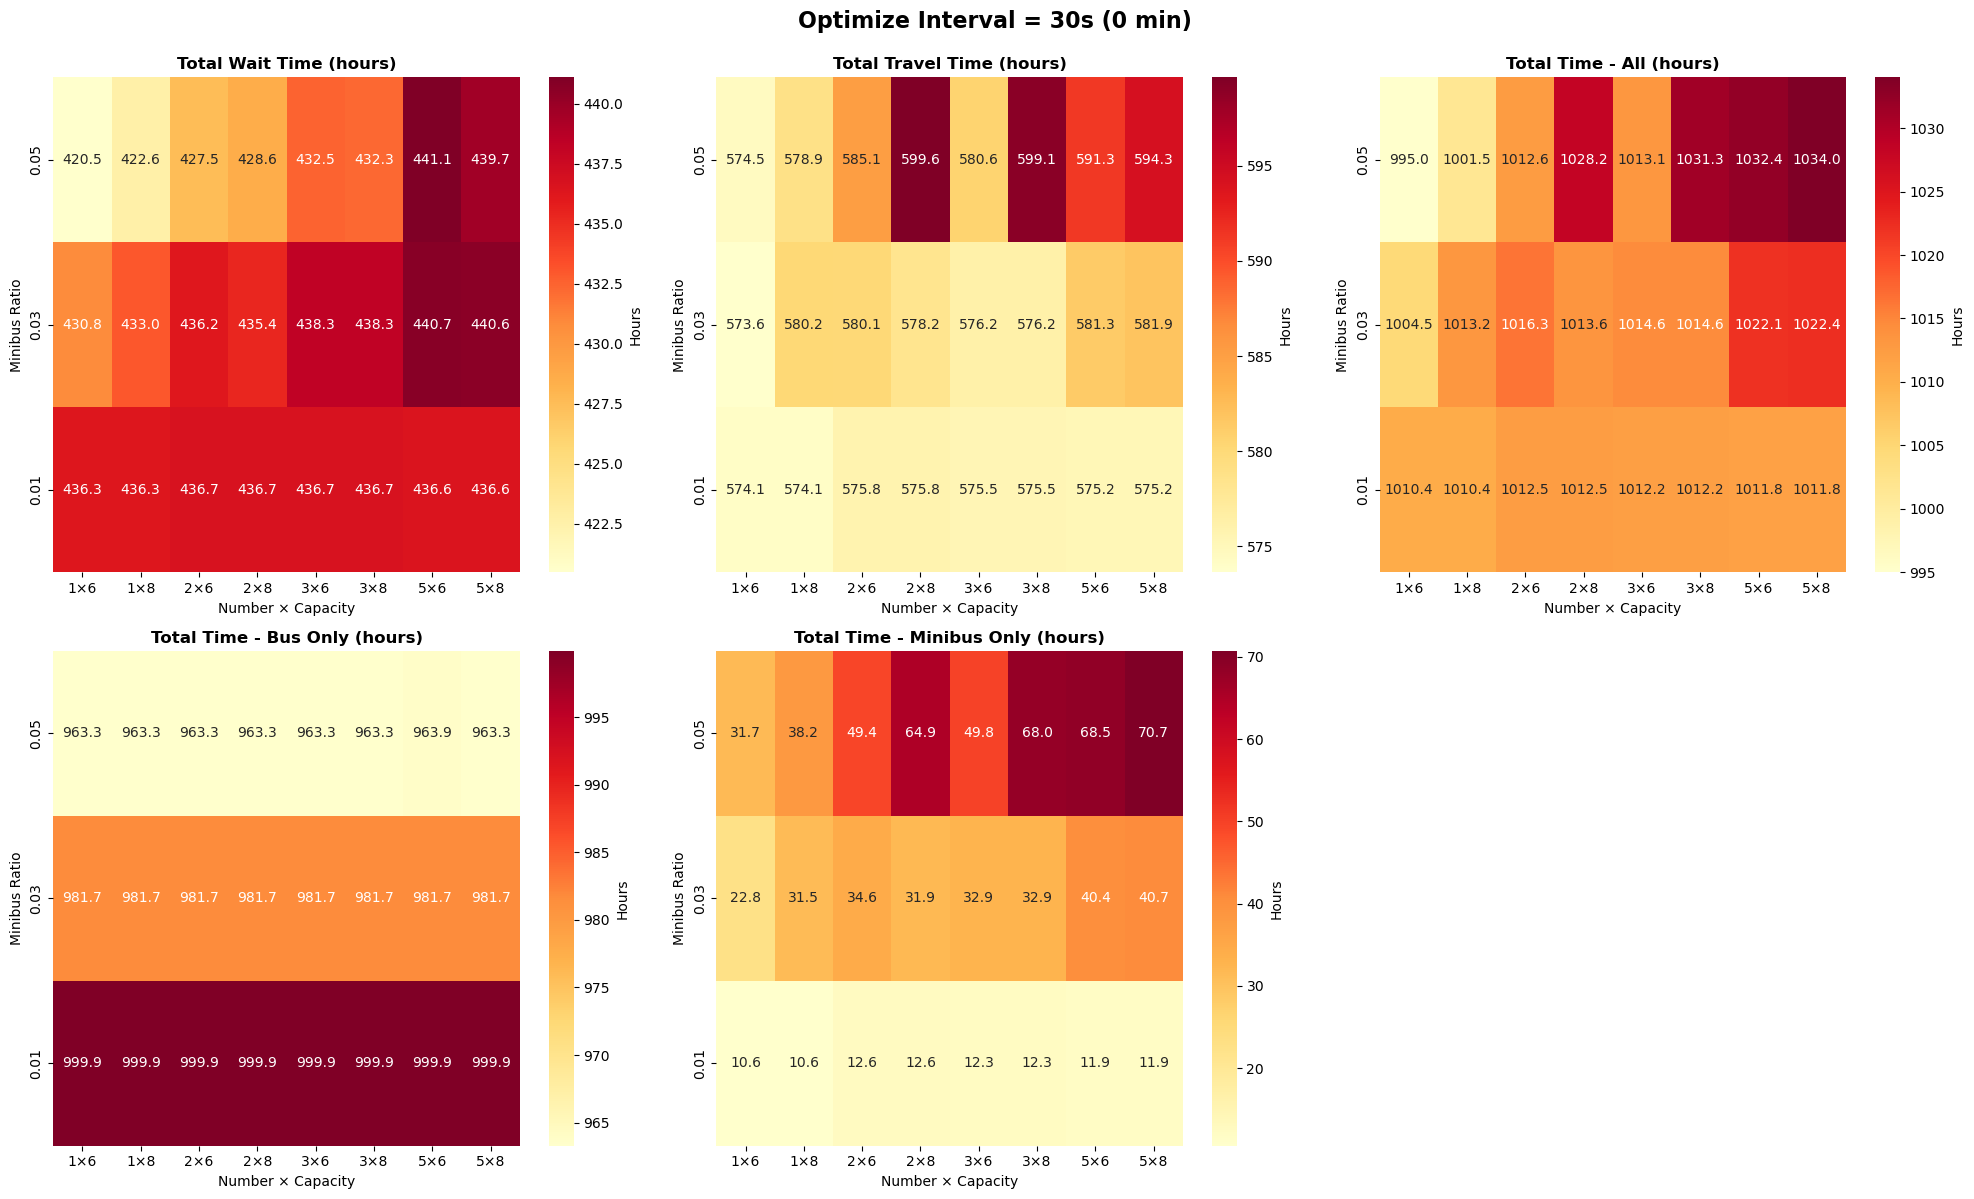

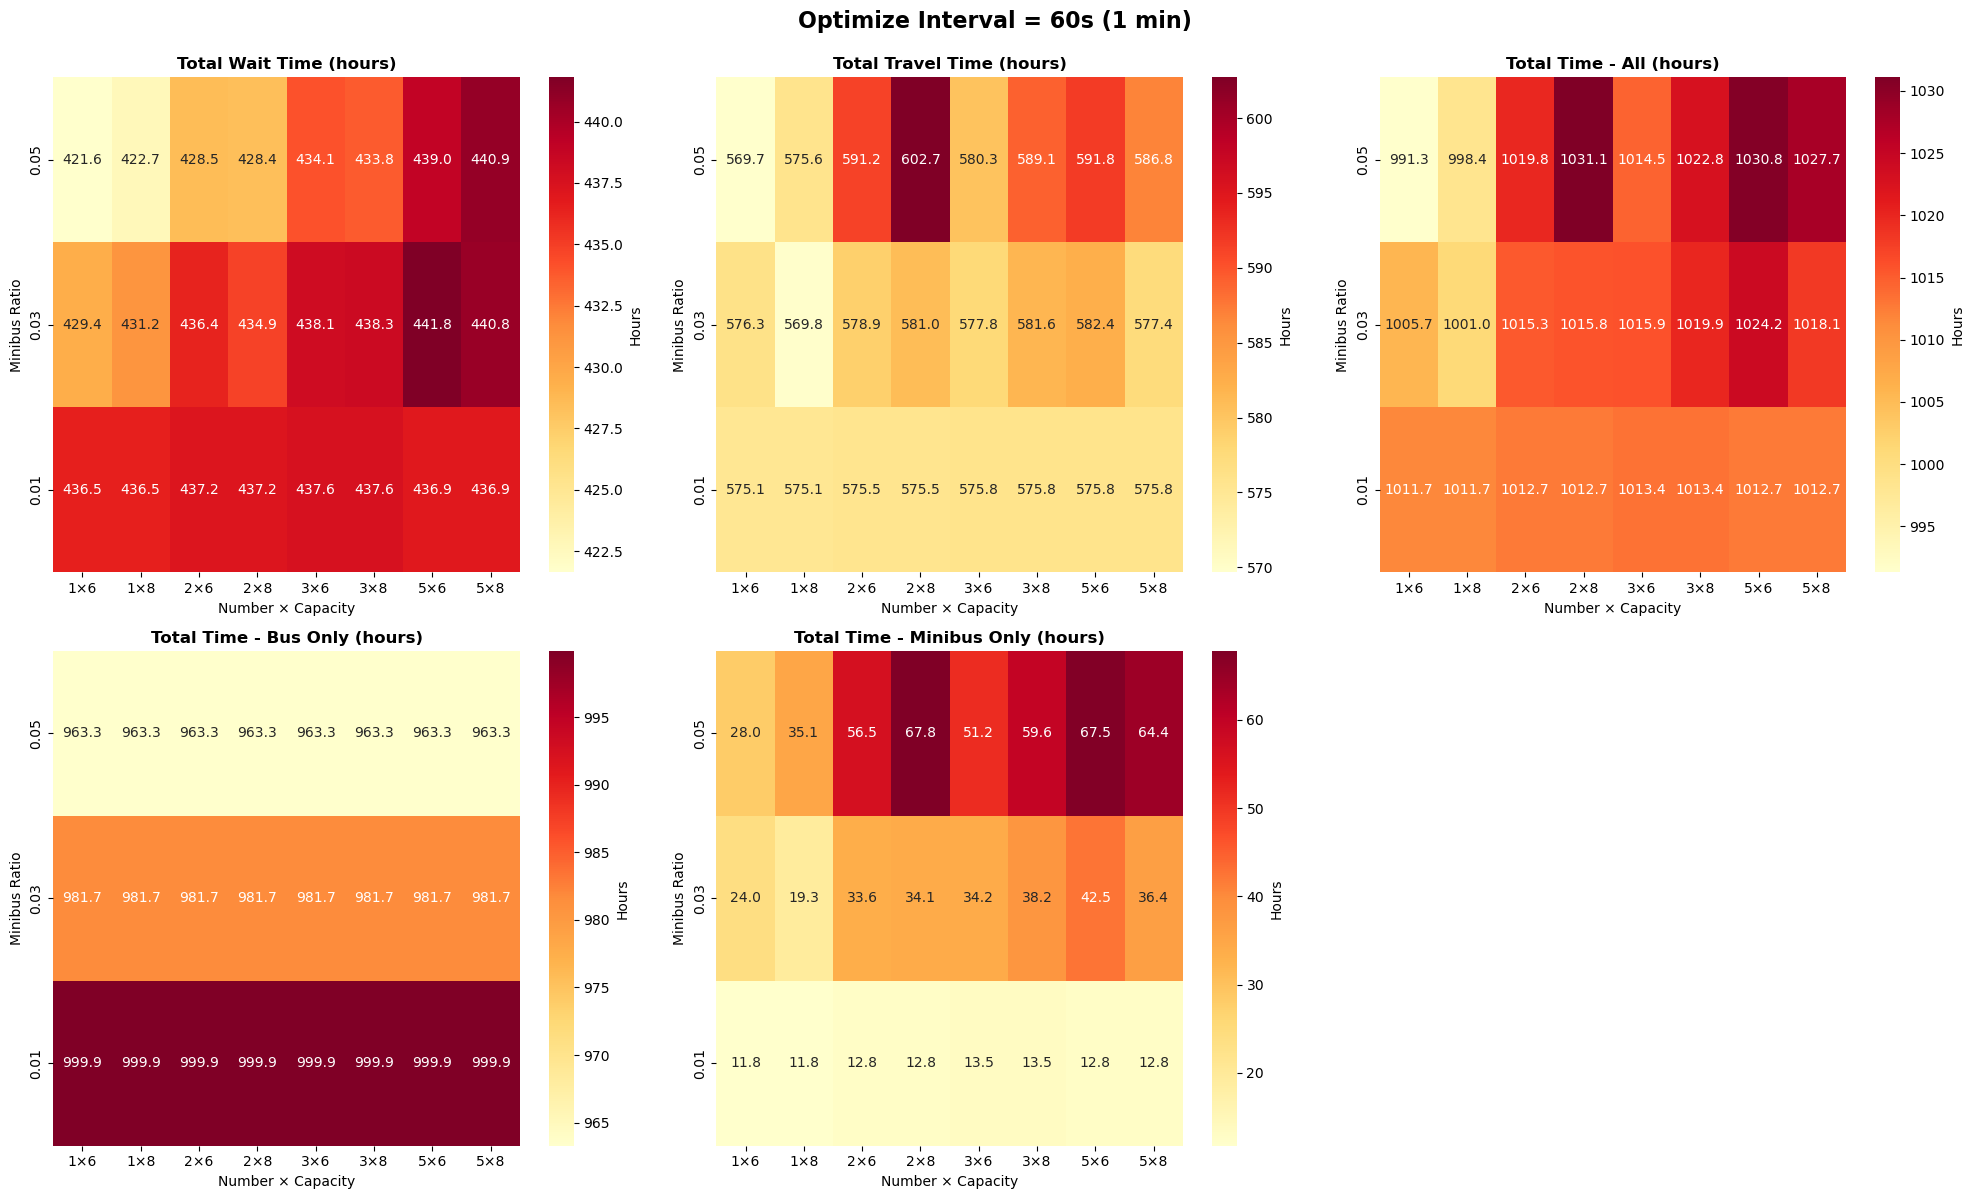

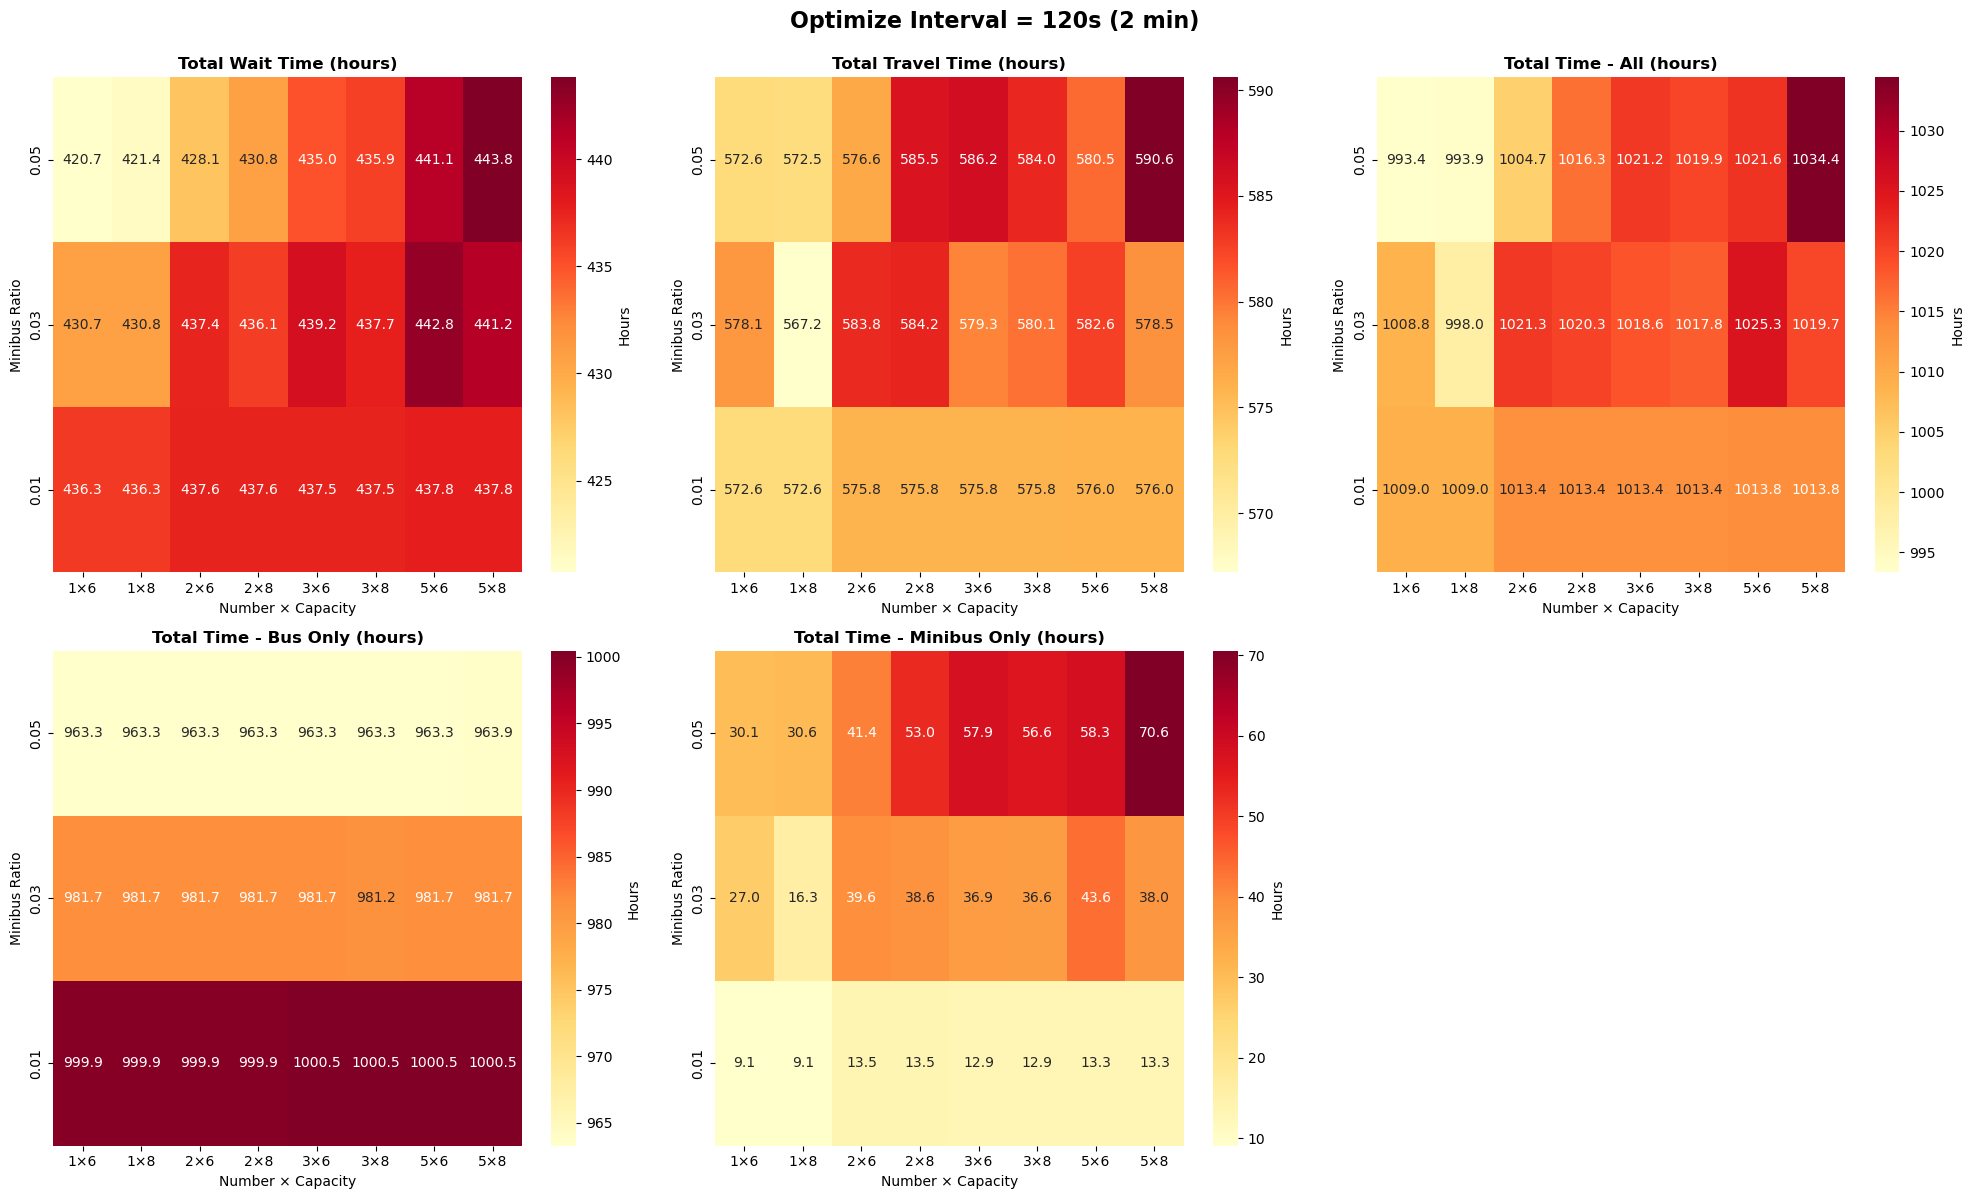

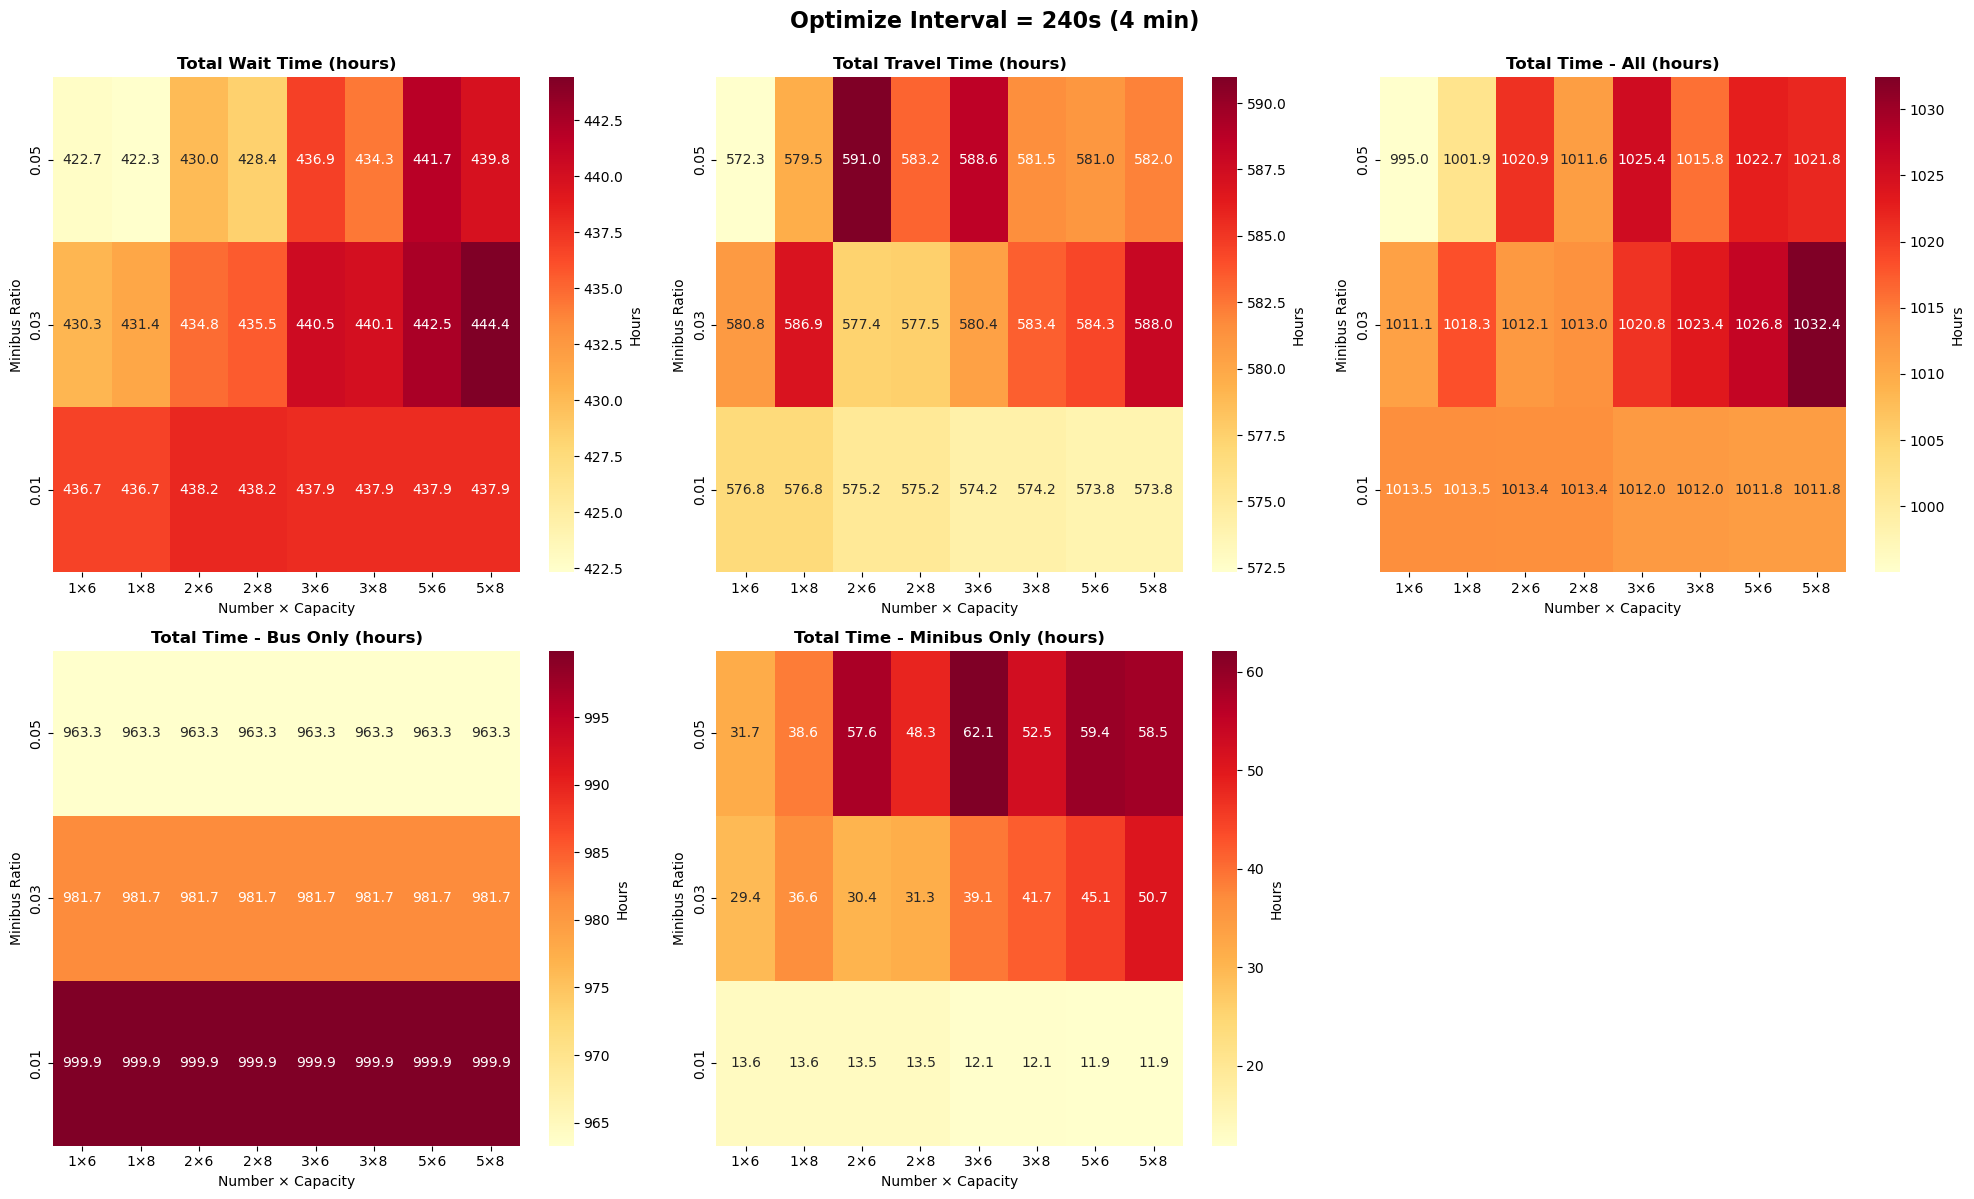

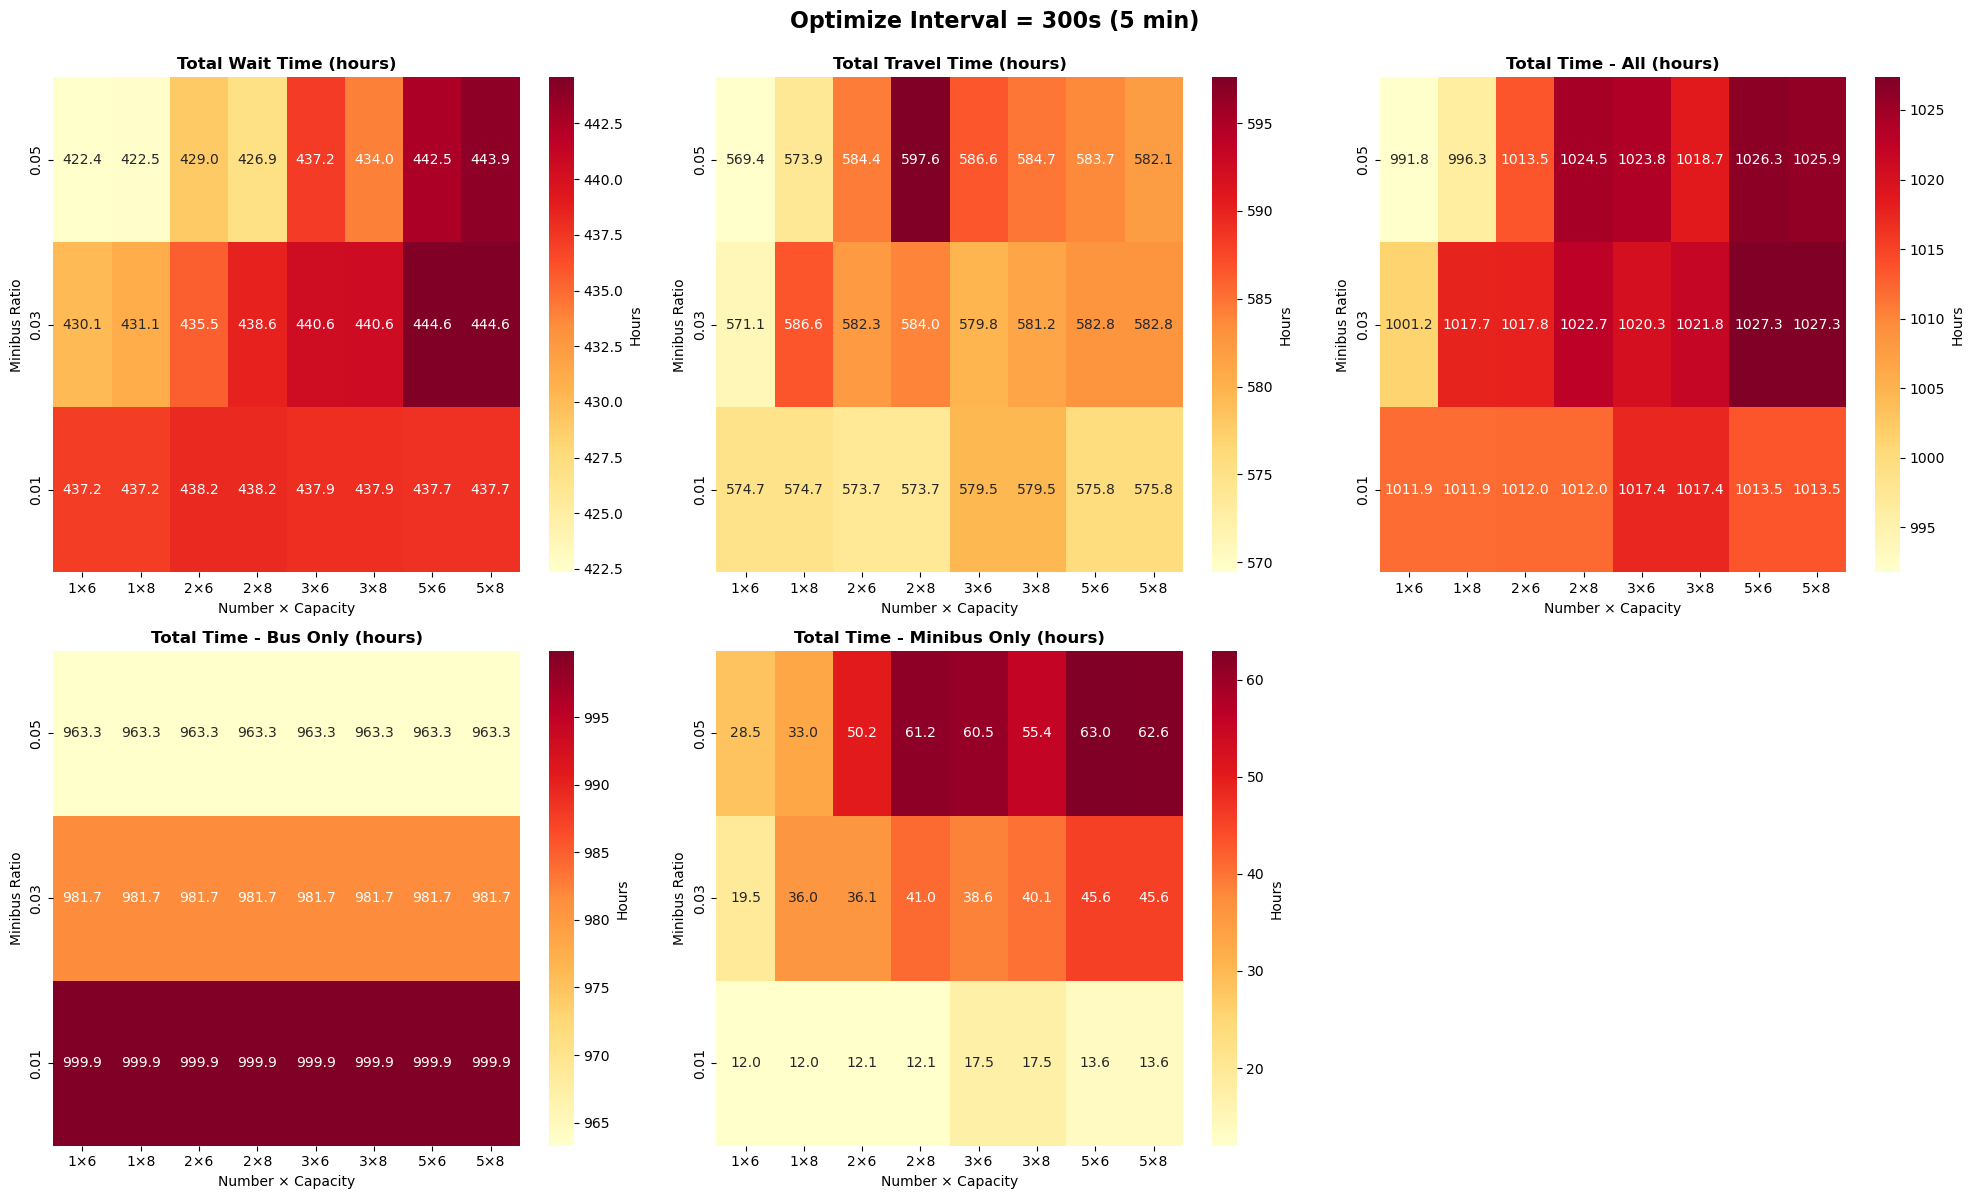

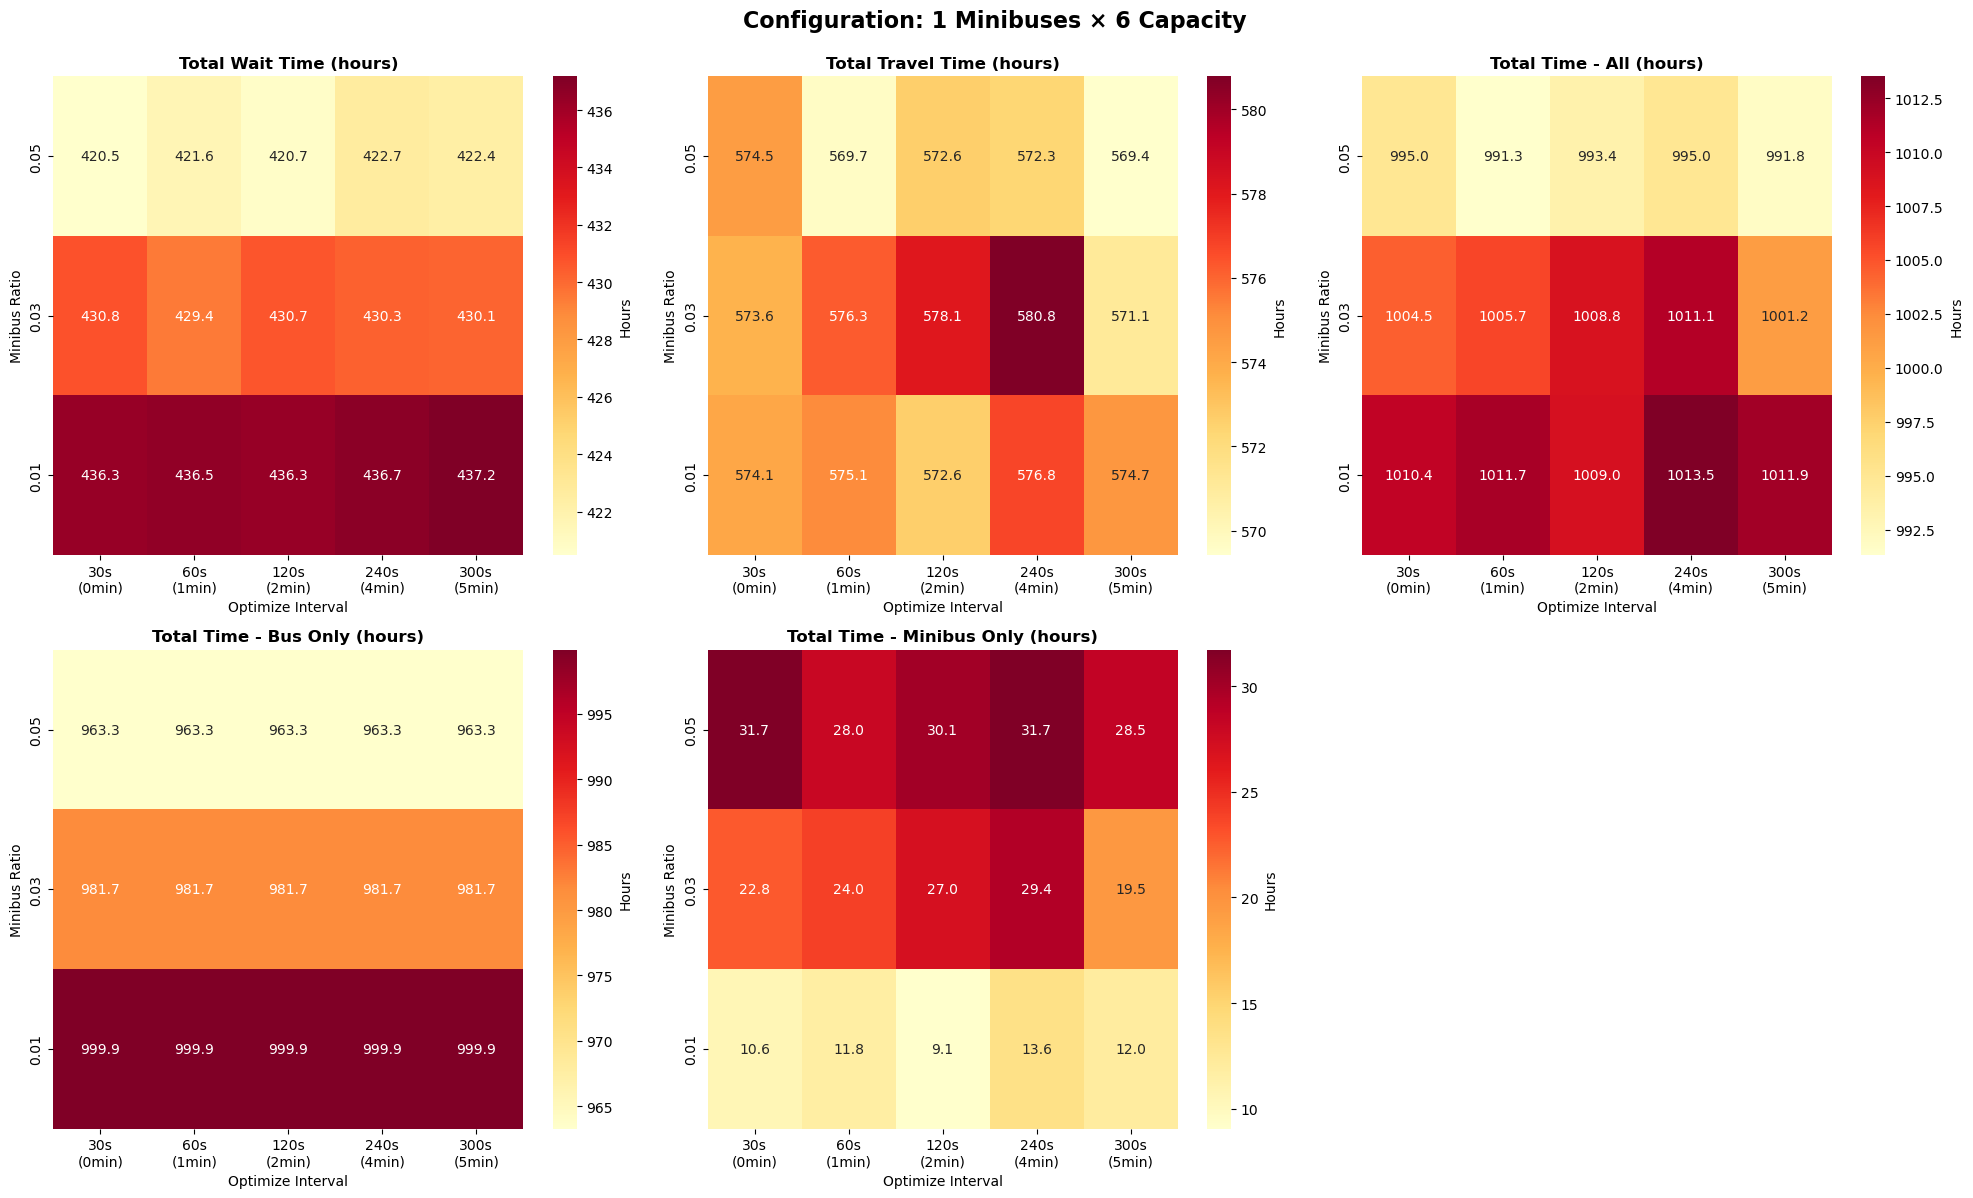

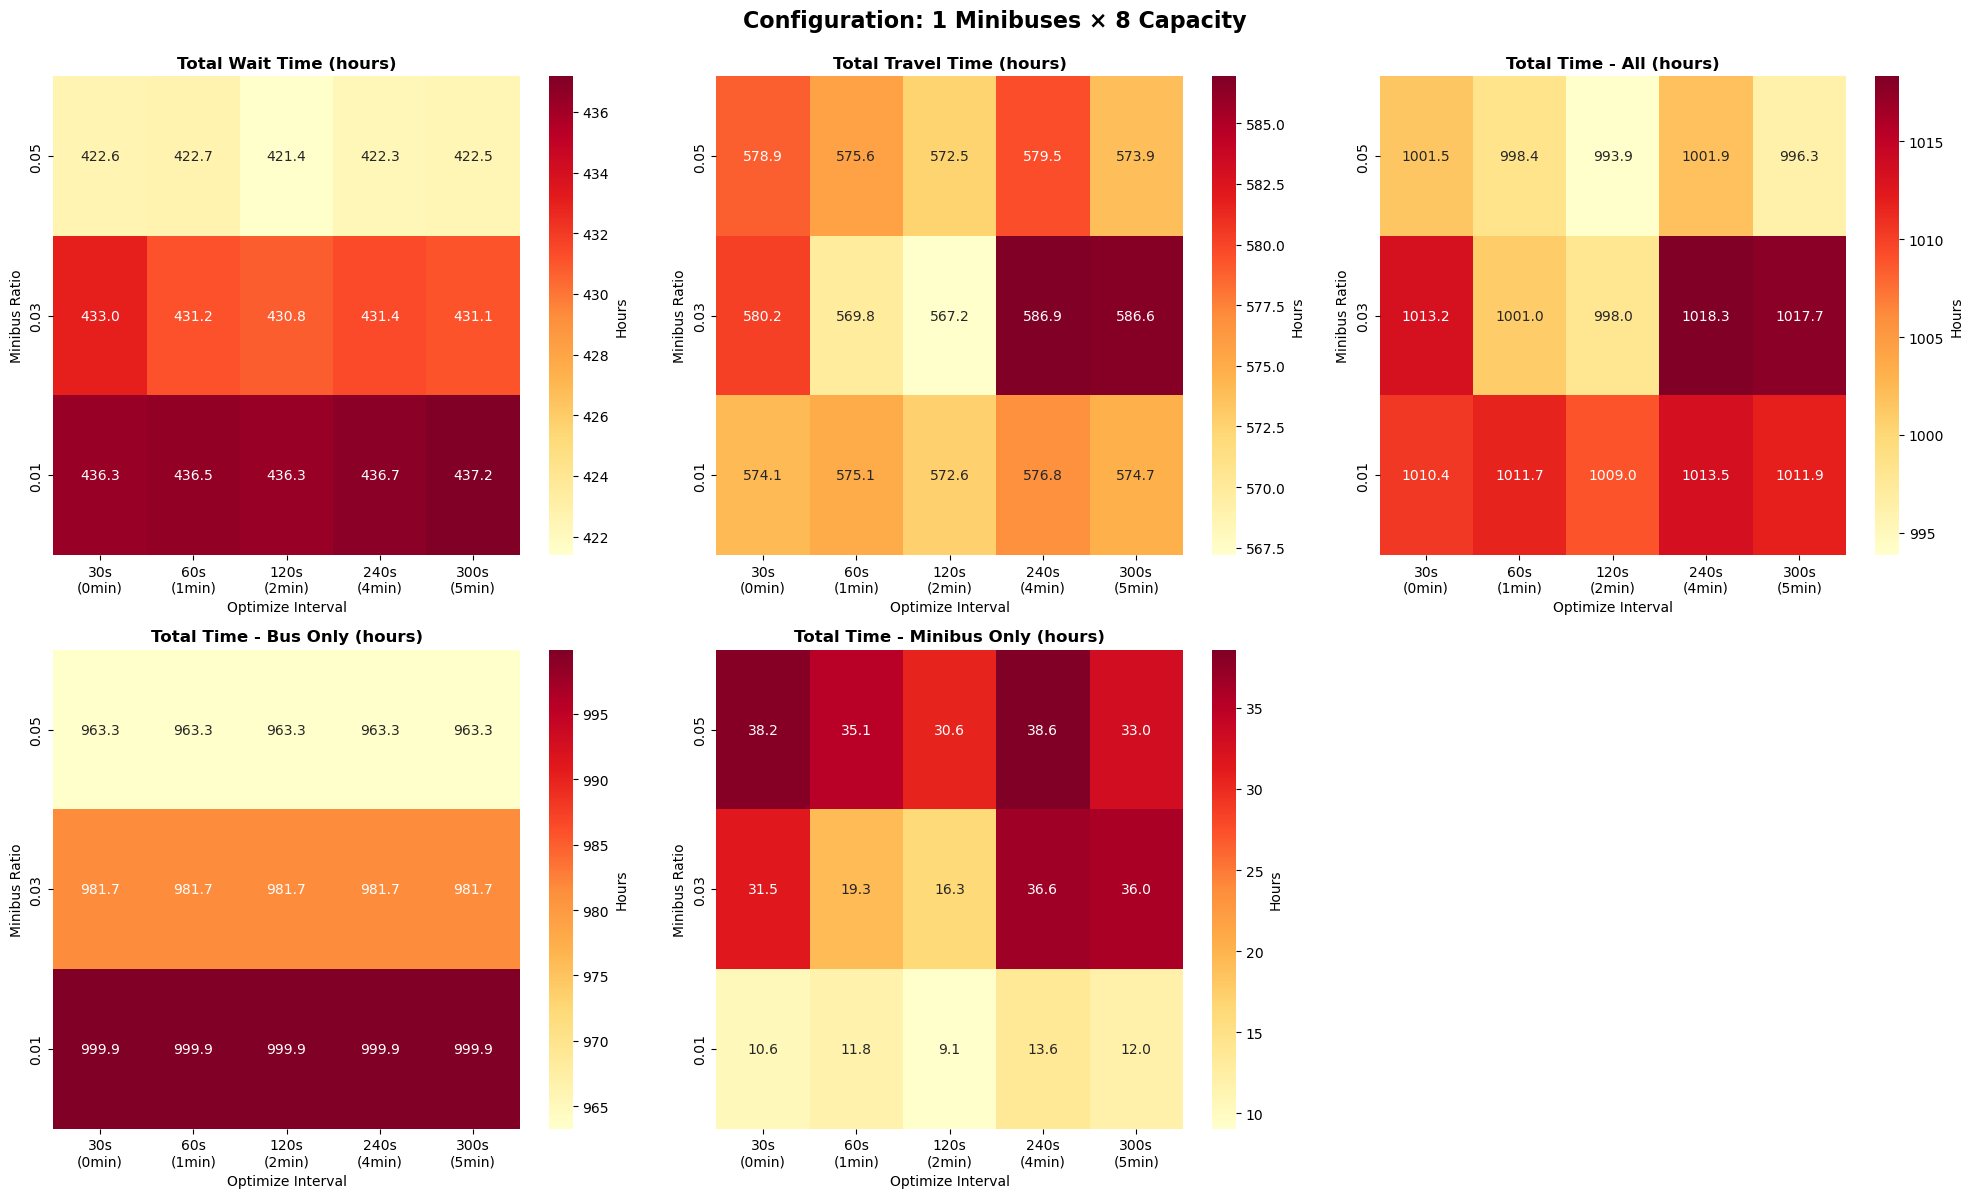

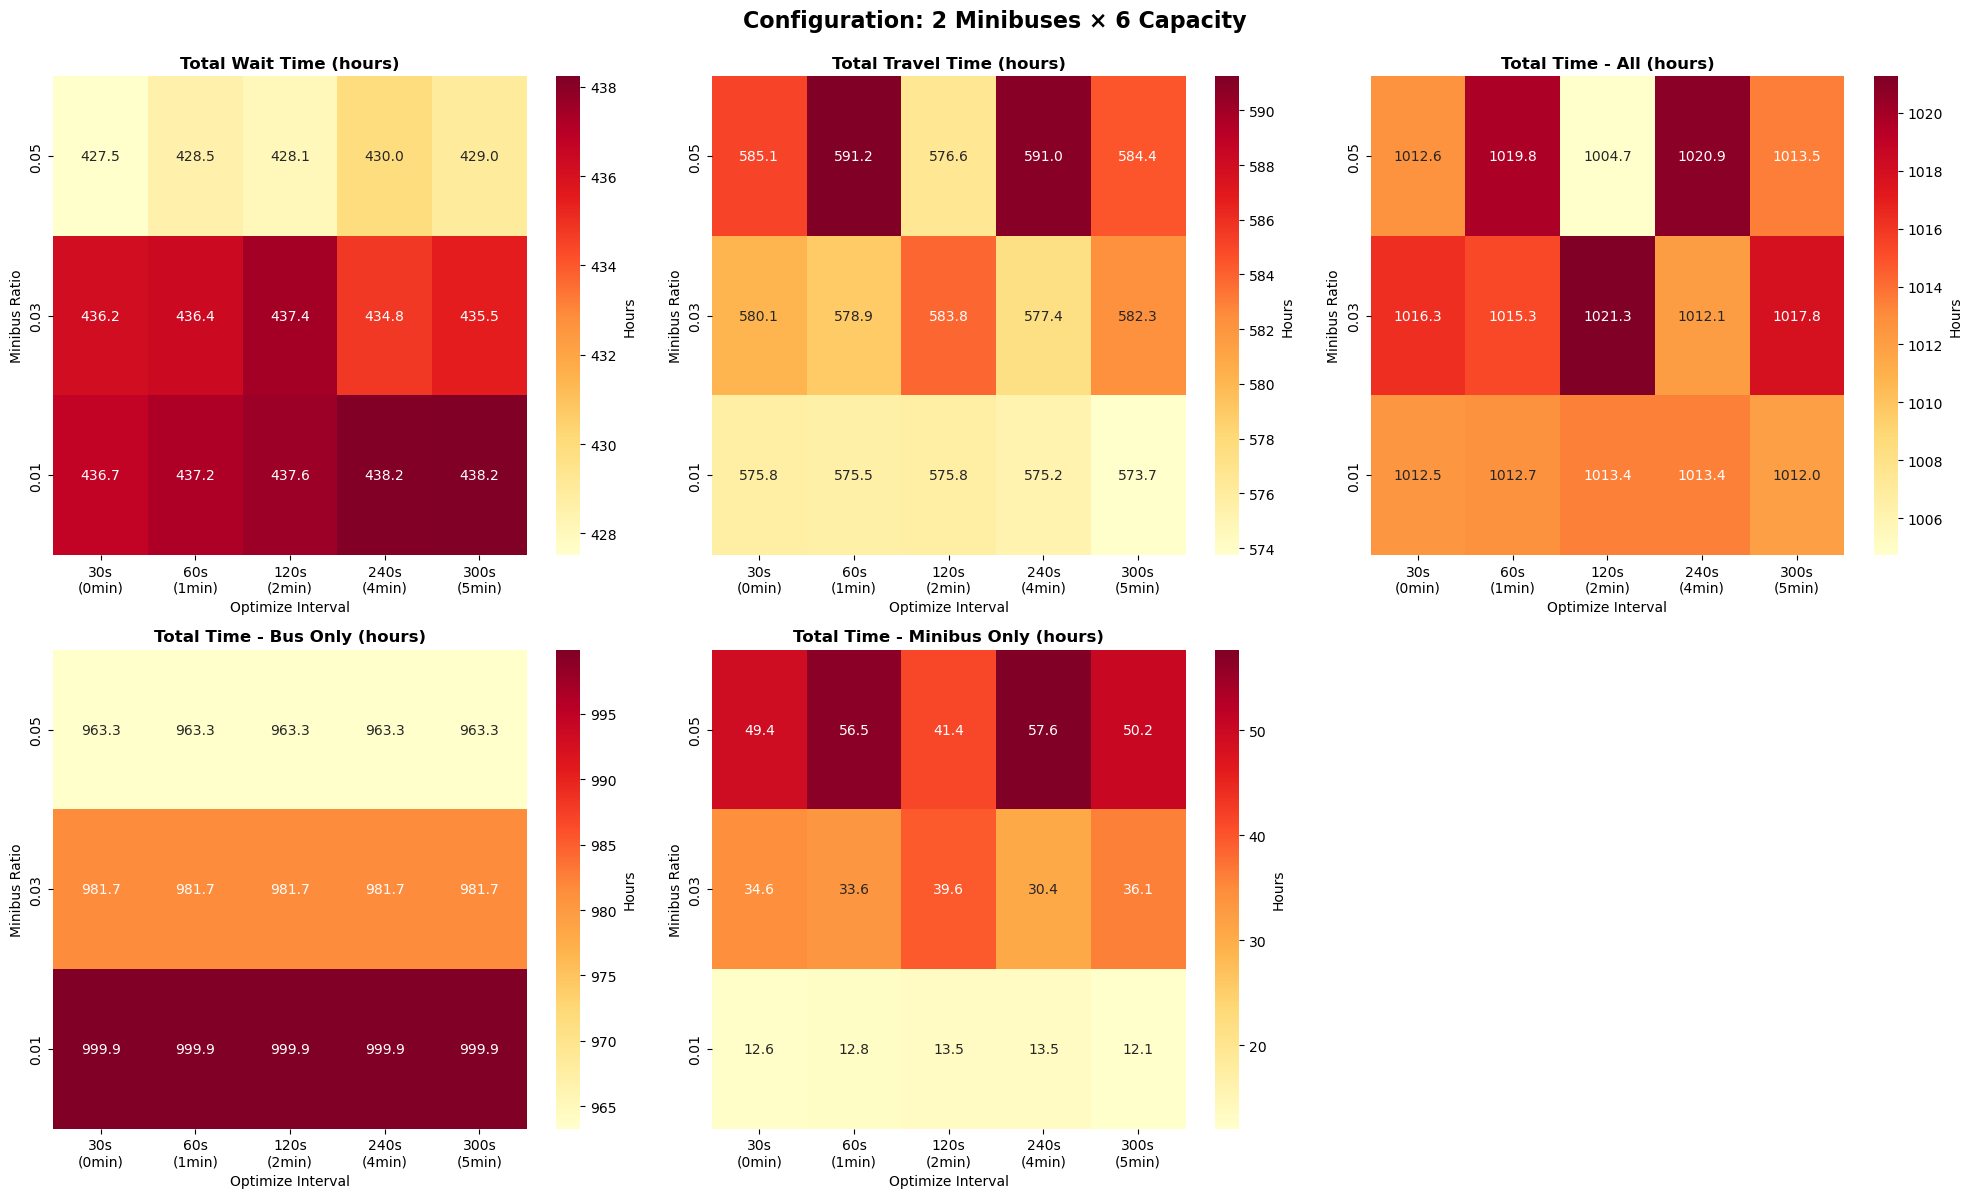

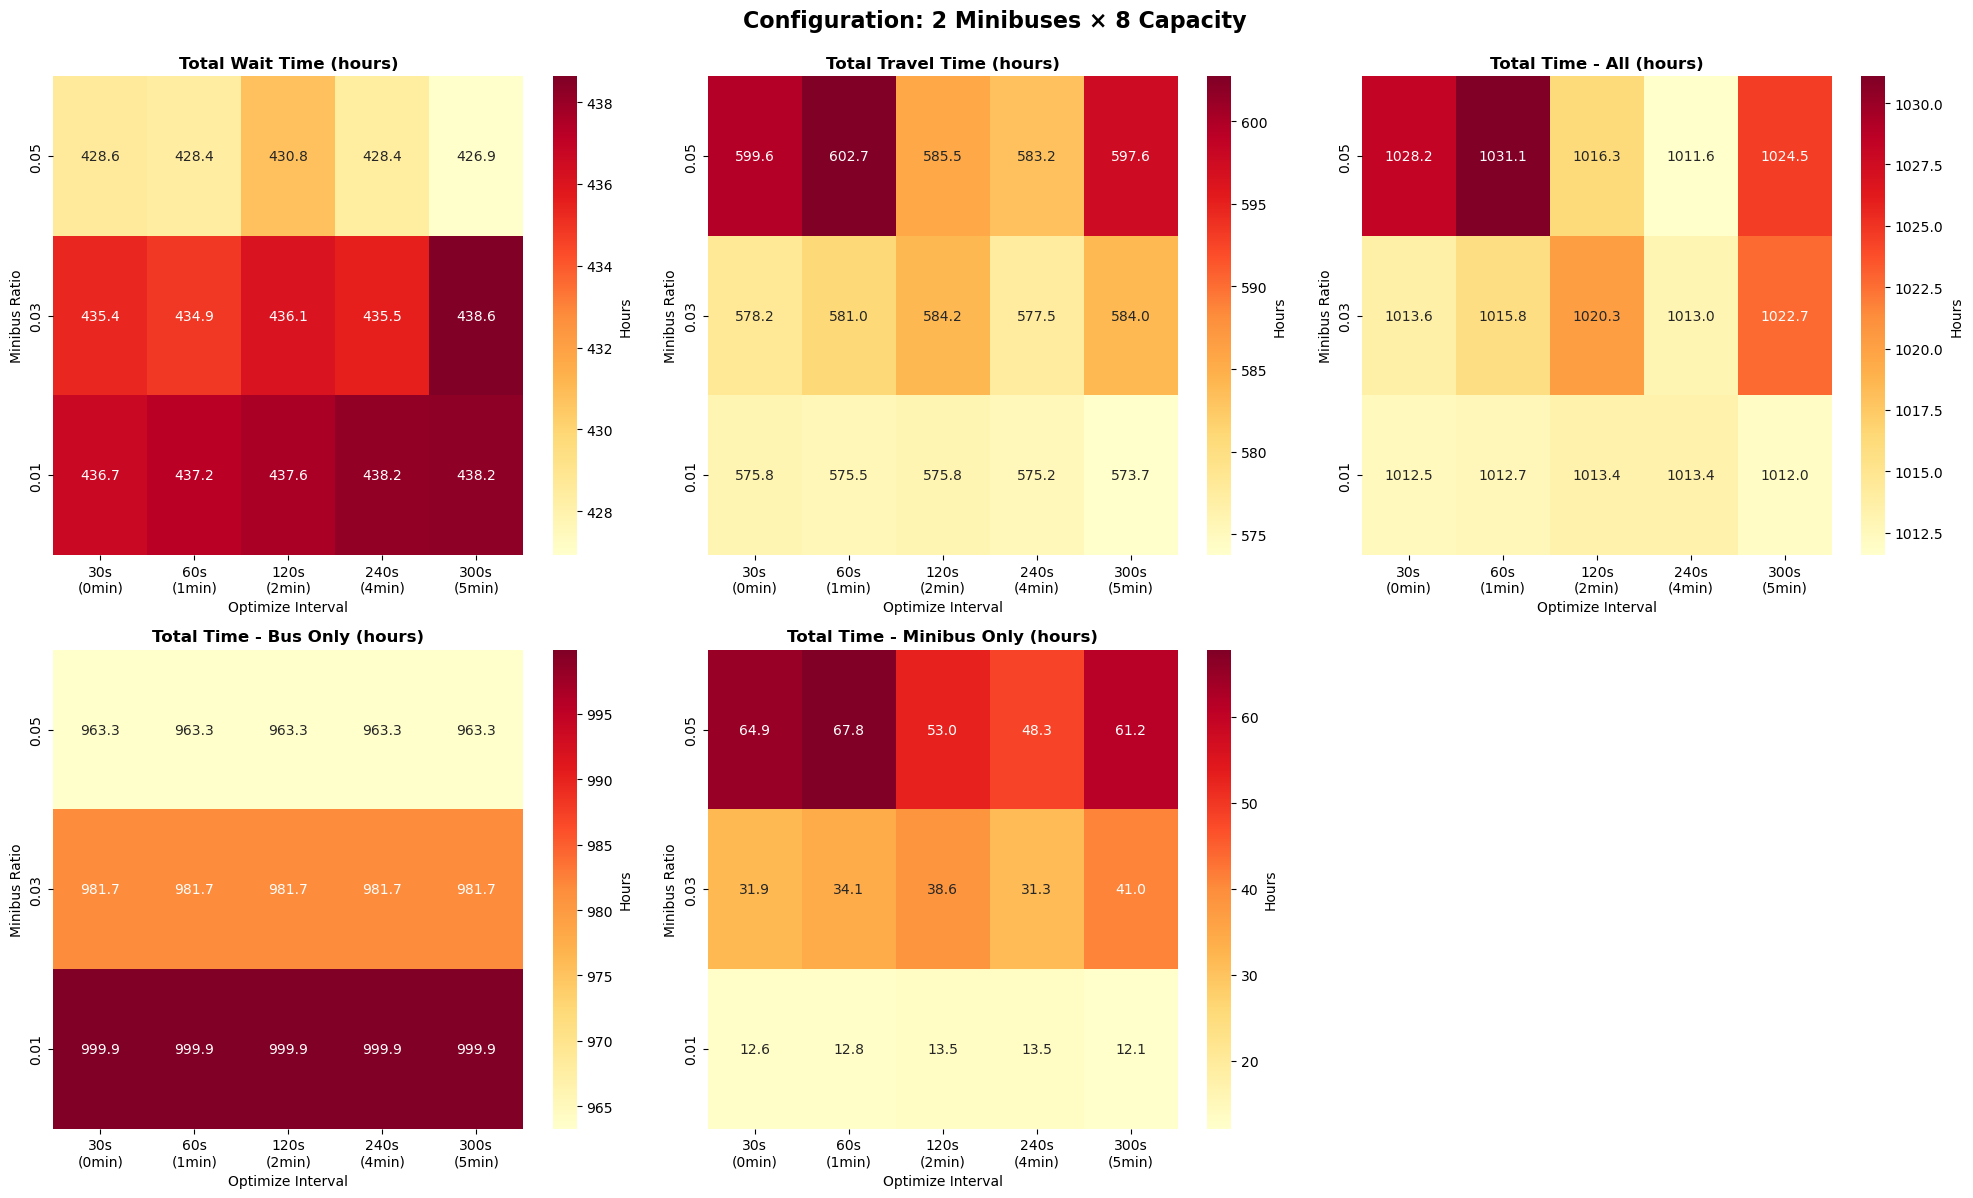

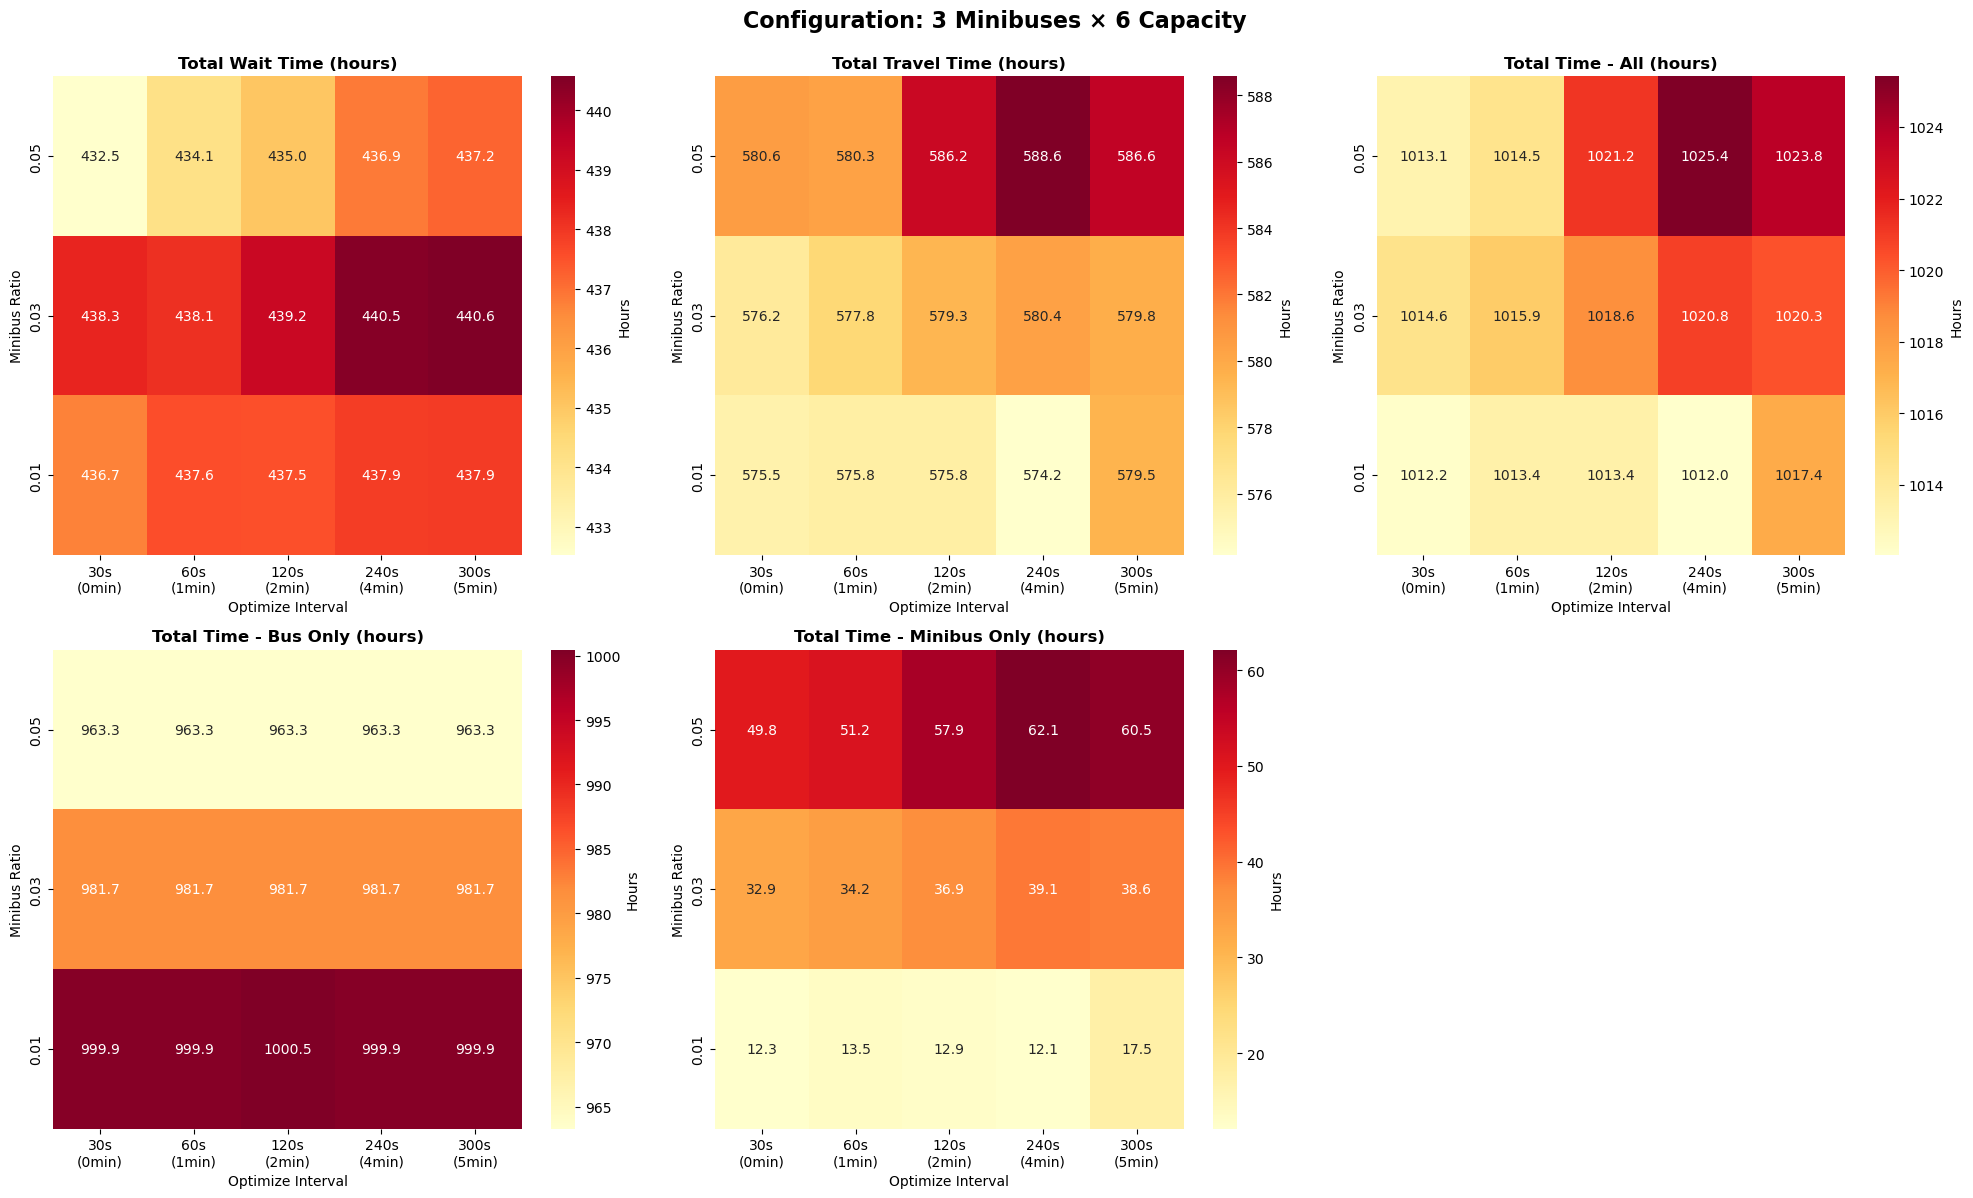

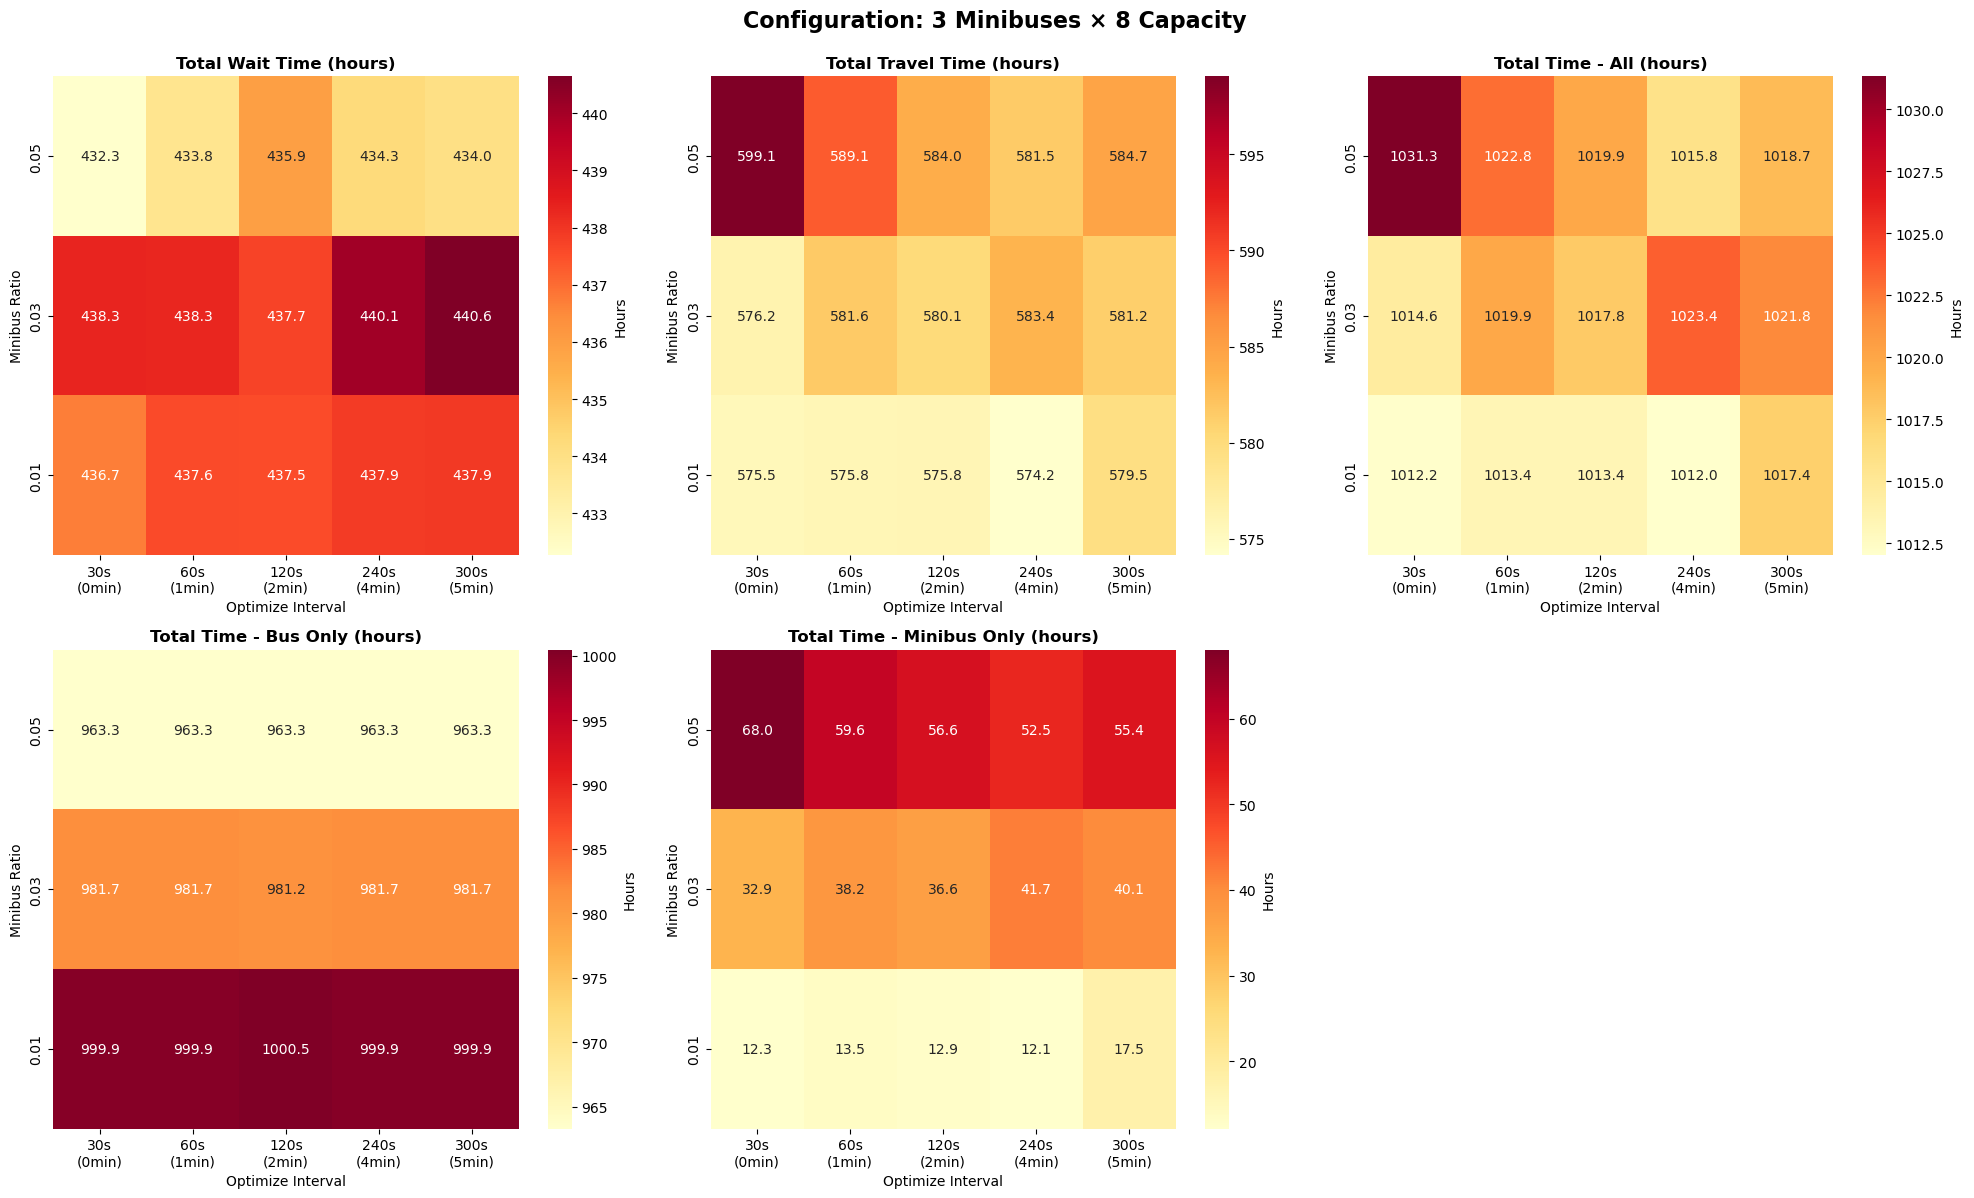

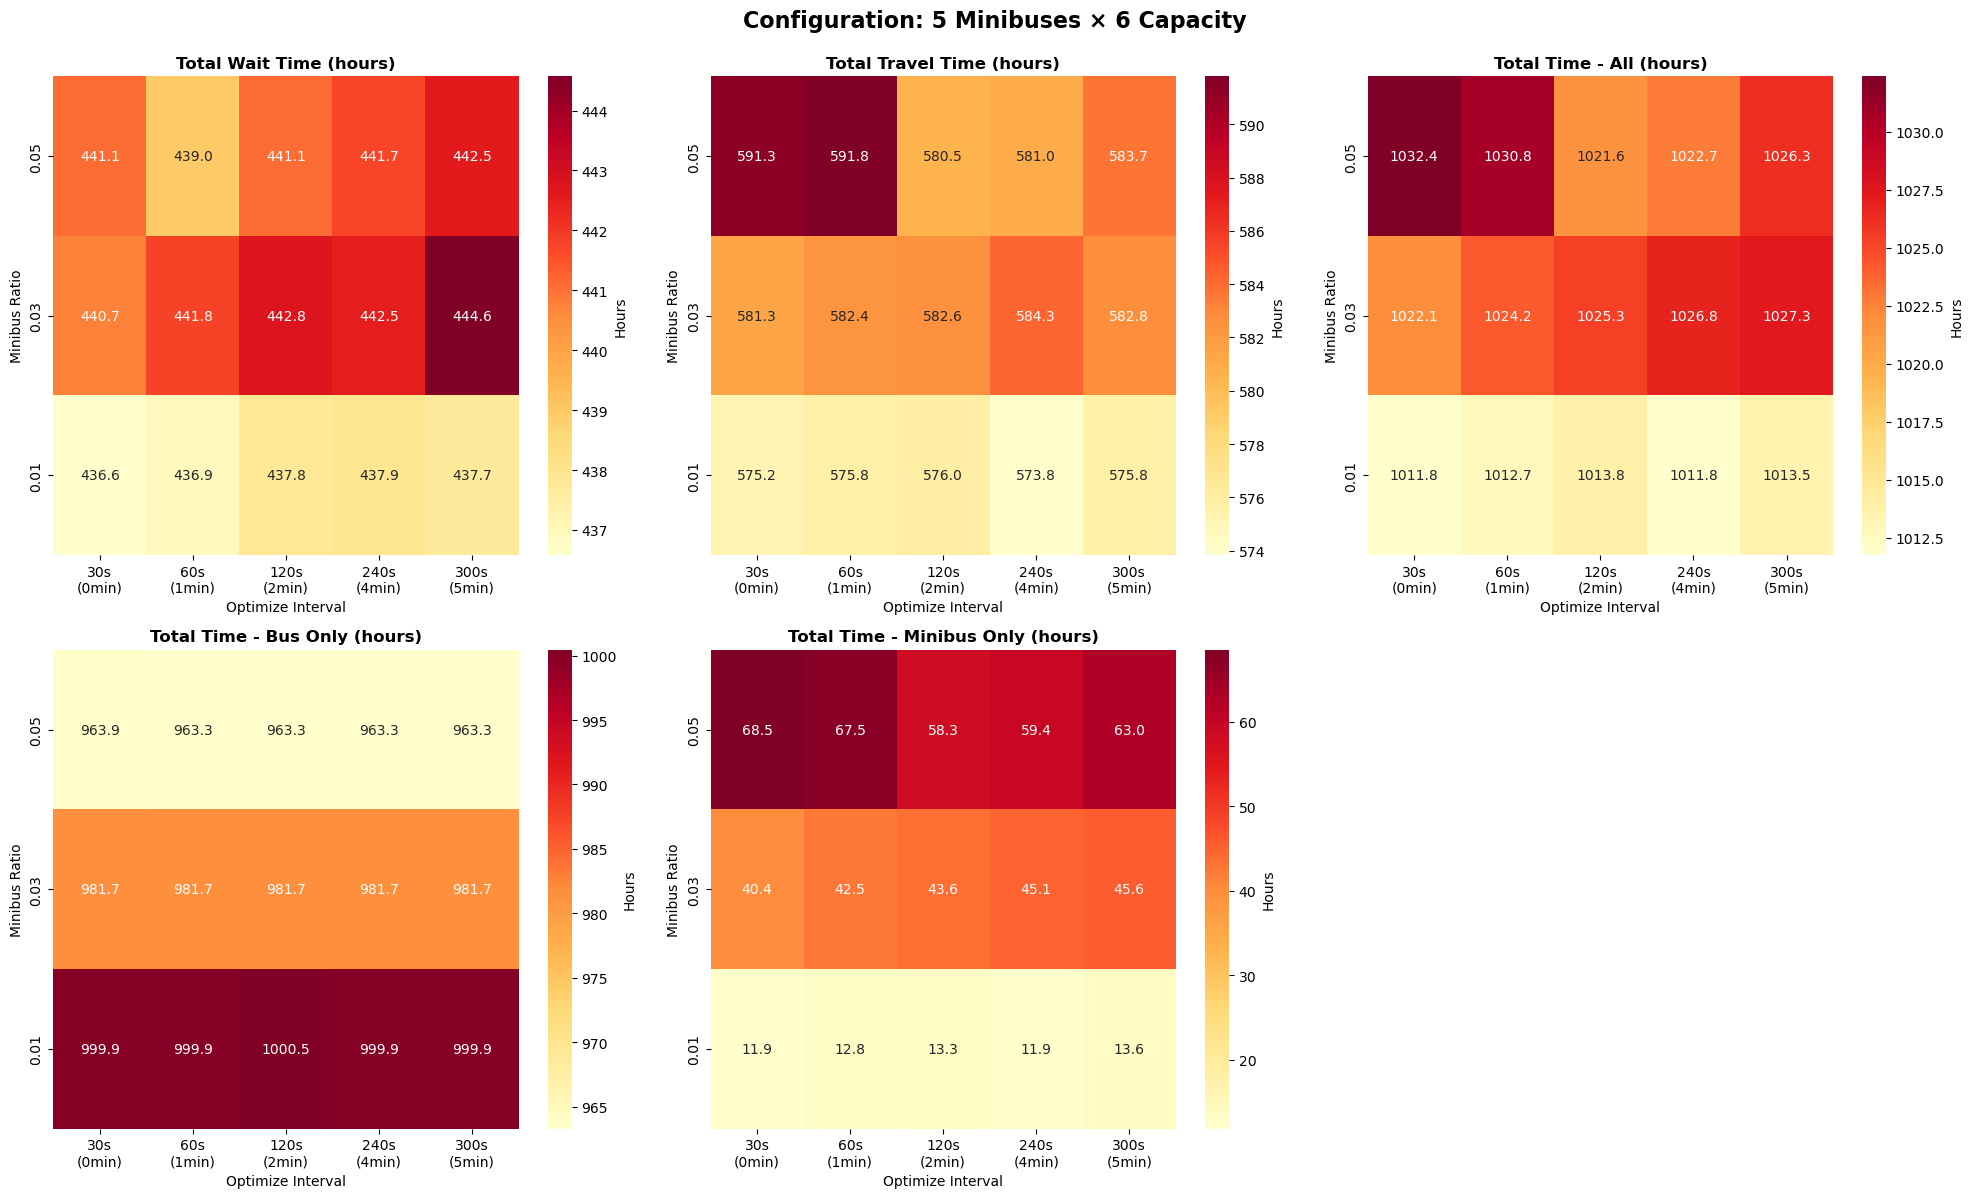

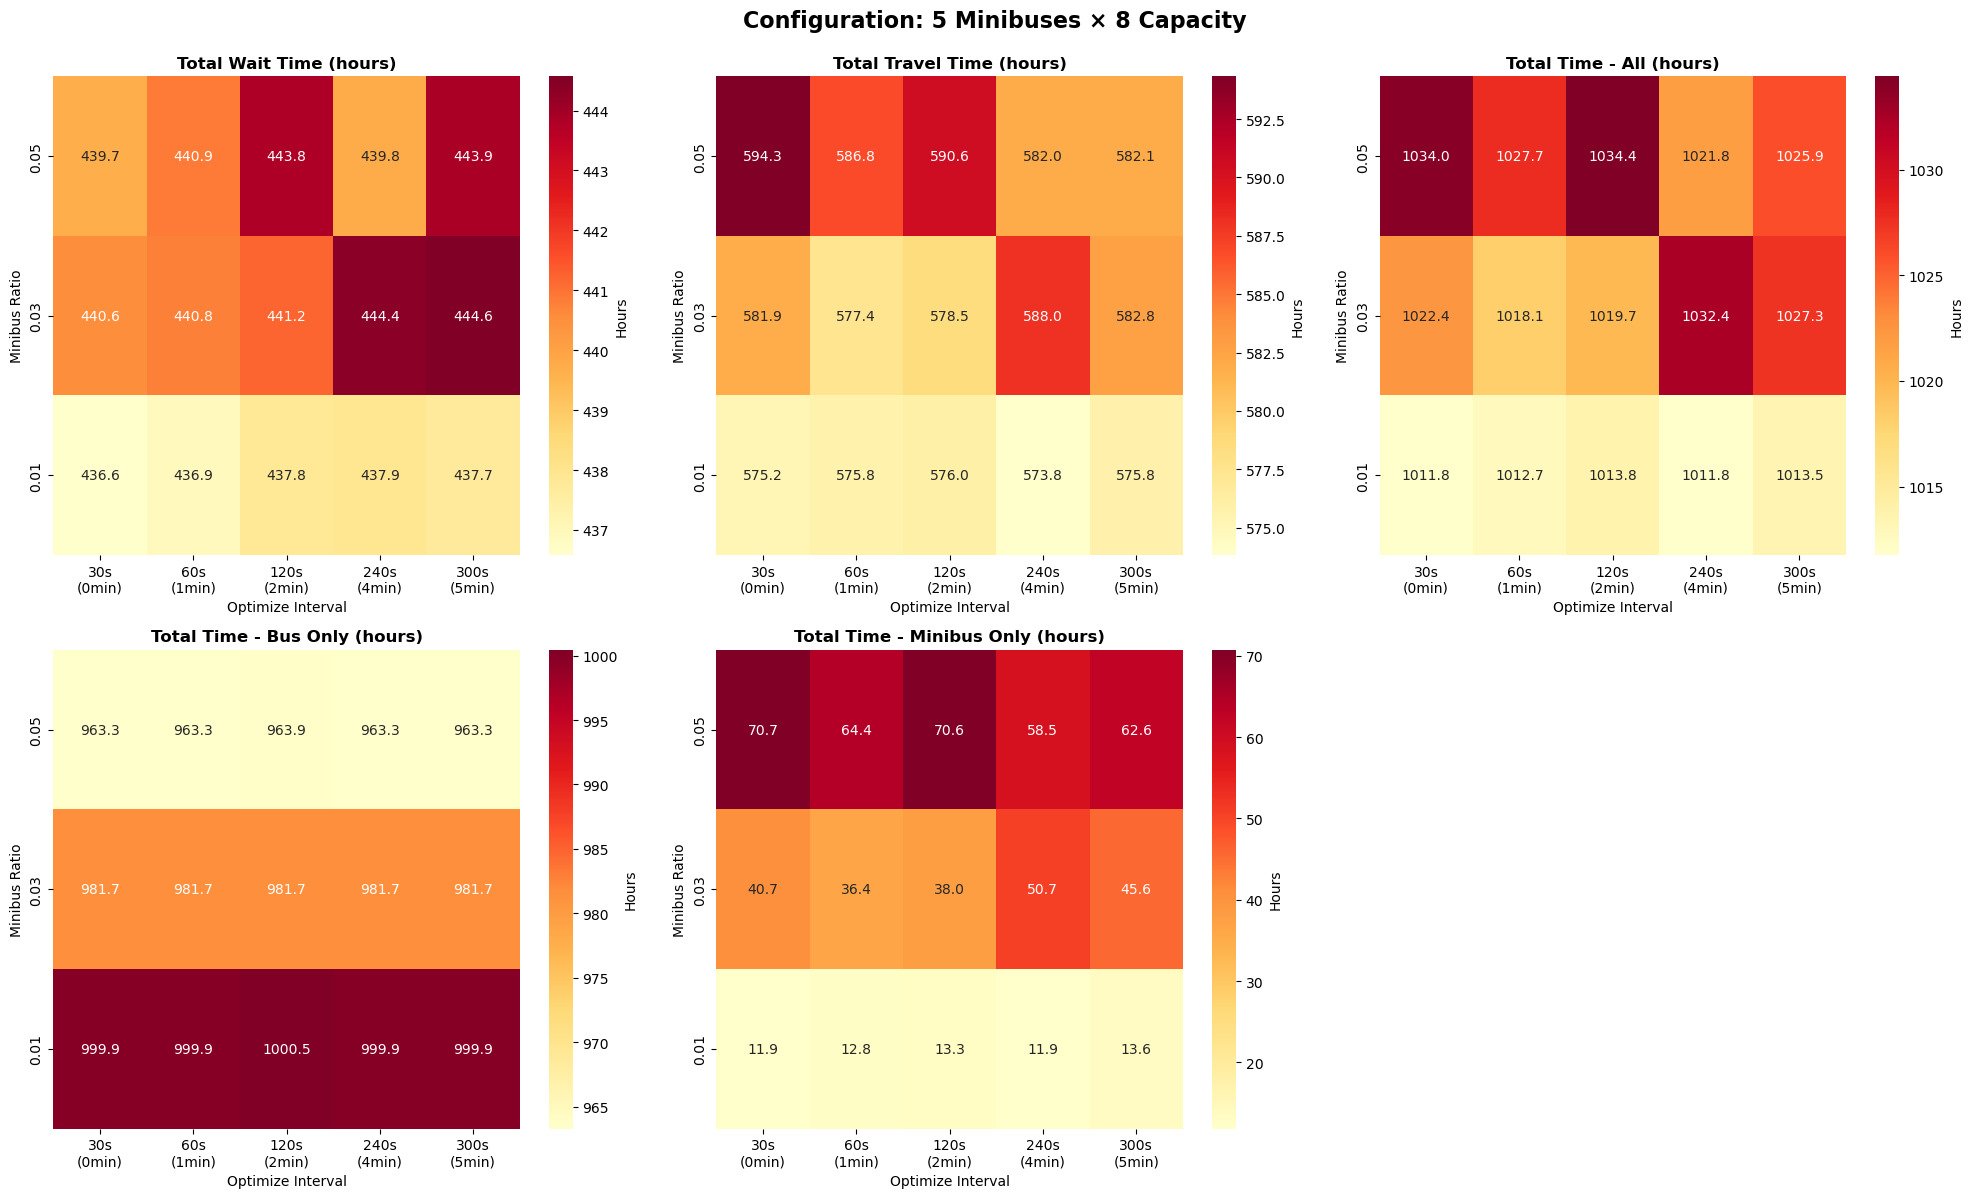

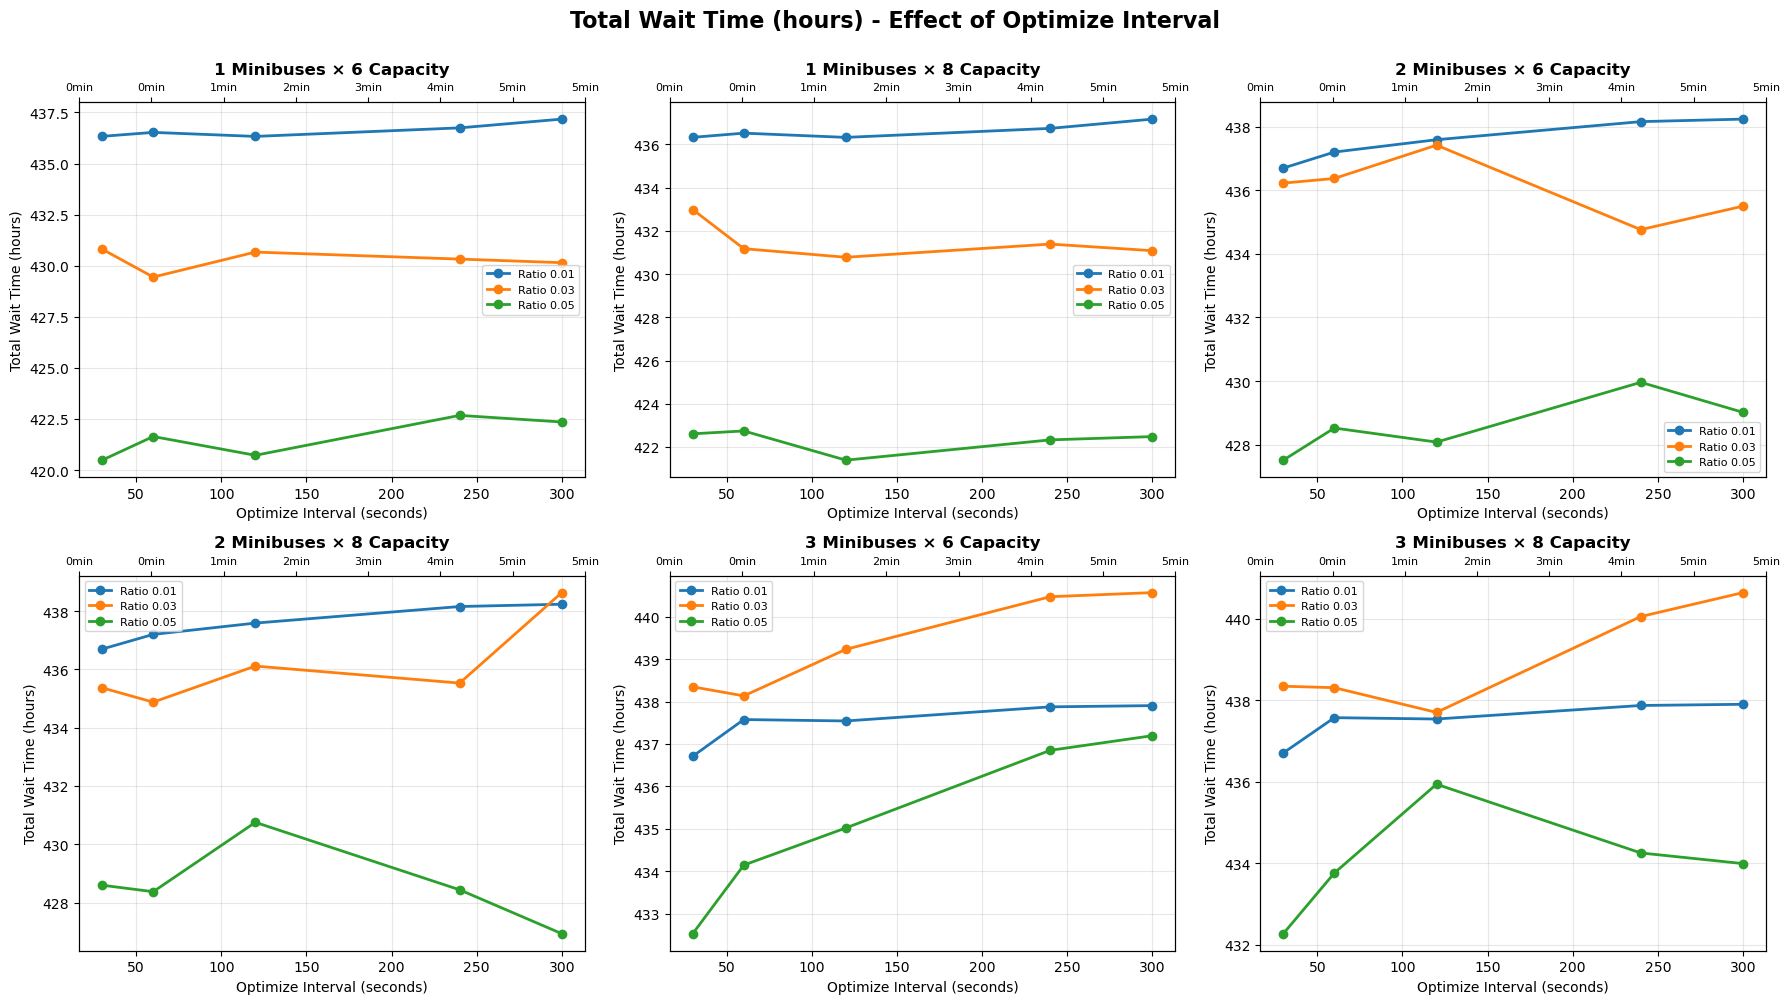

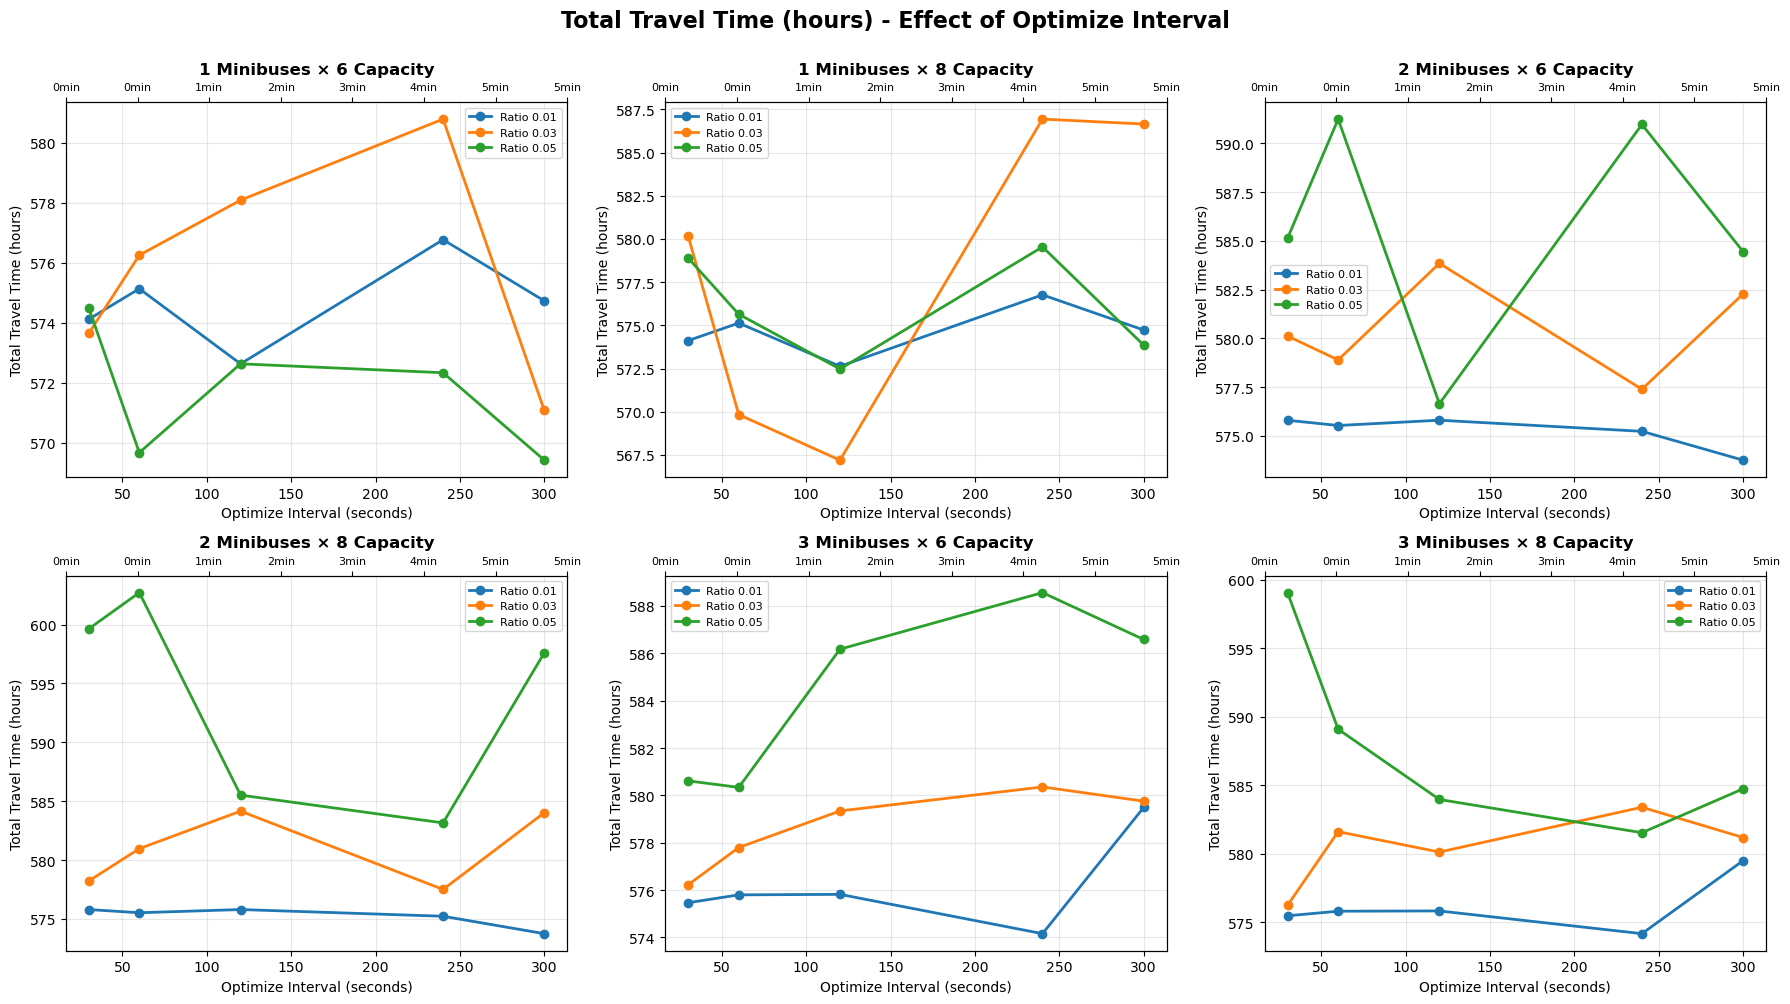

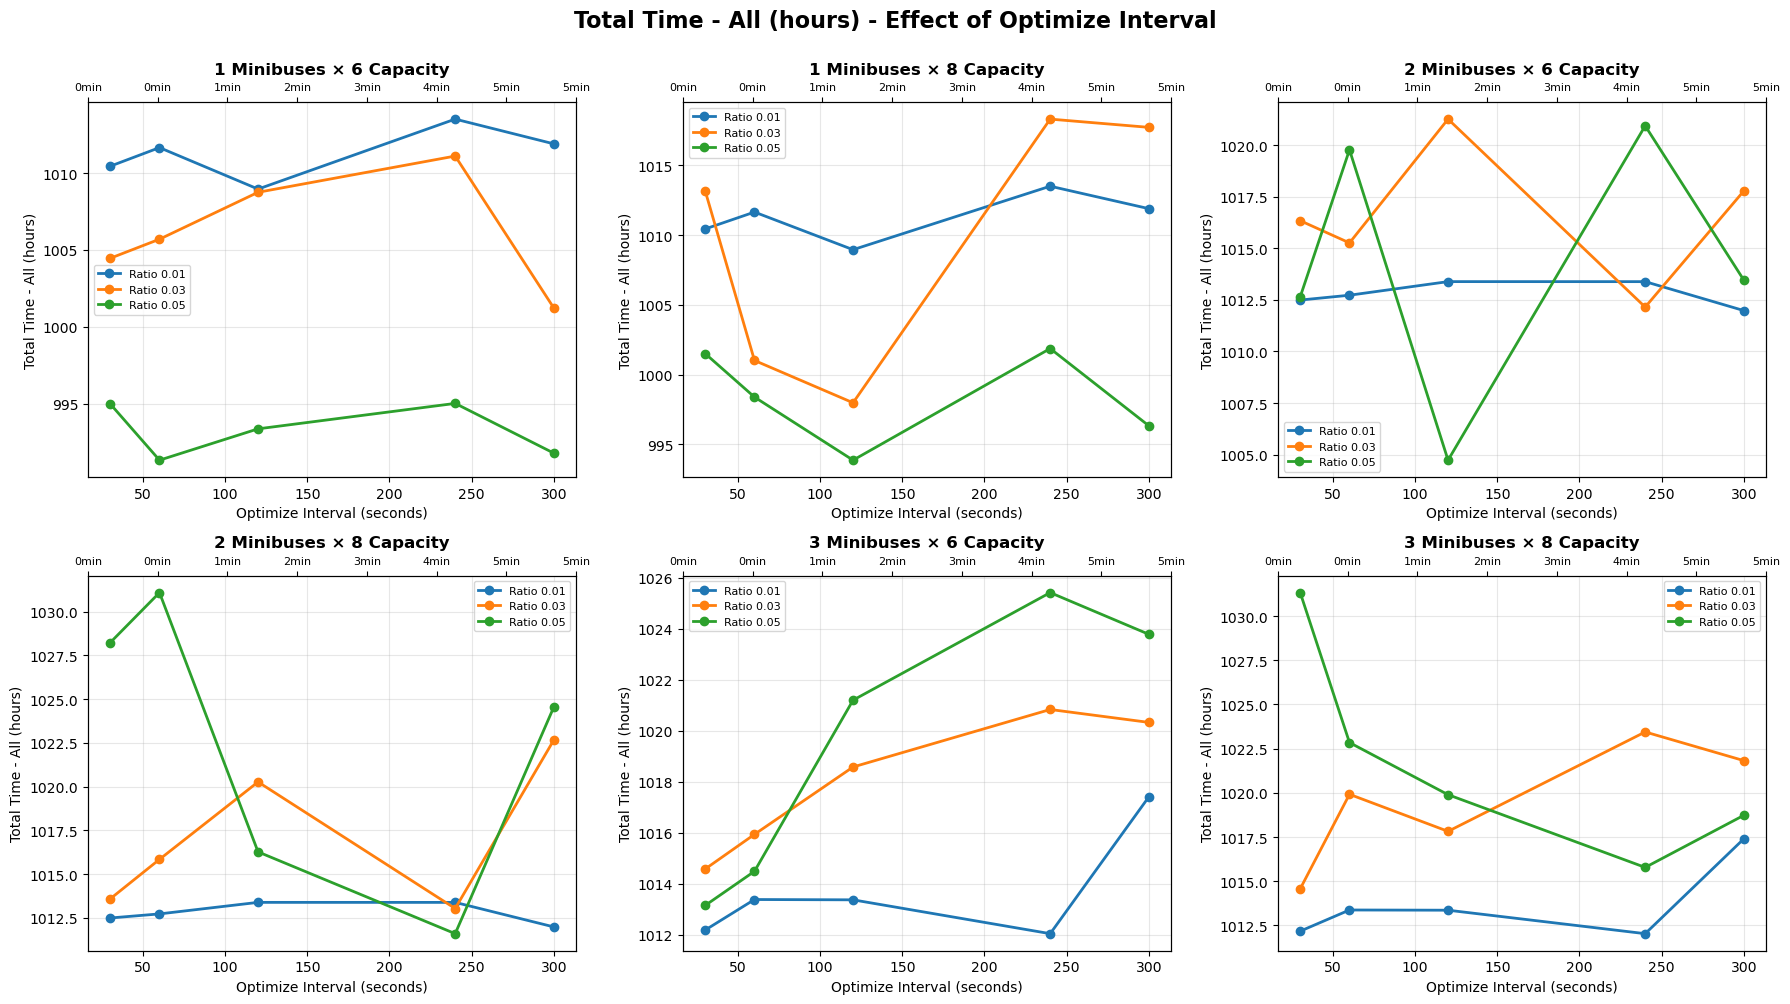

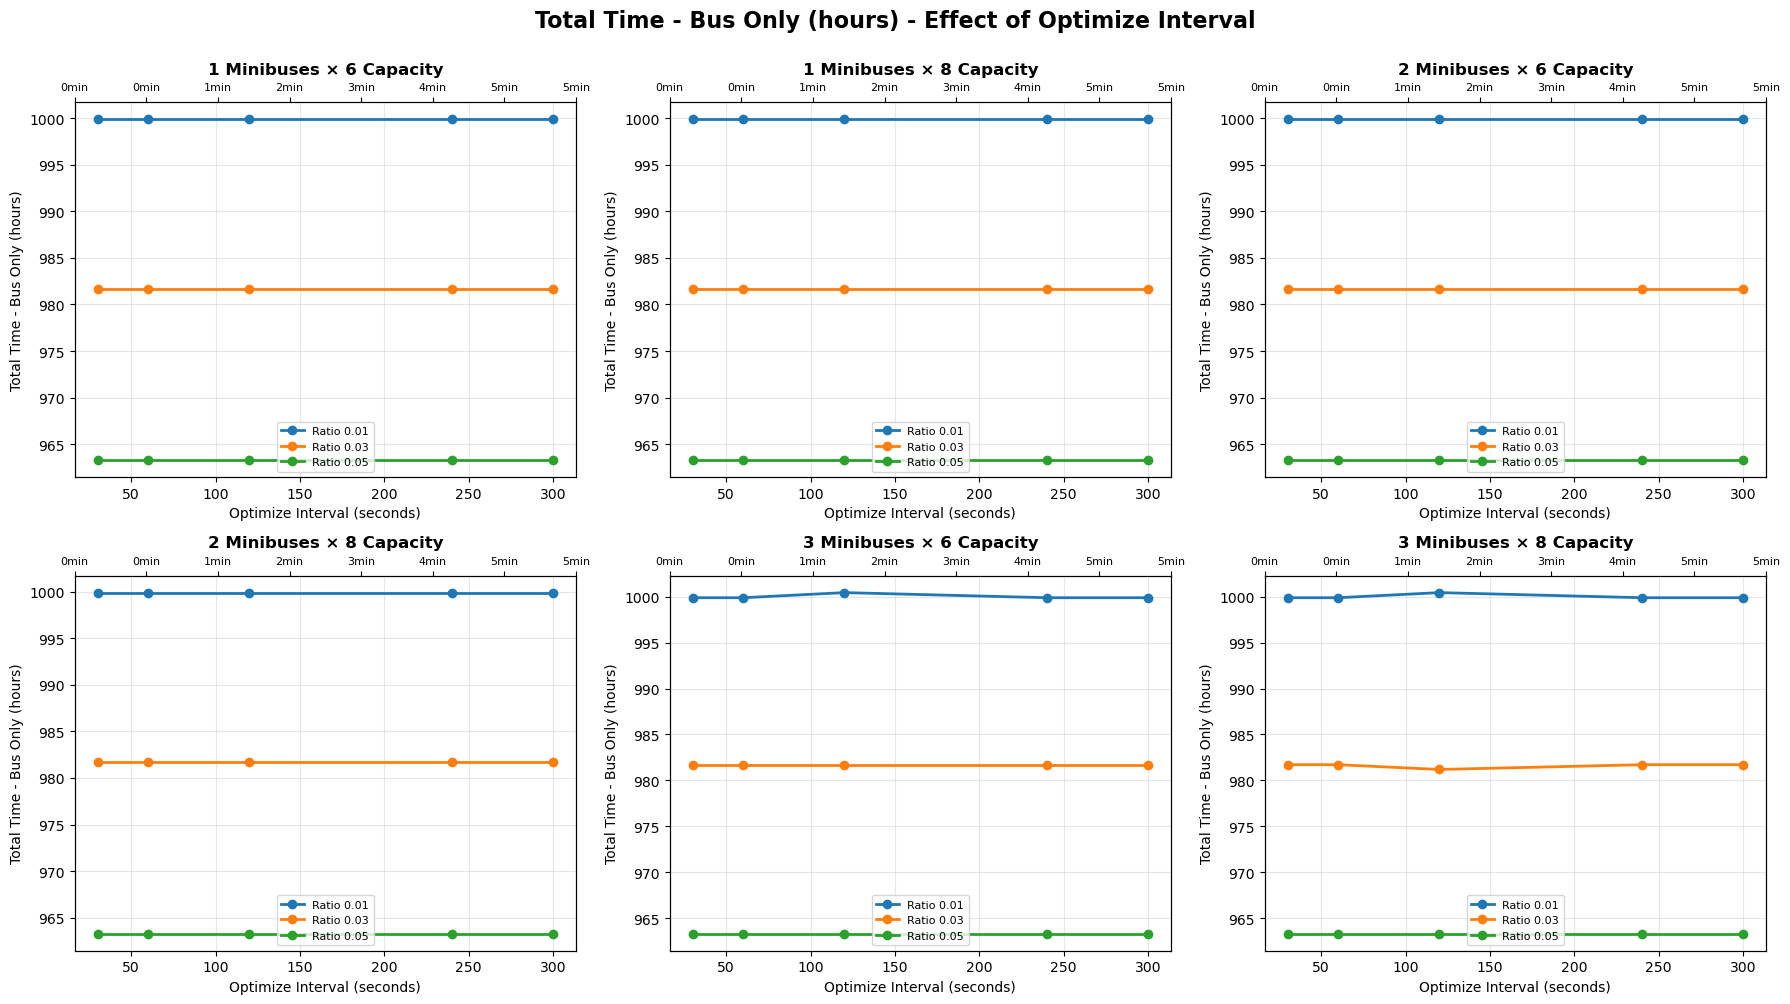

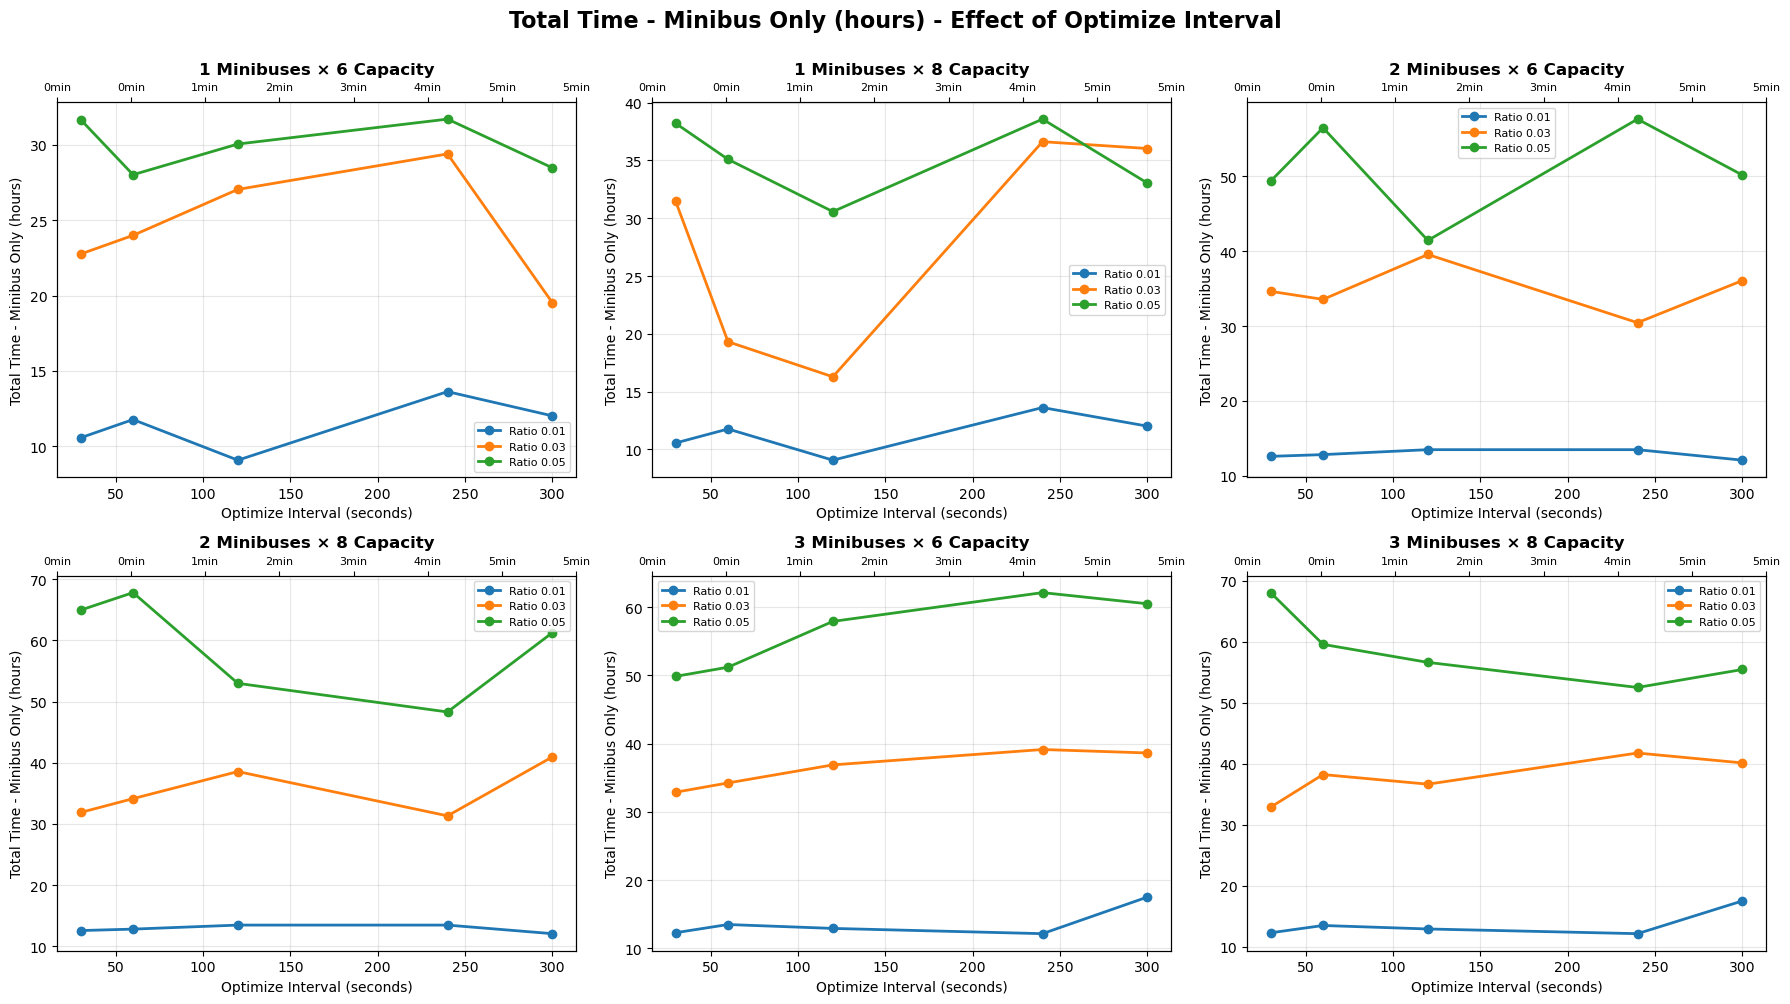

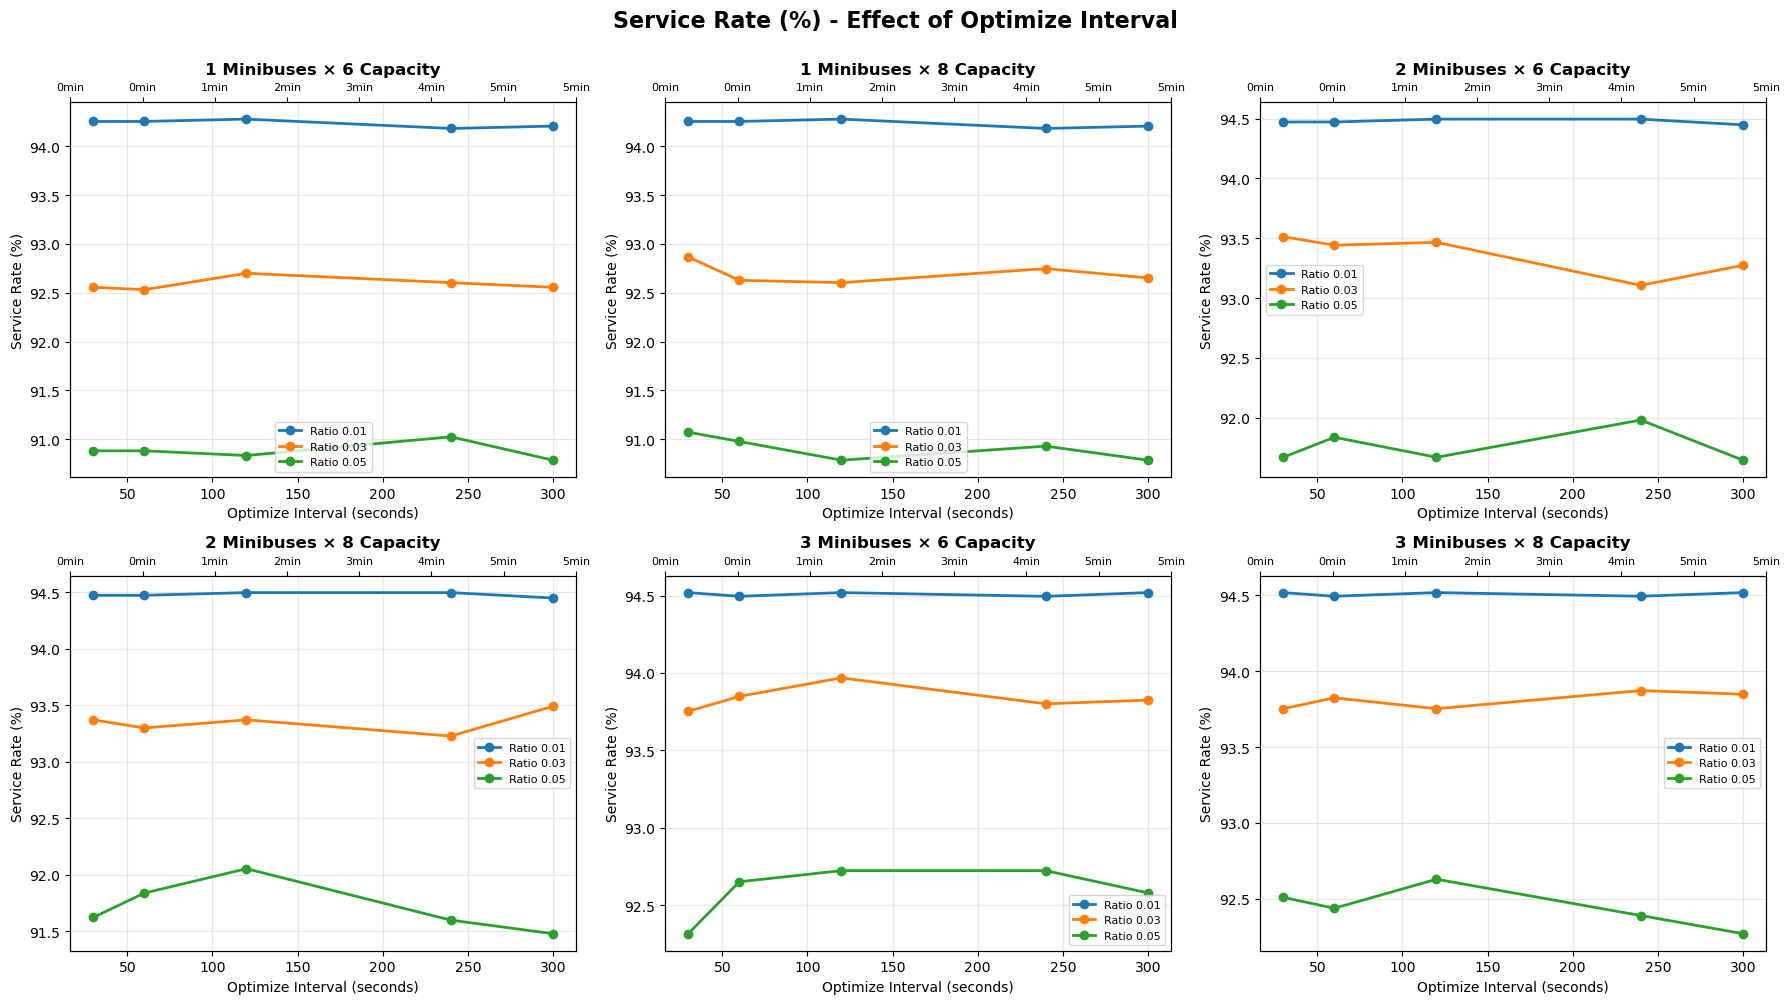

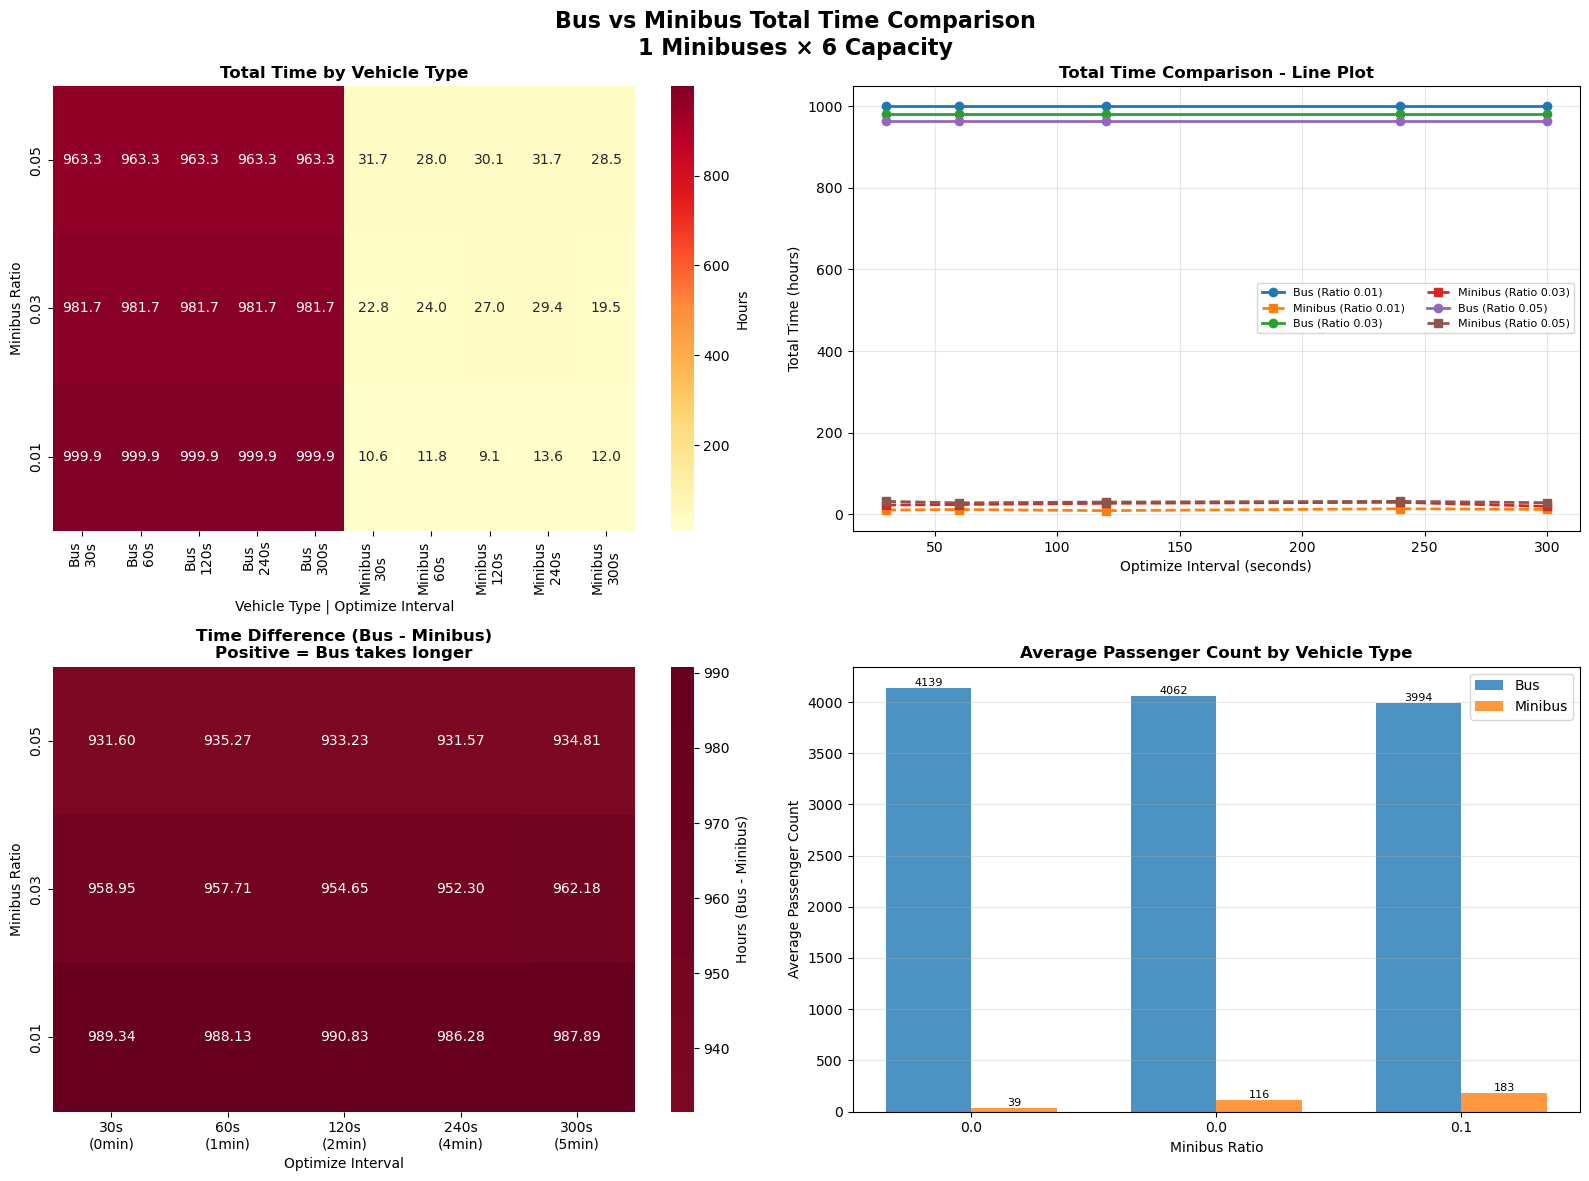

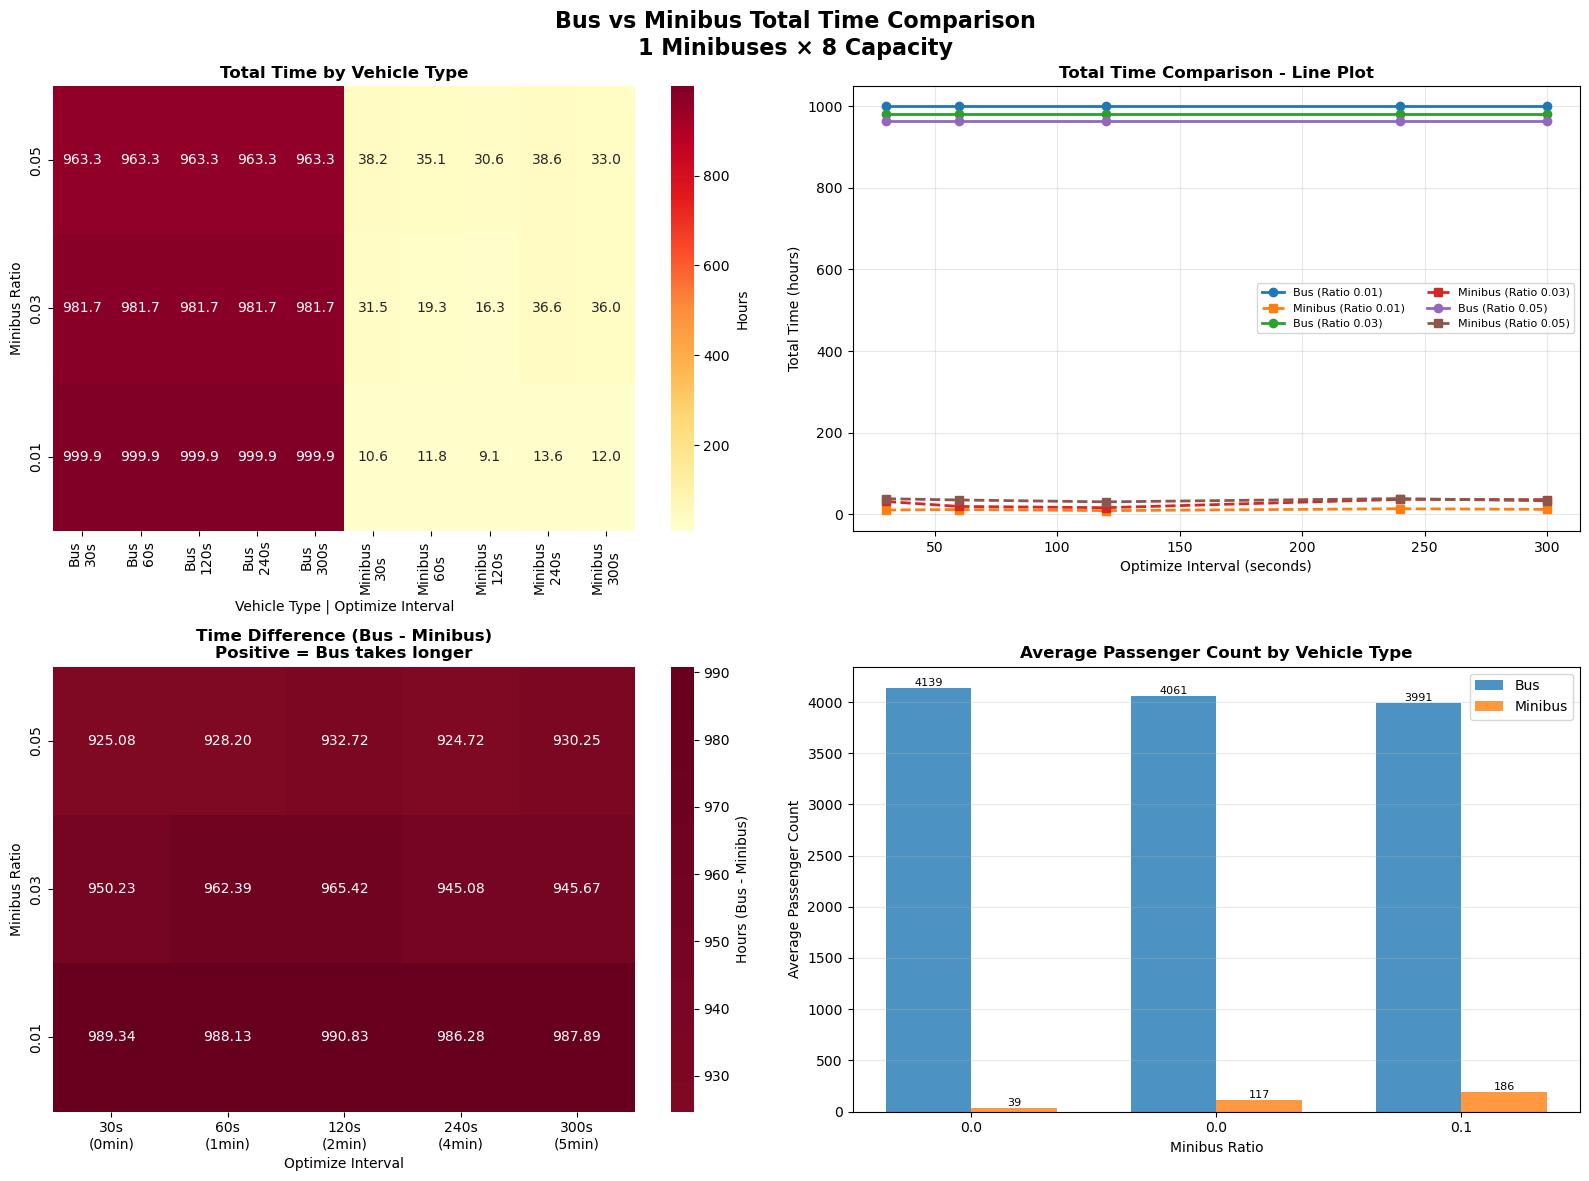

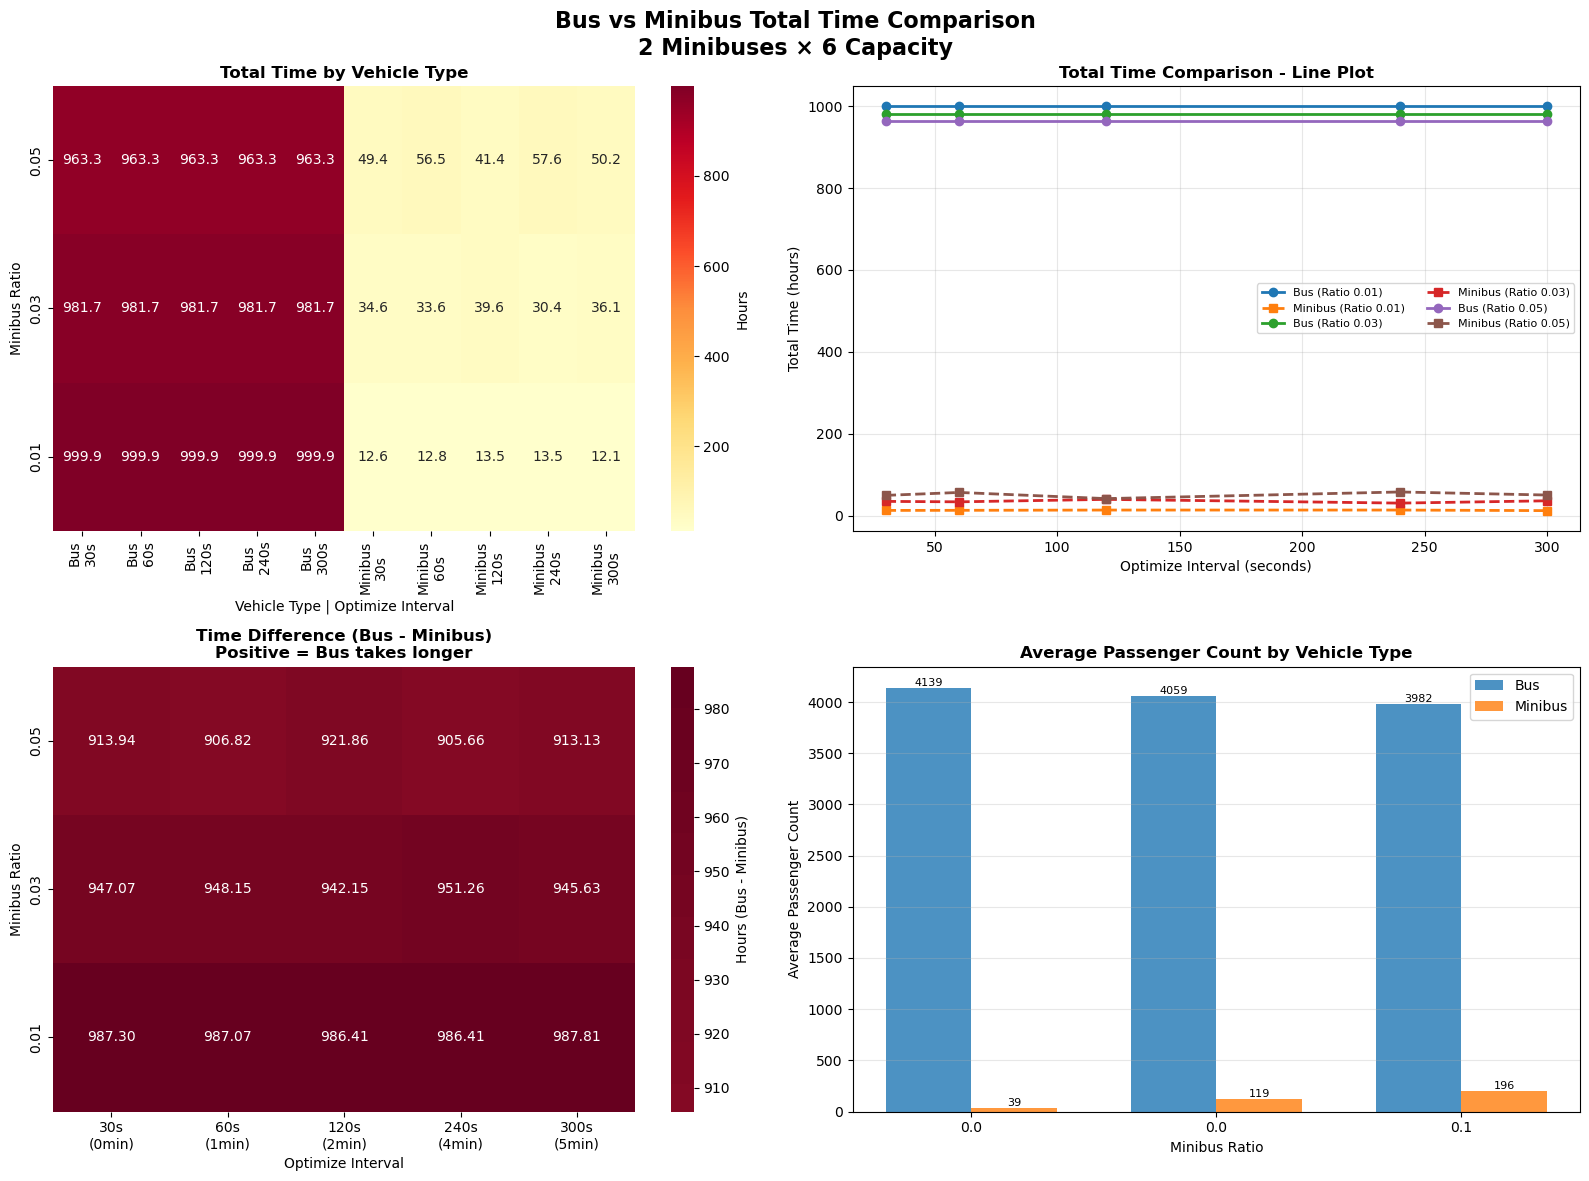

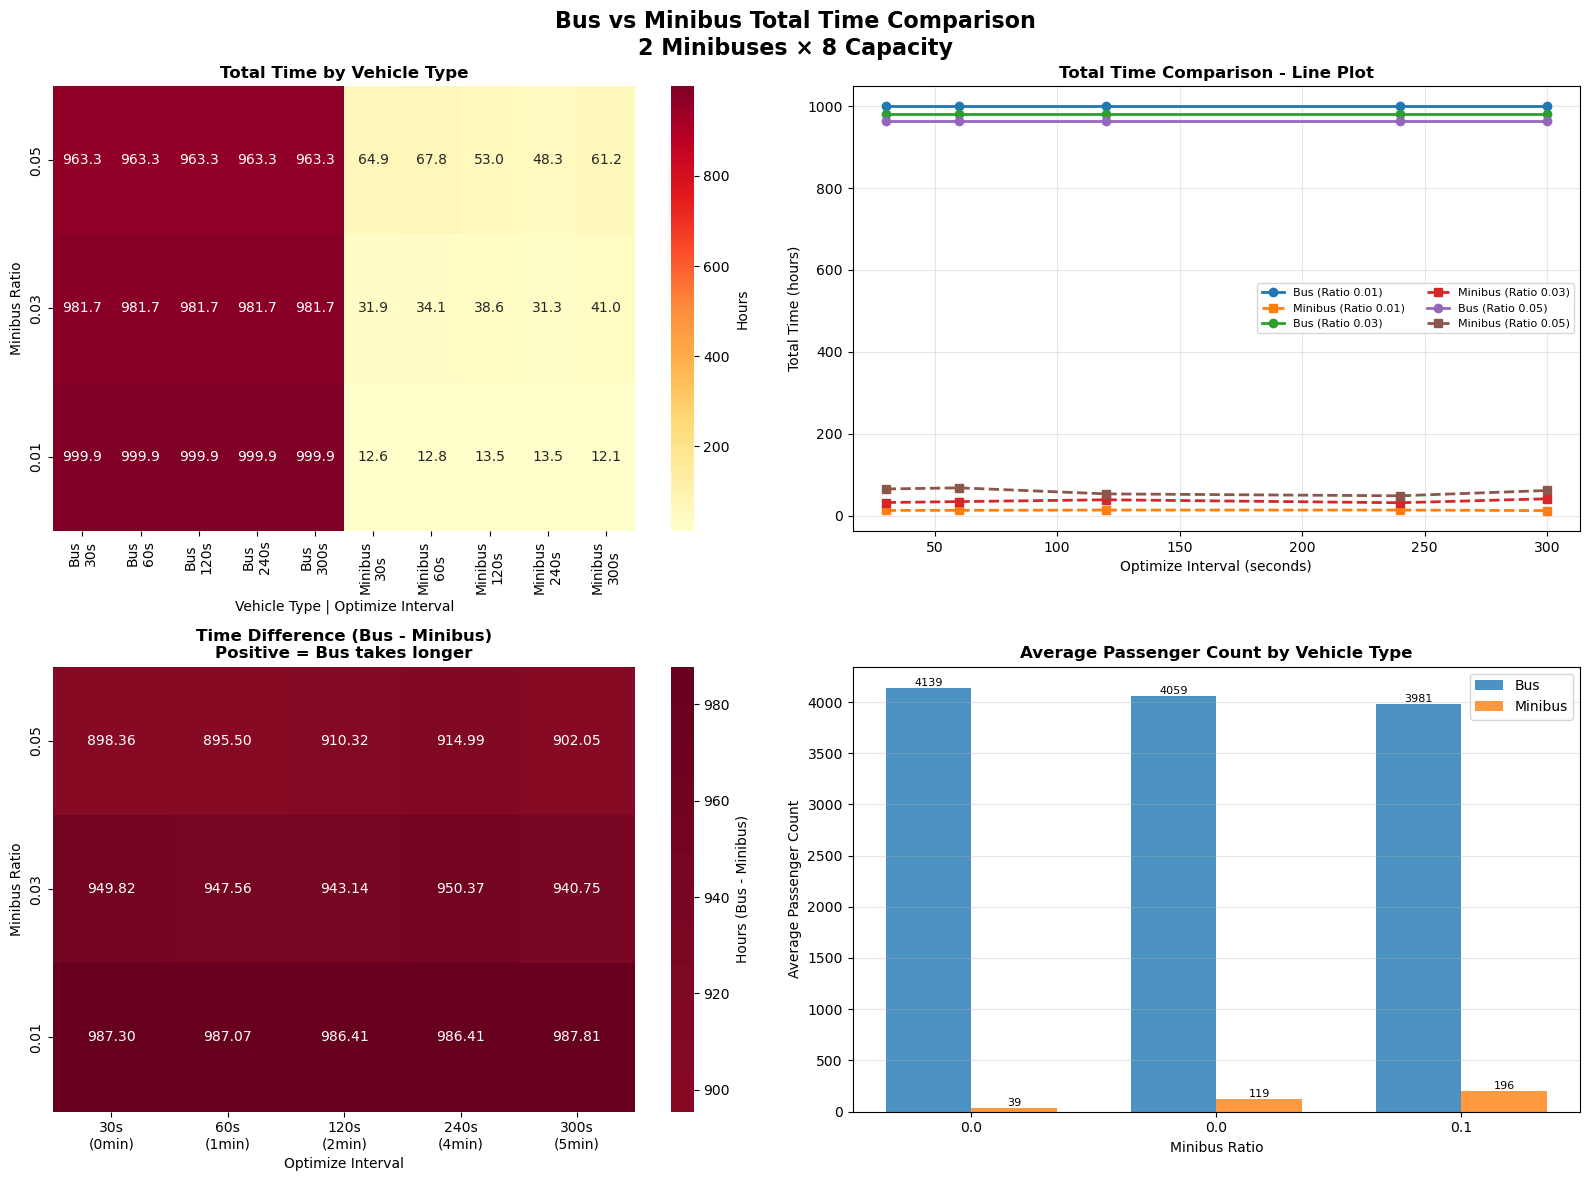

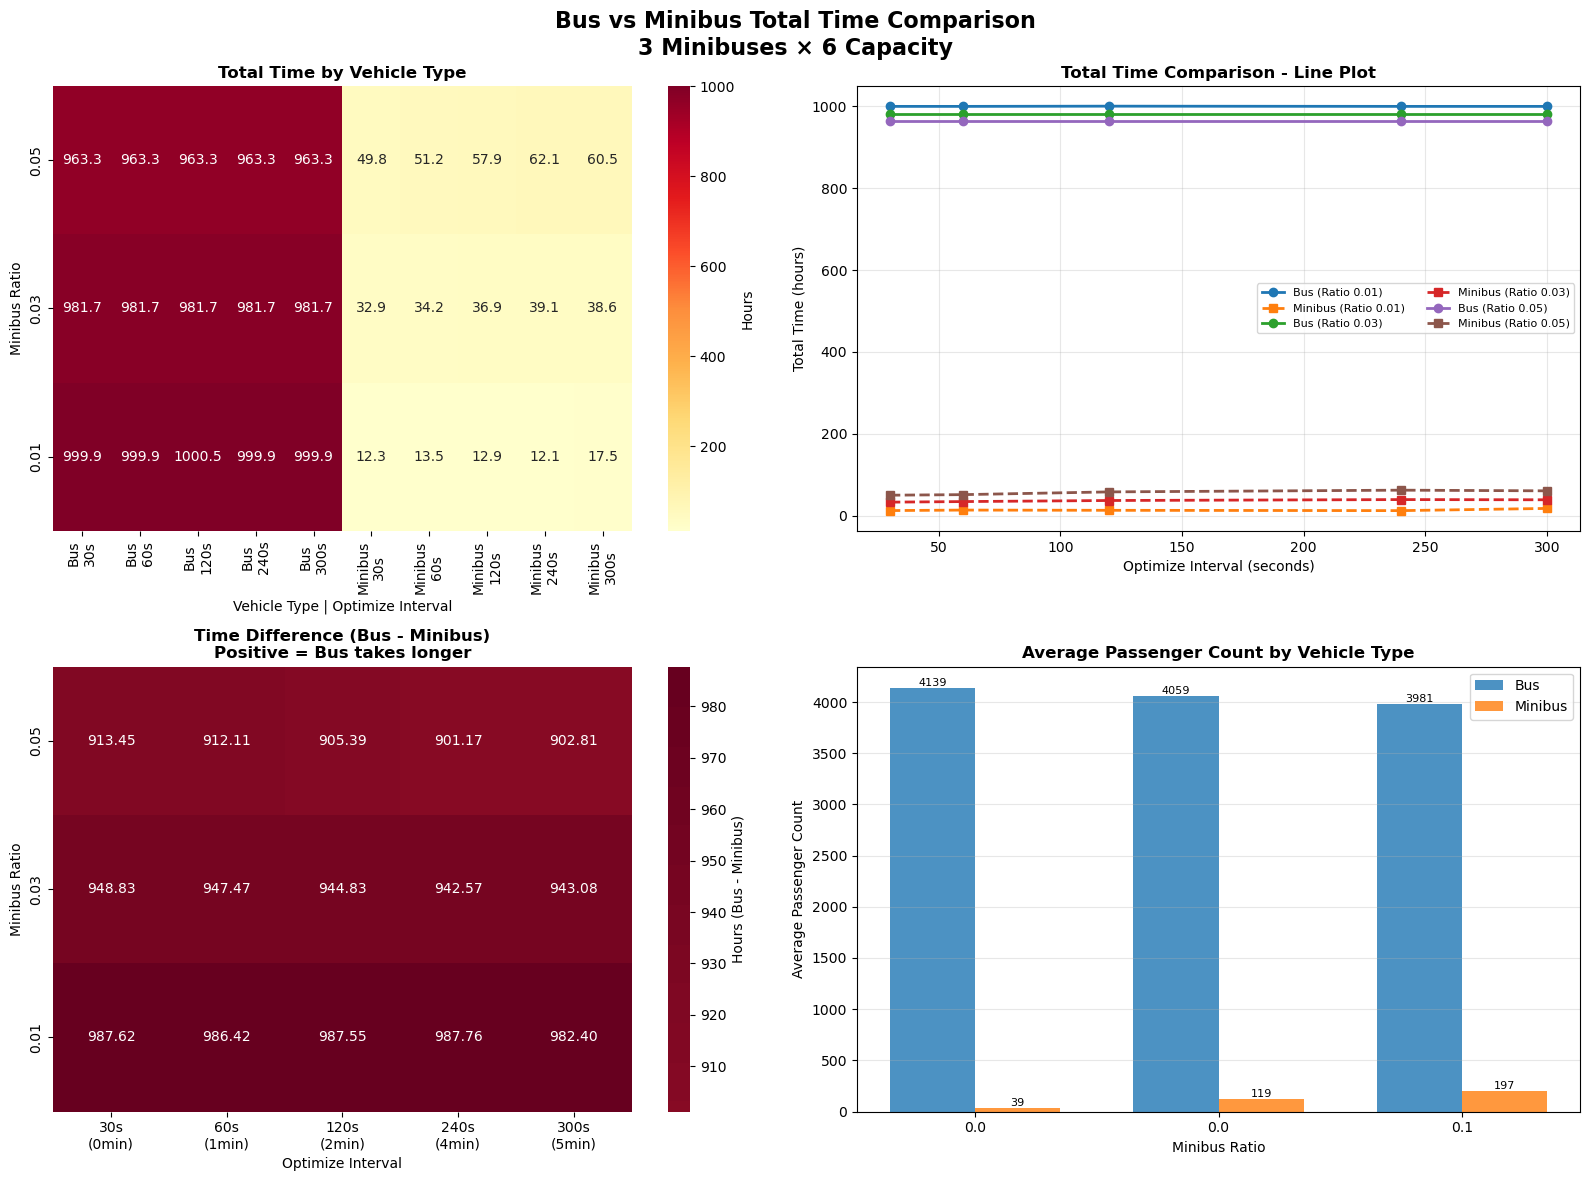

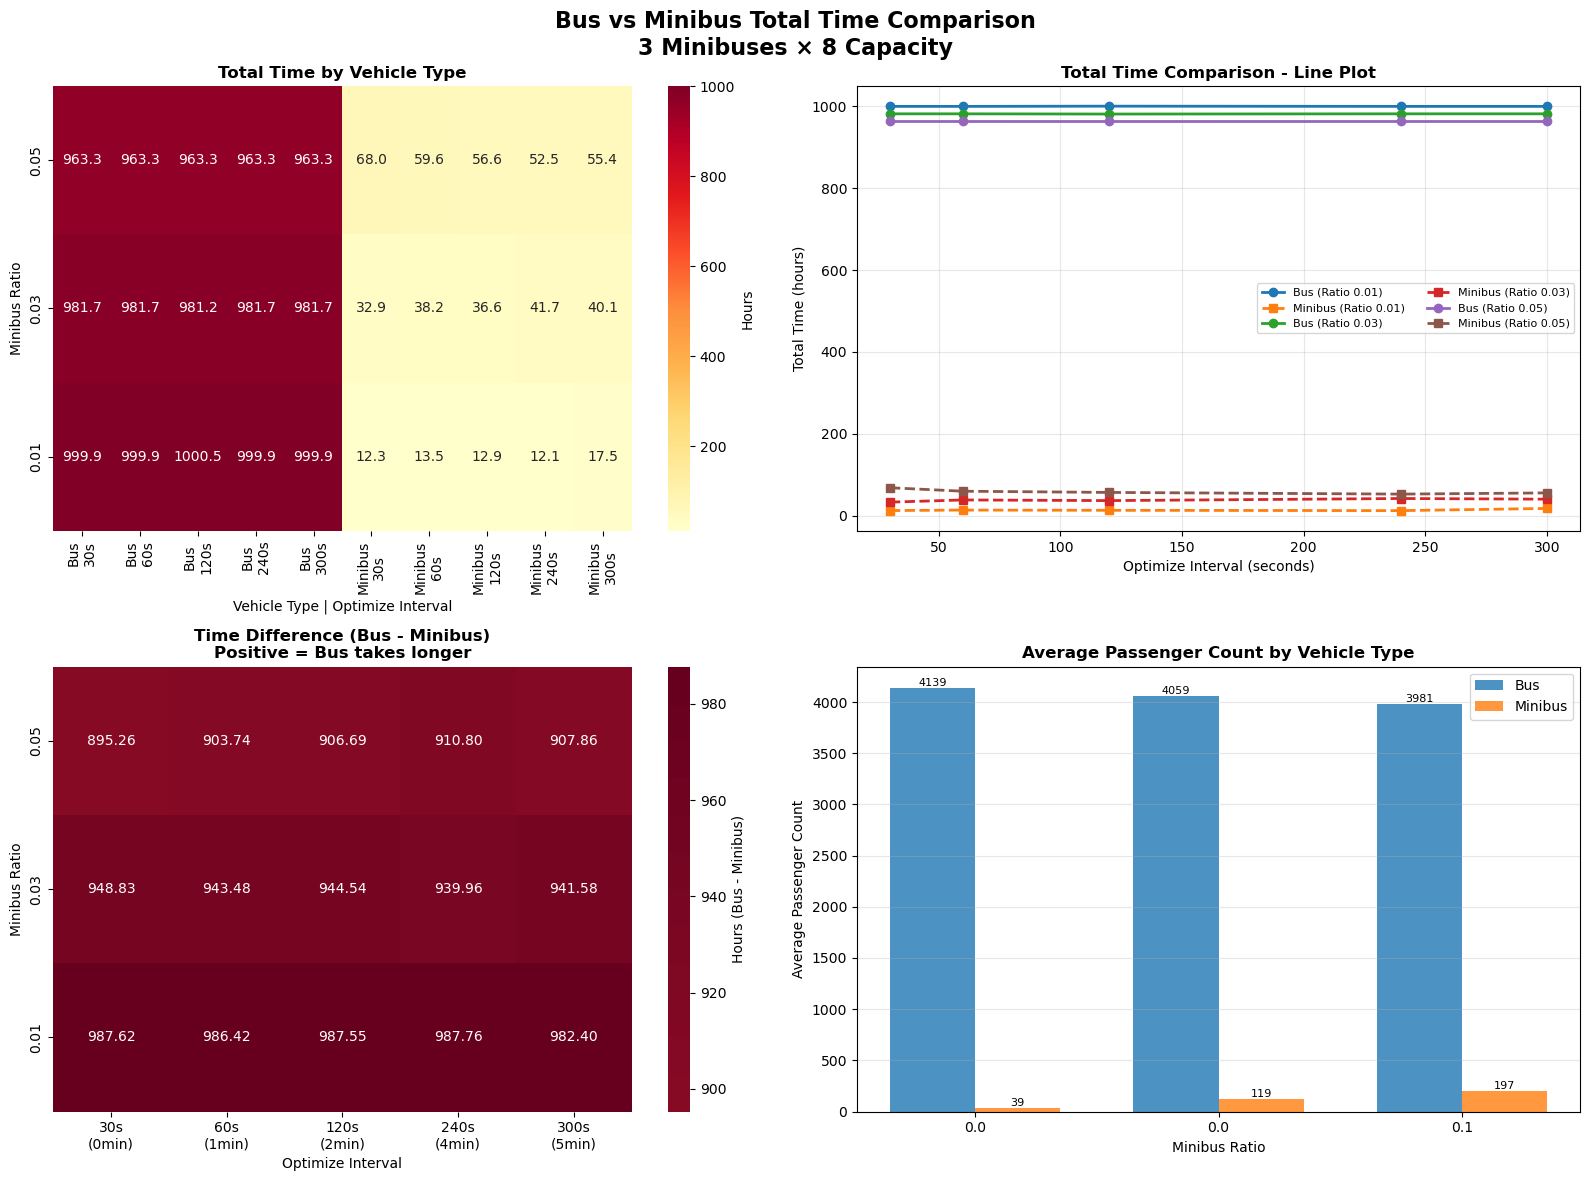

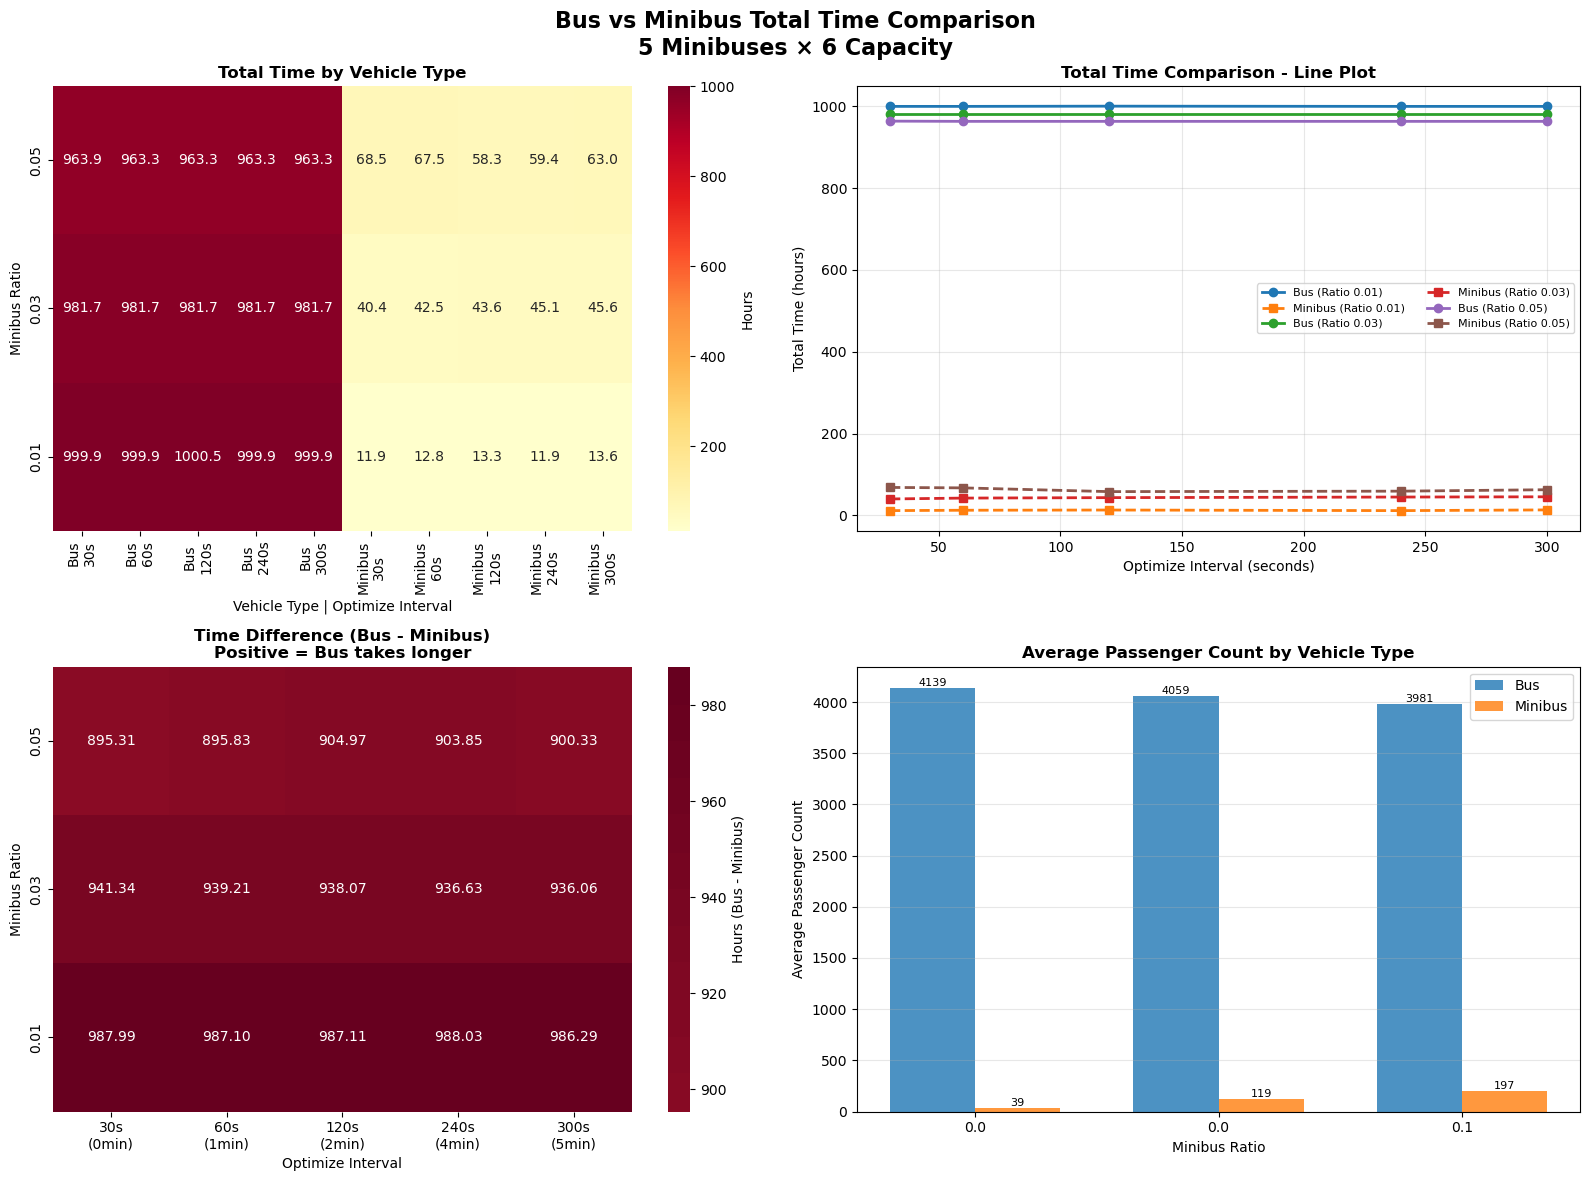

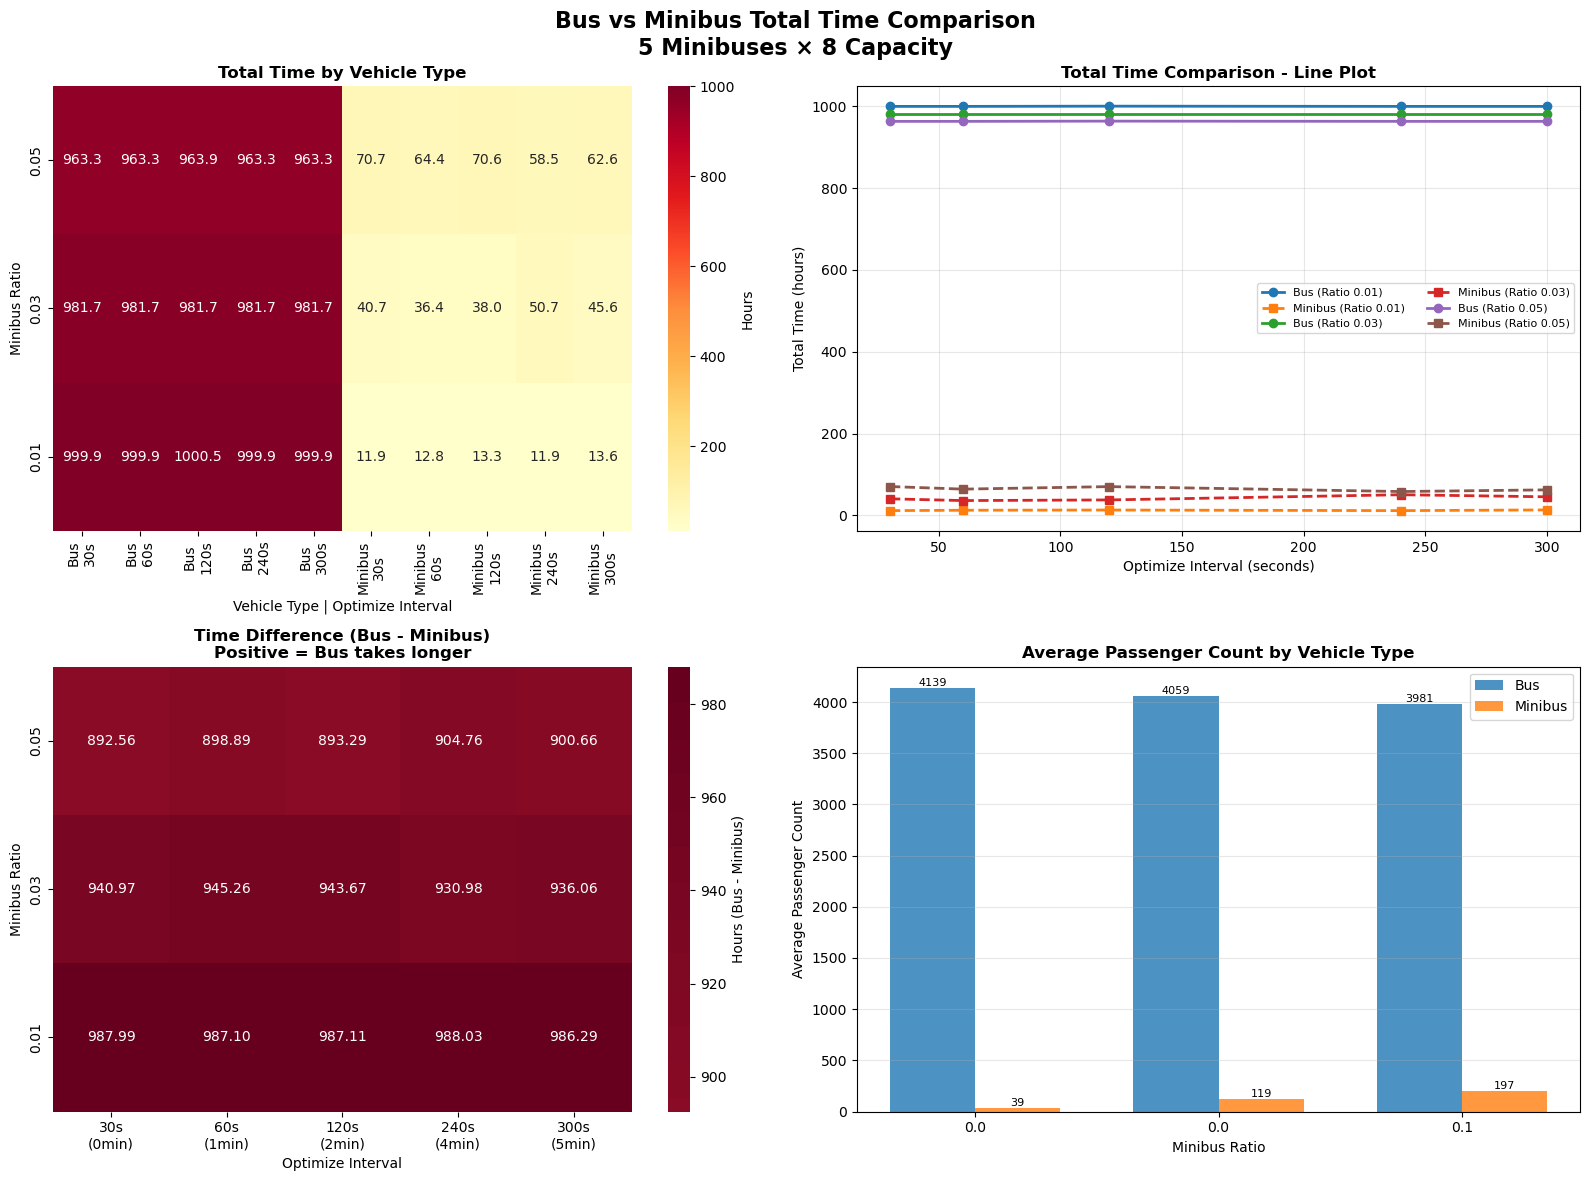

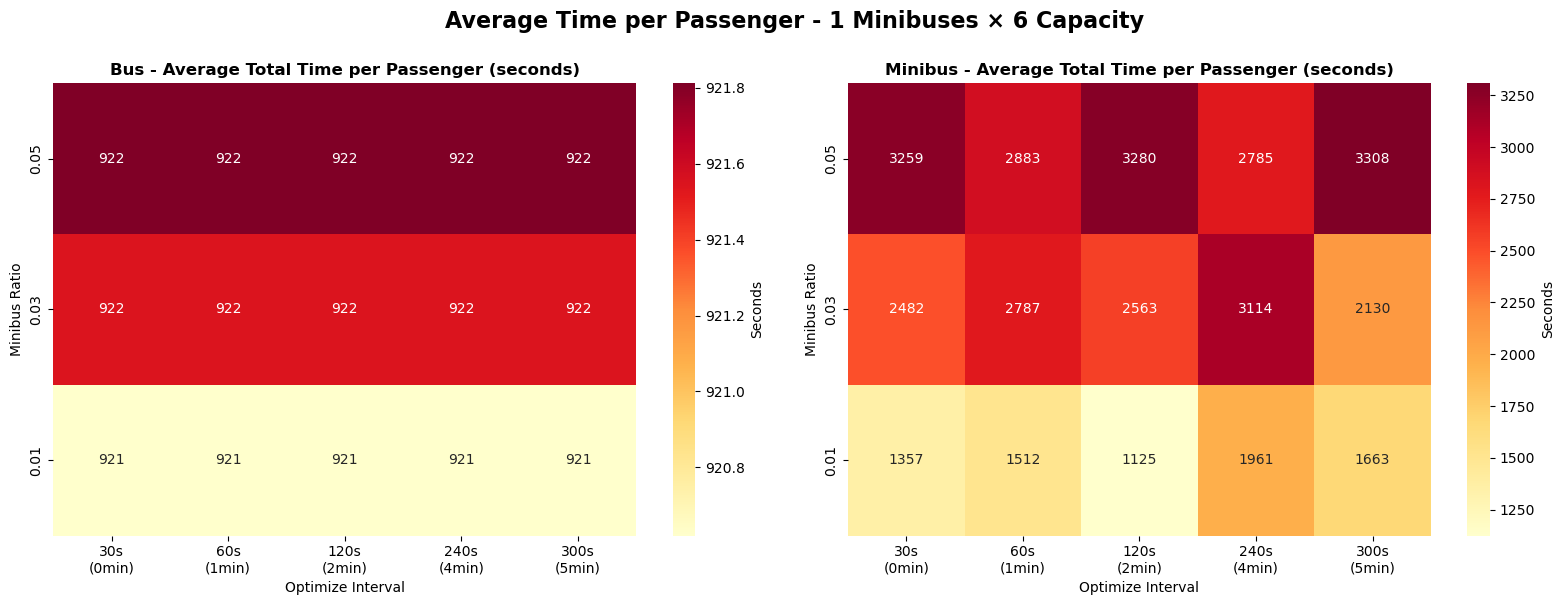

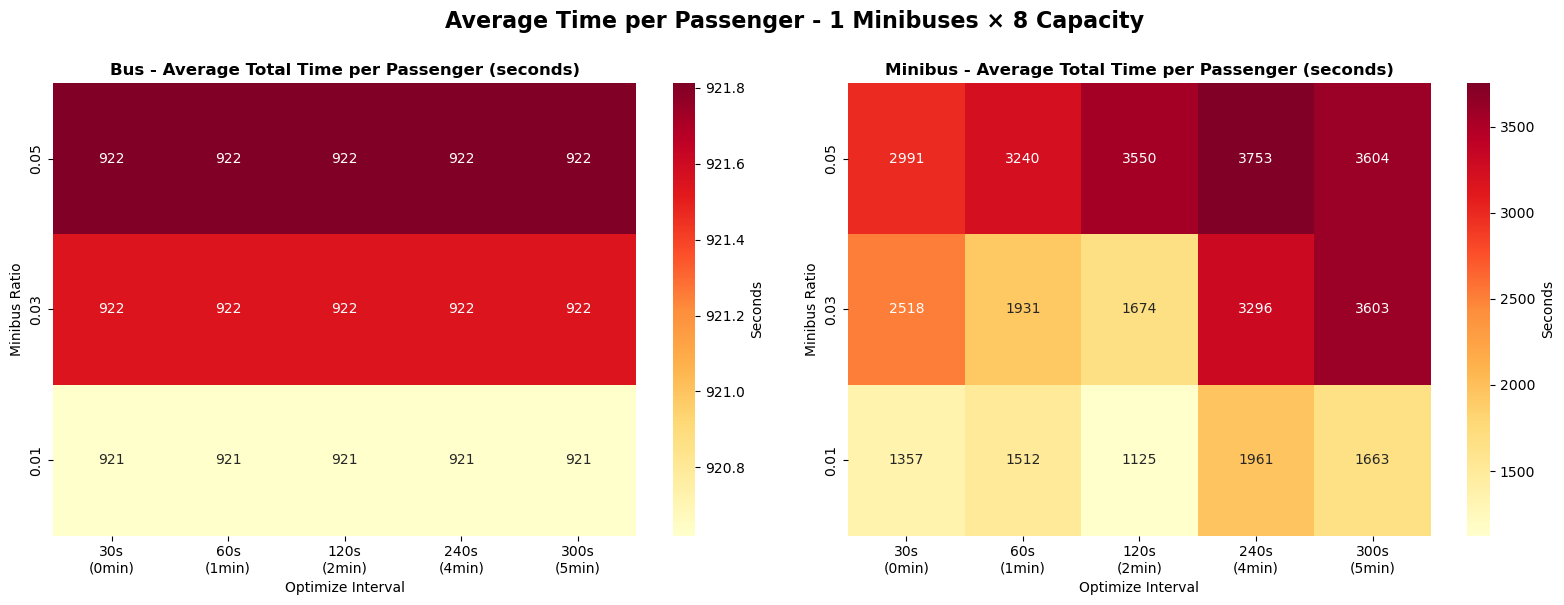

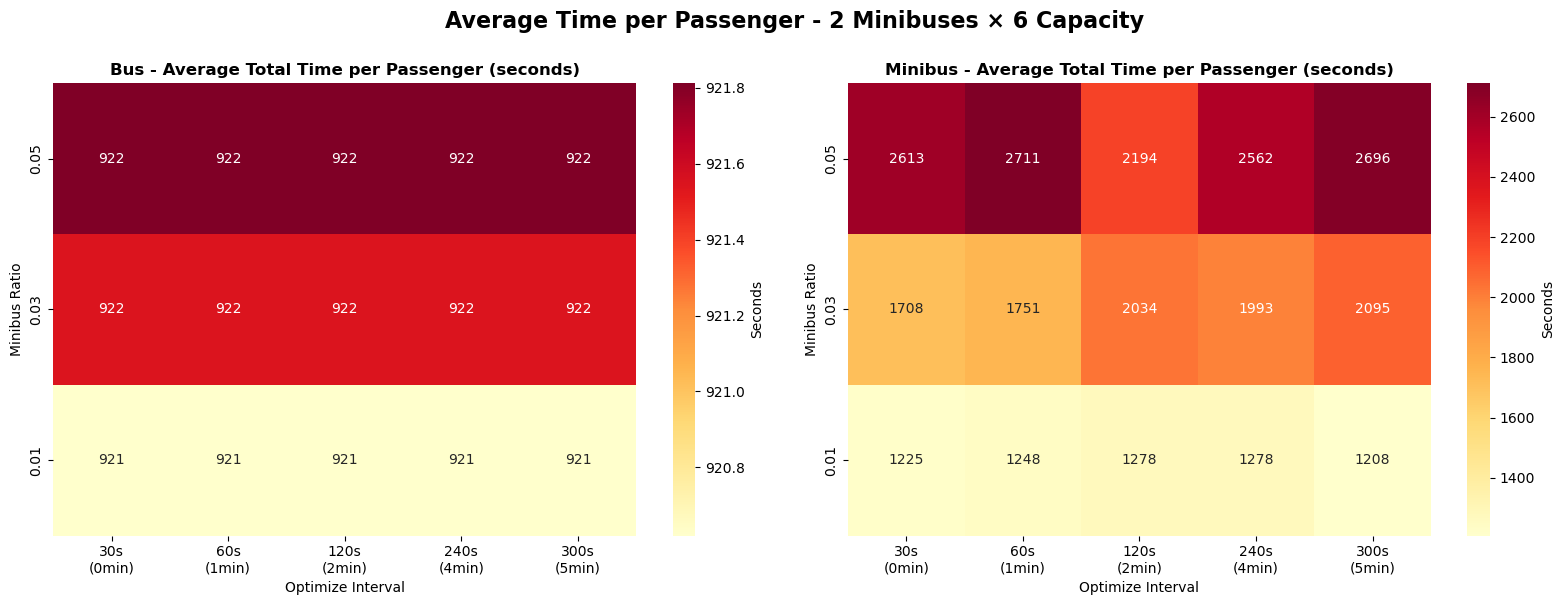

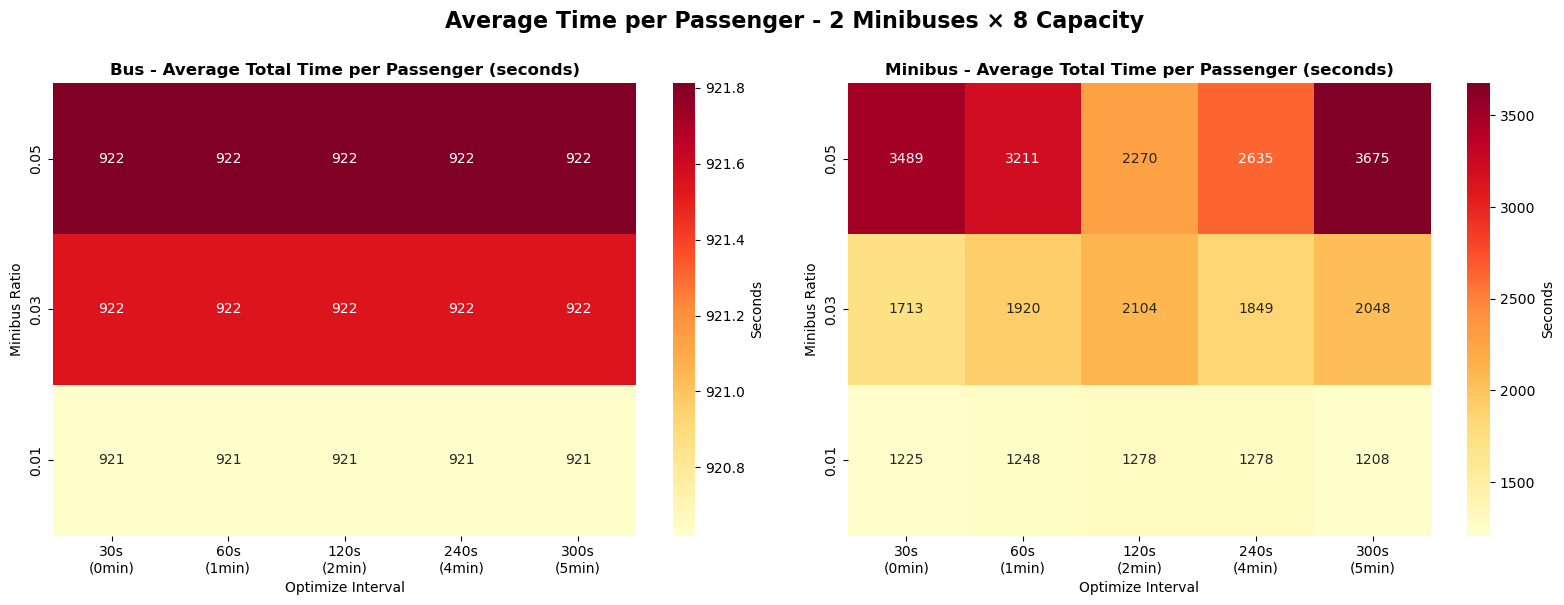

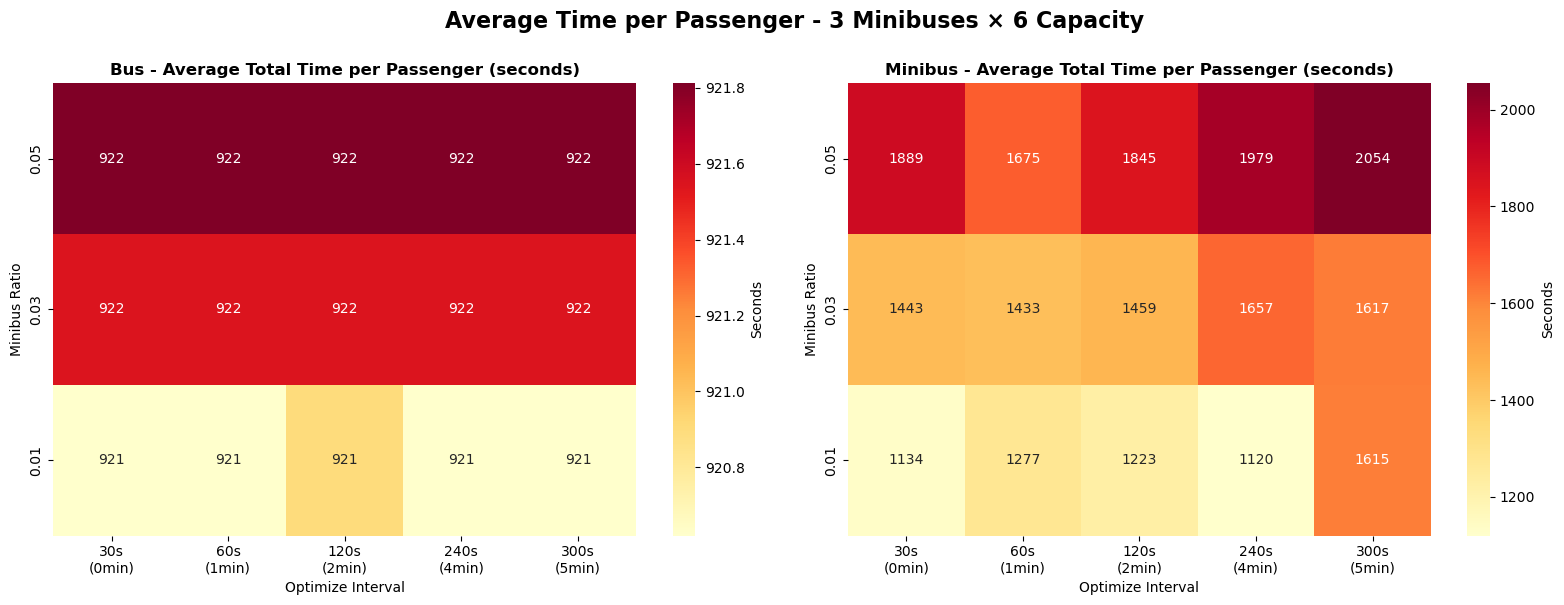

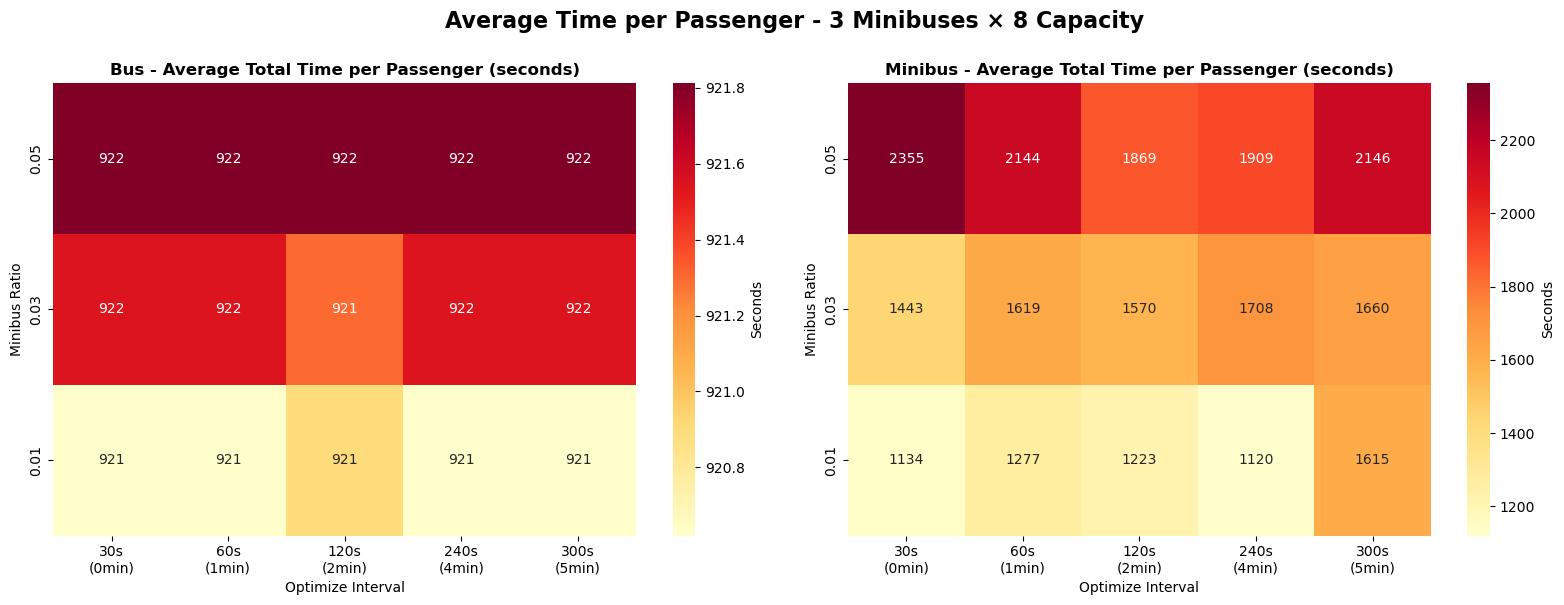

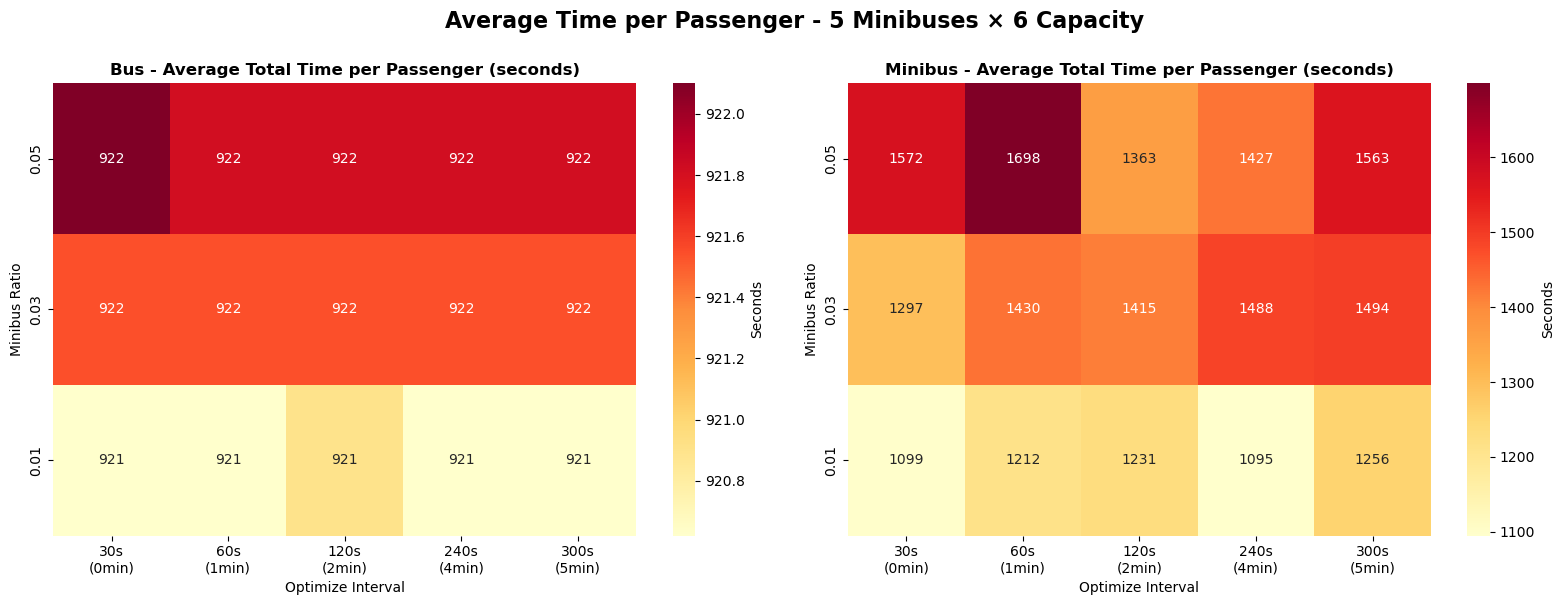

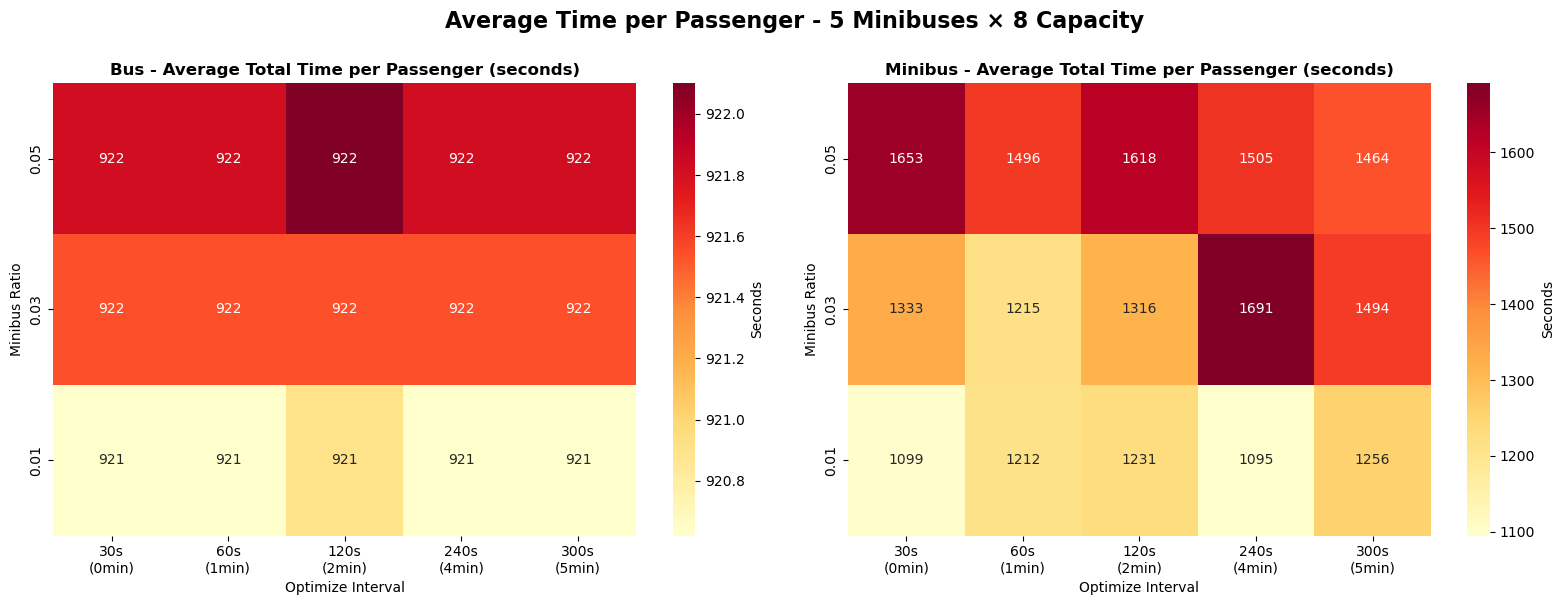

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Read CSV file
df = pd.read_csv('batch_results/Minibus_ratio_results/experiment_summary.csv')

# Check if optimization_interval column exists
if 'optimization_interval' not in df.columns:
    print("Warning: 'optimization_interval' column not found. Using original visualization.")
    has_optimize_interval = False
else:
    has_optimize_interval = True
    print(f"Found optimization_interval values: {sorted(df['optimization_interval'].unique())}")

# Check if vehicle-specific columns exist
has_vehicle_specific = all(col in df.columns for col in [
    'bus_avg_total_time', 'bus_total_total_time_hours', 
    'minibus_avg_total_time', 'minibus_total_total_time_hours'
])

if has_vehicle_specific:
    print("Found vehicle-specific total time columns!")
else:
    print("Warning: Vehicle-specific columns not found in CSV")

# Create a label column for display
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)

# Create a sorting key to control the order (2×6, 2×8, 2×10, 3×6, 3×8, 3×10)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("\nUnique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']].drop_duplicates().sort_values('sort_key'))

# ============================================================================
# OPTION 1: Separate plots for each optimization_interval (ENHANCED)
# ============================================================================
if has_optimize_interval:
    optimize_intervals = sorted(df['optimization_interval'].unique())
    
    for opt_interval in optimize_intervals:
        # Filter data for this optimization_interval
        df_filtered = df[df['optimization_interval'] == opt_interval]
        
        # Create FIVE heatmaps (original 3 + Bus + Minibus)
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Optimize Interval = {opt_interval}s ({opt_interval//60} min)', 
                     fontsize=16, fontweight='bold', y=0.995)
        
        axes = axes.flatten()
        
        # Prepare data - create pivot tables for each metric
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time - All (hours)', axes[2]),
            ('bus_total_total_time_hours', 'Total Time - Bus Only (hours)', axes[3]),
            ('minibus_total_total_time_hours', 'Total Time - Minibus Only (hours)', axes[4])
        ]
        
        for metric_col, title, ax in metrics:
            # Skip if column doesn't exist
            if metric_col not in df_filtered.columns:
                ax.text(0.5, 0.5, f'{title}\n(Data not available)', 
                       ha='center', va='center', fontsize=12)
                ax.axis('off')
                continue
            
            # Create pivot table with capacity_label as columns
            pivot_data = df_filtered.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='sort_key',
                aggfunc='mean'
            )
            
            # Create mapping from sort_key to display label
            label_mapping = df_filtered[['sort_key', 'capacity_label']].drop_duplicates().set_index('sort_key')['capacity_label'].to_dict()
            
            # Rename columns to display labels
            pivot_data.columns = [label_mapping[col] for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Number × Capacity', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        # Hide the last subplot (we have 5 metrics in 6 positions)
        axes[5].axis('off')
        
        plt.tight_layout()
        # plt.savefig(f'heatmap_opt_{opt_interval}s.png', dpi=300, bbox_inches='tight')
        # print(f"\nSaved: heatmap_opt_{opt_interval}s.png")

# ============================================================================
# OPTION 2: Combined comparison plots showing effect of optimization_interval (ENHANCED)
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating comparison plots across optimize intervals...")
    print("="*70)
    
    # For each capacity configuration, show how metrics vary with optimization_interval and ratio
    capacity_configs = df.groupby(['num_minibuses', 'minibus_capacity']).size().index.tolist()
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        fig.suptitle(f'Configuration: {num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=0.995)
        
        axes = axes.flatten()
        
        metrics = [
            ('total_wait_time_hours', 'Total Wait Time (hours)', axes[0]),
            ('total_travel_time_hours', 'Total Travel Time (hours)', axes[1]),
            ('total_total_time_hours', 'Total Time - All (hours)', axes[2]),
            ('bus_total_total_time_hours', 'Total Time - Bus Only (hours)', axes[3]),
            ('minibus_total_total_time_hours', 'Total Time - Minibus Only (hours)', axes[4])
        ]
        
        for metric_col, title, ax in metrics:
            # Skip if column doesn't exist
            if metric_col not in df_config.columns:
                ax.text(0.5, 0.5, f'{title}\n(Data not available)', 
                       ha='center', va='center', fontsize=12)
                ax.axis('off')
                continue
            
            # Create pivot table: ratio vs optimization_interval
            pivot_data = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            
            # Rename columns to show minutes
            pivot_data.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot_data.columns]
            
            # Plot heatmap
            sns.heatmap(
                pivot_data,
                annot=True,
                fmt='.1f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Hours'}
            )
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            
            # Invert y-axis so ratio goes from small to large
            ax.invert_yaxis()
        
        # Hide the last subplot
        axes[5].axis('off')
        
        plt.tight_layout()
        filename = f'comparison_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# OPTION 3: Line plots showing trends (ENHANCED)
# ============================================================================
if has_optimize_interval:
    print("\n" + "="*70)
    print("Creating line plots showing trends...")
    print("="*70)
    
    # Create line plots for each metric (EXPANDED)
    metrics_to_plot = [
        ('total_wait_time_hours', 'Total Wait Time (hours)'),
        ('total_travel_time_hours', 'Total Travel Time (hours)'),
        ('total_total_time_hours', 'Total Time - All (hours)'),
        ('bus_total_total_time_hours', 'Total Time - Bus Only (hours)'),
        ('minibus_total_total_time_hours', 'Total Time - Minibus Only (hours)'),
        ('service_rate', 'Service Rate (%)')
    ]
    
    for metric_col, metric_name in metrics_to_plot:
        # Skip if column doesn't exist
        if metric_col not in df.columns:
            print(f"Skipping {metric_name} - column not found")
            continue
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f'{metric_name} - Effect of Optimize Interval', 
                     fontsize=16, fontweight='bold', y=1.00)
        axes = axes.flatten()
        
        # For each capacity configuration
        for idx, (num_minibuses, capacity) in enumerate(capacity_configs):
            if idx >= len(axes):
                break
                
            ax = axes[idx]
            df_config = df[(df['num_minibuses'] == num_minibuses) & 
                           (df['minibus_capacity'] == capacity)]
            
            # Plot lines for each minibus_ratio
            for ratio in sorted(df_config['minibus_ratio'].unique()):
                df_ratio = df_config[df_config['minibus_ratio'] == ratio]
                df_ratio_sorted = df_ratio.sort_values('optimization_interval')
                
                ax.plot(df_ratio_sorted['optimization_interval'], 
                       df_ratio_sorted[metric_col],
                       marker='o', 
                       label=f'Ratio {ratio}',
                       linewidth=2,
                       markersize=6)
            
            ax.set_title(f'{num_minibuses} Minibuses × {capacity} Capacity', 
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval (seconds)', fontsize=10)
            ax.set_ylabel(metric_name, fontsize=10)
            ax.legend(loc='best', fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add secondary x-axis showing minutes
            ax2 = ax.twiny()
            ax2.set_xlim(ax.get_xlim())
            ax2.set_xticks(ax.get_xticks())
            ax2.set_xticklabels([f'{int(x//60)}min' for x in ax.get_xticks()], fontsize=8)
        
        # Hide unused subplots
        for idx in range(len(capacity_configs), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        filename = f'lineplot_{metric_col}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# NEW: Comparison plot - Bus vs Minibus total time
# ============================================================================
if has_optimize_interval and has_vehicle_specific:
    print("\n" + "="*70)
    print("Creating Bus vs Minibus comparison plots...")
    print("="*70)
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Bus vs Minibus Total Time Comparison\n{num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=0.98)
        
        # 1. Side-by-side comparison heatmap
        ax = axes[0, 0]
        metrics_compare = [
            ('bus_total_total_time_hours', 'Bus'),
            ('minibus_total_total_time_hours', 'Minibus')
        ]
        
        comparison_data = []
        for metric_col, label in metrics_compare:
            pivot = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            comparison_data.append(pivot)
        
        # Concatenate side by side
        combined = pd.concat(comparison_data, axis=1, keys=['Bus', 'Minibus'])
        
        # Flatten column names for display
        combined.columns = [f'{vtype}\n{int(opt)}s' for vtype, opt in combined.columns]
        
        sns.heatmap(
            combined,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd',
            ax=ax,
            cbar_kws={'label': 'Hours'}
        )
        ax.set_title('Total Time by Vehicle Type', fontsize=12, fontweight='bold')
        ax.set_xlabel('Vehicle Type | Optimize Interval', fontsize=10)
        ax.set_ylabel('Minibus Ratio', fontsize=10)
        ax.invert_yaxis()
        
        # 2. Line plot - Bus vs Minibus for each ratio
        ax = axes[0, 1]
        for ratio in sorted(df_config['minibus_ratio'].unique()):
            df_ratio = df_config[df_config['minibus_ratio'] == ratio].sort_values('optimization_interval')
            
            ax.plot(df_ratio['optimization_interval'], 
                   df_ratio['bus_total_total_time_hours'],
                   marker='o', 
                   label=f'Bus (Ratio {ratio})',
                   linewidth=2,
                   linestyle='-')
            
            ax.plot(df_ratio['optimization_interval'], 
                   df_ratio['minibus_total_total_time_hours'],
                   marker='s', 
                   label=f'Minibus (Ratio {ratio})',
                   linewidth=2,
                   linestyle='--')
        
        ax.set_title('Total Time Comparison - Line Plot', fontsize=12, fontweight='bold')
        ax.set_xlabel('Optimize Interval (seconds)', fontsize=10)
        ax.set_ylabel('Total Time (hours)', fontsize=10)
        ax.legend(loc='best', fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        
        # 3. Difference heatmap (Bus - Minibus)
        ax = axes[1, 0]
        df_config['time_difference'] = df_config['bus_total_total_time_hours'] - df_config['minibus_total_total_time_hours']
        
        pivot_diff = df_config.pivot_table(
            values='time_difference',
            index='minibus_ratio',
            columns='optimization_interval',
            aggfunc='mean'
        )
        
        pivot_diff.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot_diff.columns]
        
        sns.heatmap(
            pivot_diff,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            ax=ax,
            cbar_kws={'label': 'Hours (Bus - Minibus)'}
        )
        ax.set_title('Time Difference (Bus - Minibus)\nPositive = Bus takes longer', 
                    fontsize=12, fontweight='bold')
        ax.set_xlabel('Optimize Interval', fontsize=10)
        ax.set_ylabel('Minibus Ratio', fontsize=10)
        ax.invert_yaxis()
        
        # 4. Passenger count comparison
        ax = axes[1, 1]
        
        # Average passenger counts across all optimize intervals
        avg_counts = df_config.groupby('minibus_ratio').agg({
            'bus_passenger_count': 'mean',
            'minibus_passenger_count': 'mean'
        })
        
        x = np.arange(len(avg_counts))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, avg_counts['bus_passenger_count'], 
                      width, label='Bus', alpha=0.8)
        bars2 = ax.bar(x + width/2, avg_counts['minibus_passenger_count'], 
                      width, label='Minibus', alpha=0.8)
        
        ax.set_title('Average Passenger Count by Vehicle Type', fontsize=12, fontweight='bold')
        ax.set_xlabel('Minibus Ratio', fontsize=10)
        ax.set_ylabel('Average Passenger Count', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels([f'{r:.1f}' for r in avg_counts.index])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{int(height)}',
                       ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        filename = f'bus_vs_minibus_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# NEW: Average time per passenger comparison
# ============================================================================
if has_optimize_interval and has_vehicle_specific:
    print("\n" + "="*70)
    print("Creating average time per passenger comparison...")
    print("="*70)
    
    for num_minibuses, capacity in capacity_configs:
        df_config = df[(df['num_minibuses'] == num_minibuses) & 
                       (df['minibus_capacity'] == capacity)]
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Average Time per Passenger - {num_minibuses} Minibuses × {capacity} Capacity', 
                     fontsize=16, fontweight='bold', y=1.00)
        
        # Plot for each vehicle type
        for idx, (metric_col, title) in enumerate([
            ('bus_avg_total_time', 'Bus - Average Total Time per Passenger (seconds)'),
            ('minibus_avg_total_time', 'Minibus - Average Total Time per Passenger (seconds)')
        ]):
            ax = axes[idx]
            
            if metric_col not in df_config.columns:
                ax.text(0.5, 0.5, f'{title}\n(Data not available)', 
                       ha='center', va='center', fontsize=12)
                ax.axis('off')
                continue
            
            pivot = df_config.pivot_table(
                values=metric_col,
                index='minibus_ratio',
                columns='optimization_interval',
                aggfunc='mean'
            )
            
            pivot.columns = [f'{int(col)}s\n({int(col//60)}min)' for col in pivot.columns]
            
            sns.heatmap(
                pivot,
                annot=True,
                fmt='.0f',
                cmap='YlOrRd',
                ax=ax,
                cbar_kws={'label': 'Seconds'}
            )
            
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            ax.invert_yaxis()
        
        plt.tight_layout()
        filename = f'avg_time_per_passenger_n{num_minibuses}_c{capacity}.png'
        # plt.savefig(filename, dpi=300, bbox_inches='tight')
        # print(f"Saved: {filename}")

# ============================================================================
# Summary Statistics (ENHANCED)
# ============================================================================
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

if has_optimize_interval:
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Optimize Intervals: {sorted(df['optimization_interval'].unique())} seconds")
    print(f"- Total Experiments: {len(df)}")
    
    # Find best configurations for each metric
    print("\n" + "-"*70)
    print("BEST CONFIGURATIONS (lowest values):")
    print("-"*70)
    
    metrics_to_check = [
        ('total_wait_time_hours', 'Total Wait Time'),
        ('total_travel_time_hours', 'Total Travel Time'),
        ('total_total_time_hours', 'Total Time - All'),
        ('bus_total_total_time_hours', 'Total Time - Bus Only'),
        ('minibus_total_total_time_hours', 'Total Time - Minibus Only')
    ]
    
    for metric_col, metric_name in metrics_to_check:
        if metric_col not in df.columns:
            continue
        
        best_row = df.loc[df[metric_col].idxmin()]
        print(f"\n{metric_name}:")
        print(f"  Value: {best_row[metric_col]:.2f} hours")
        print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
        print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
        print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Best service rate
    best_row = df.loc[df['service_rate'].idxmax()]
    print(f"\nService Rate (highest):")
    print(f"  Value: {best_row['service_rate']:.2f}%")
    print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
    print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
    print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s ({int(best_row['optimization_interval']//60)} min)")
    
    # Effect of optimization_interval
    print("\n" + "-"*70)
    print("EFFECT OF OPTIMIZE INTERVAL (averaged across all configs):")
    print("-"*70)
    
    agg_dict = {
        'total_wait_time_hours': 'mean',
        'total_travel_time_hours': 'mean',
        'total_total_time_hours': 'mean',
        'service_rate': 'mean'
    }
    
    # Add vehicle-specific columns if they exist
    if has_vehicle_specific:
        agg_dict.update({
            'bus_total_total_time_hours': 'mean',
            'minibus_total_total_time_hours': 'mean',
            'bus_avg_total_time': 'mean',
            'minibus_avg_total_time': 'mean',
            'bus_passenger_count': 'mean',
            'minibus_passenger_count': 'mean'
        })
    
    interval_stats = df.groupby('optimization_interval').agg(agg_dict).round(2)
    
    print("\n" + interval_stats.to_string())
    
    # Bus vs Minibus comparison
    if has_vehicle_specific:
        print("\n" + "-"*70)
        print("BUS vs MINIBUS COMPARISON (averaged across all configs):")
        print("-"*70)
        
        print(f"\nAverage Total Time:")
        print(f"  Bus: {df['bus_avg_total_time'].mean():.1f} seconds ({df['bus_avg_total_time'].mean()/60:.1f} minutes)")
        print(f"  Minibus: {df['minibus_avg_total_time'].mean():.1f} seconds ({df['minibus_avg_total_time'].mean()/60:.1f} minutes)")
        print(f"  Difference: {df['bus_avg_total_time'].mean() - df['minibus_avg_total_time'].mean():.1f} seconds")
        
        print(f"\nTotal Passenger-Hours:")
        print(f"  Bus: {df['bus_total_total_time_hours'].mean():.2f} hours")
        print(f"  Minibus: {df['minibus_total_total_time_hours'].mean():.2f} hours")
        
        print(f"\nAverage Passenger Count:")
        print(f"  Bus: {df['bus_passenger_count'].mean():.0f} passengers")
        print(f"  Minibus: {df['minibus_passenger_count'].mean():.0f} passengers")

else:
    # Original summary for data without optimization_interval
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label']==x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Total Experiments: {len(df)}")

print("\n" + "="*70)
print("All visualizations generated successfully!")
print("="*70)


Found optimization_interval values: [np.int64(30), np.int64(60), np.int64(120), np.int64(240), np.int64(300)]
Found vehicle-specific total time columns!
Calculated bus_avg_time_per_person
Calculated minibus_avg_time_per_person

Unique capacity labels:
     num_minibuses  minibus_capacity capacity_label  sort_key
0                1                 6            1×6       106
15               1                 8            1×8       108
30               2                 6            2×6       206
45               2                 8            2×8       208
60               3                 6            3×6       306
75               3                 8            3×8       308
90               5                 6            5×6       506
105              5                 8            5×8       508

GLOBAL NORMALIZATION (paper-safe):
  abandoned: vmin=228.0, vmax=385.0
  bus_minutes: vmin=14.422104867911647, vmax=14.52881652812055
  minibus_minutes: vmin=7.8333191942612945, vmax=27.298

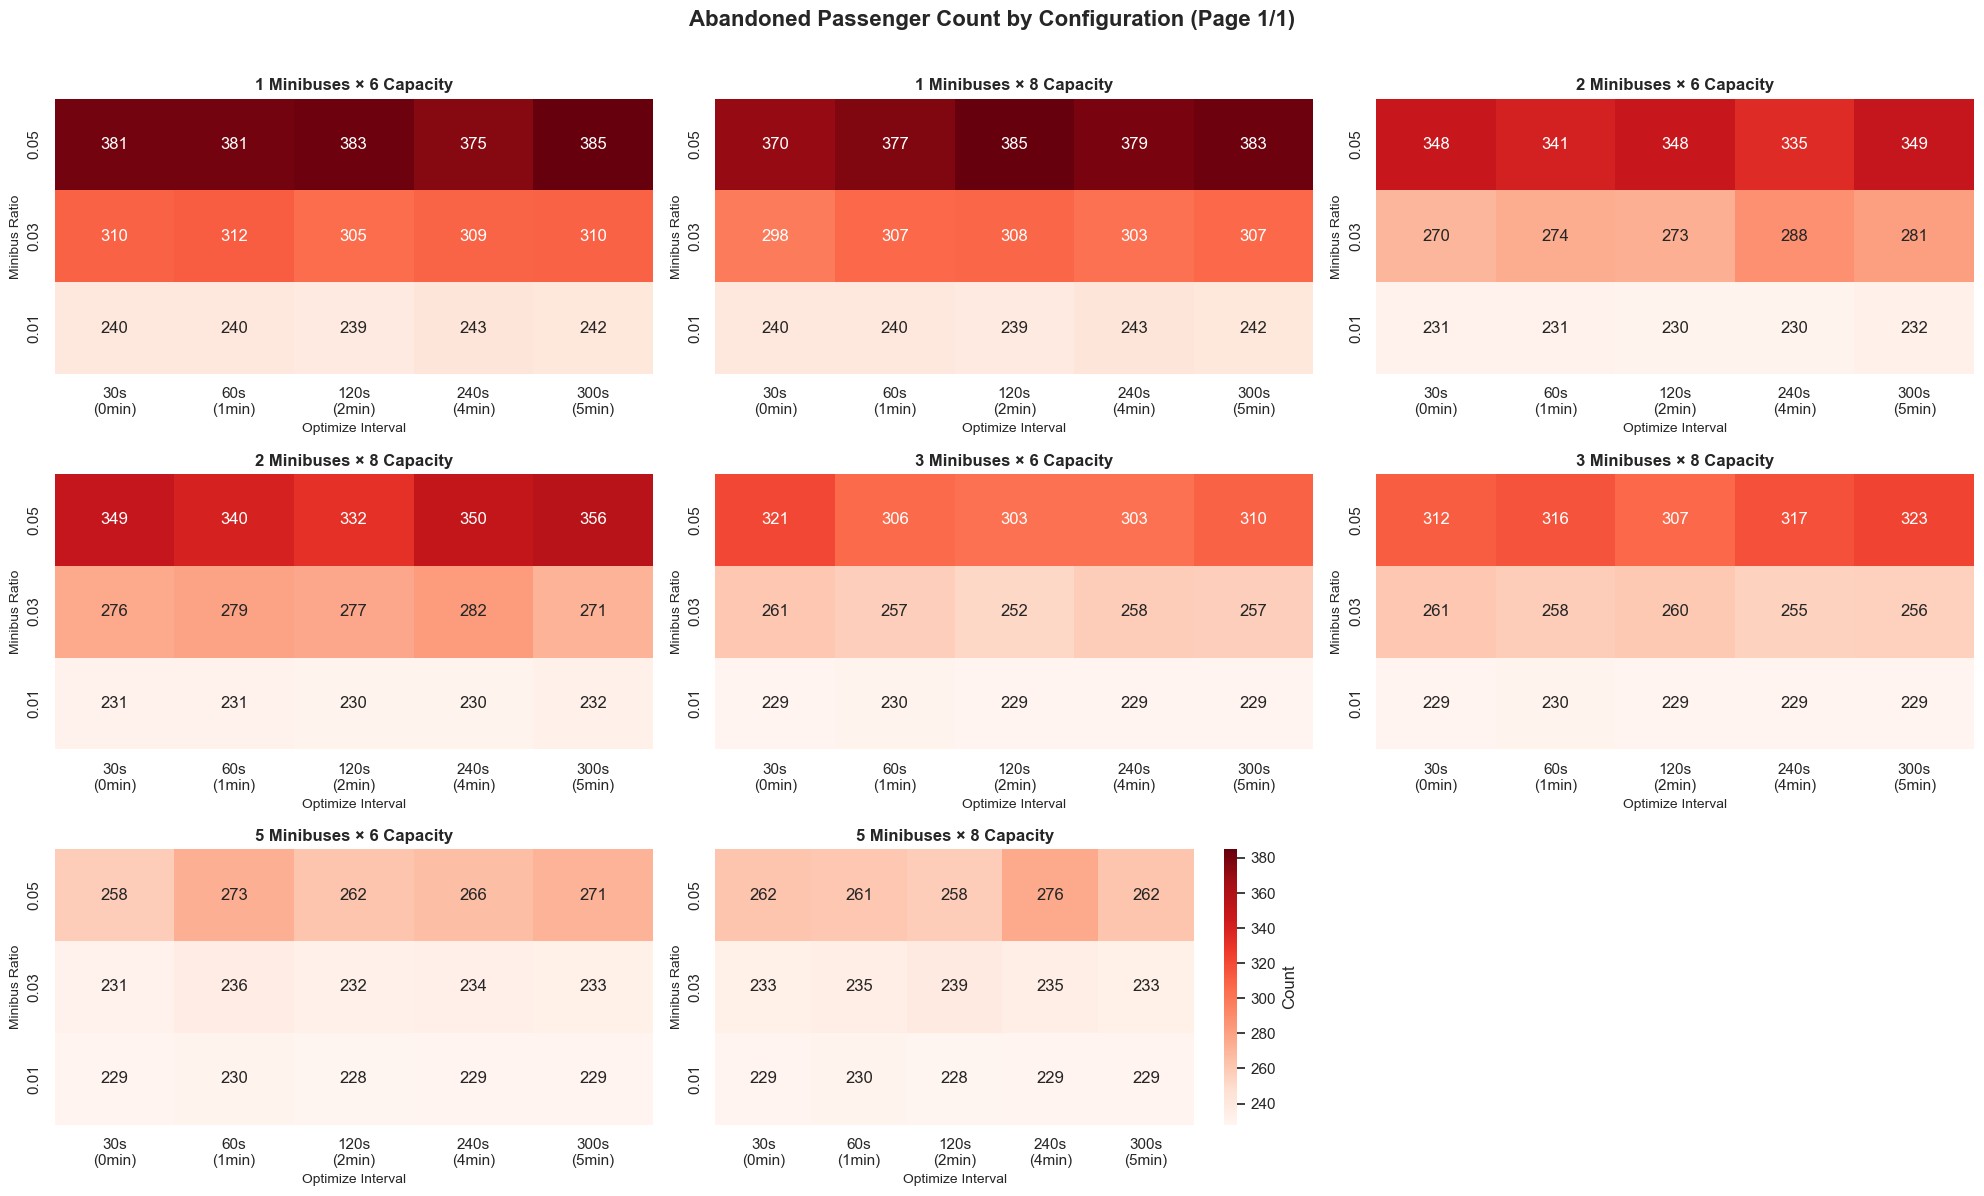

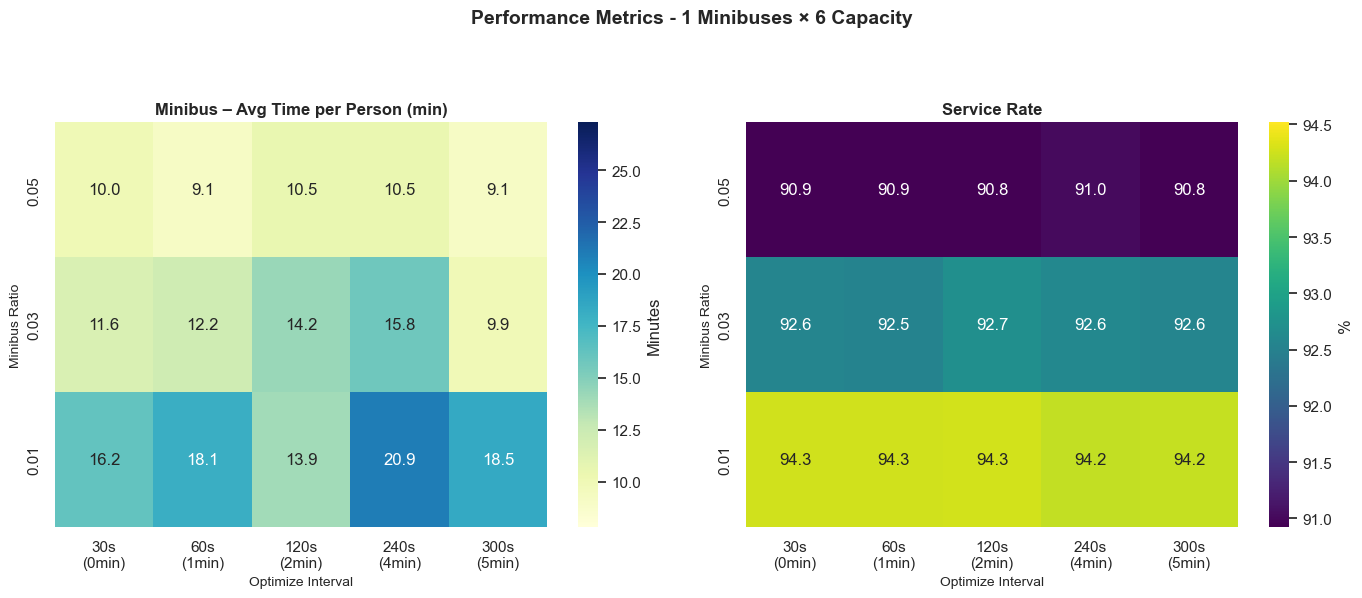

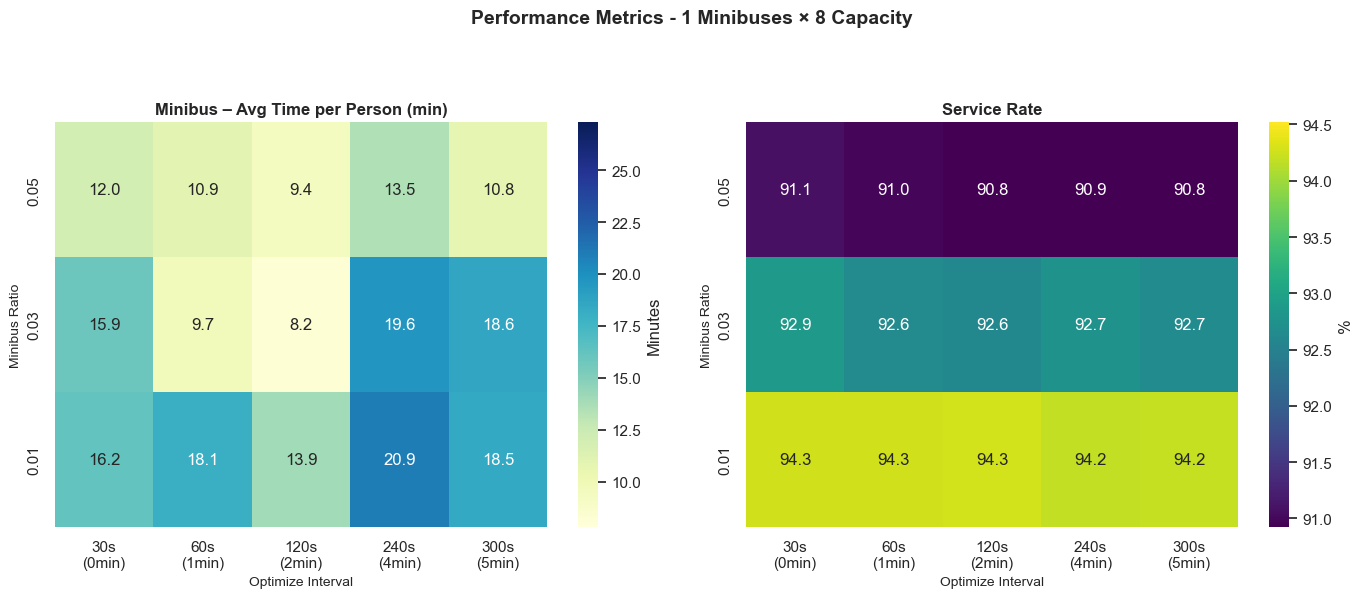

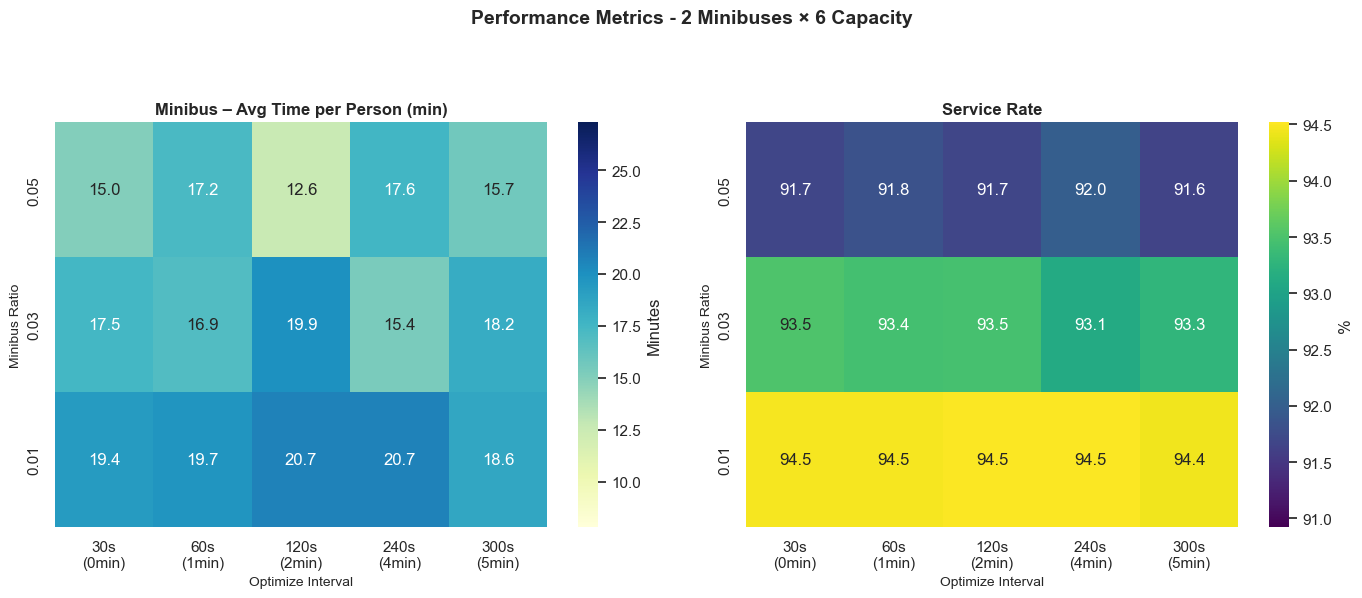

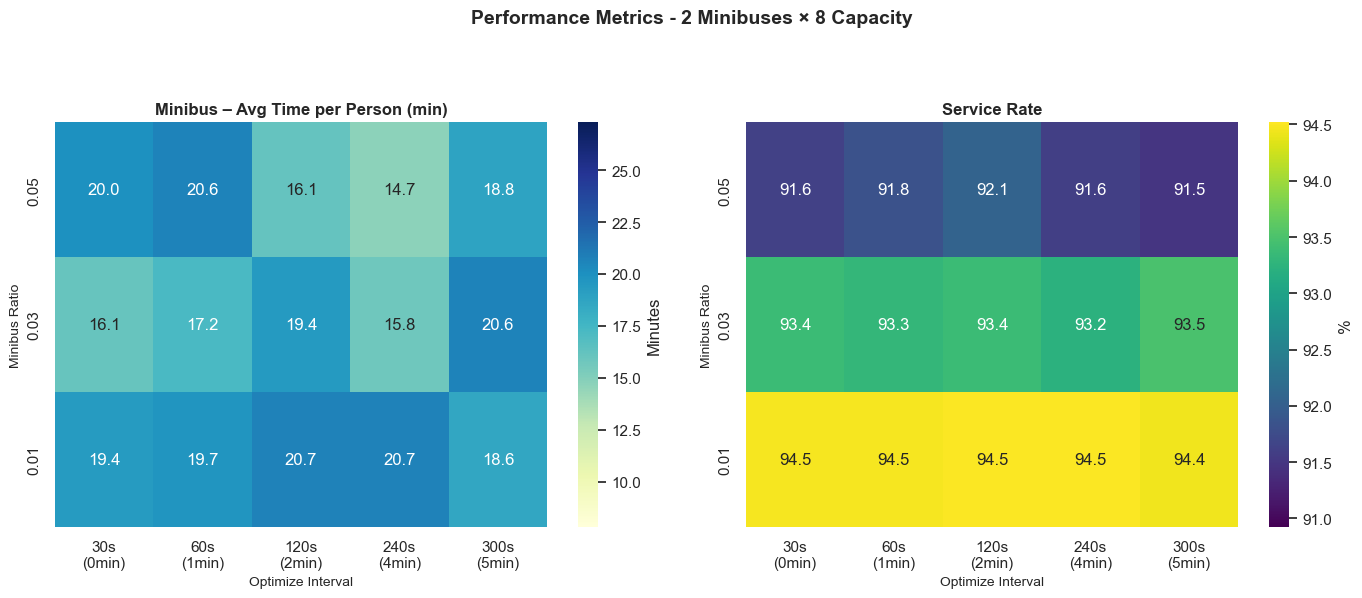

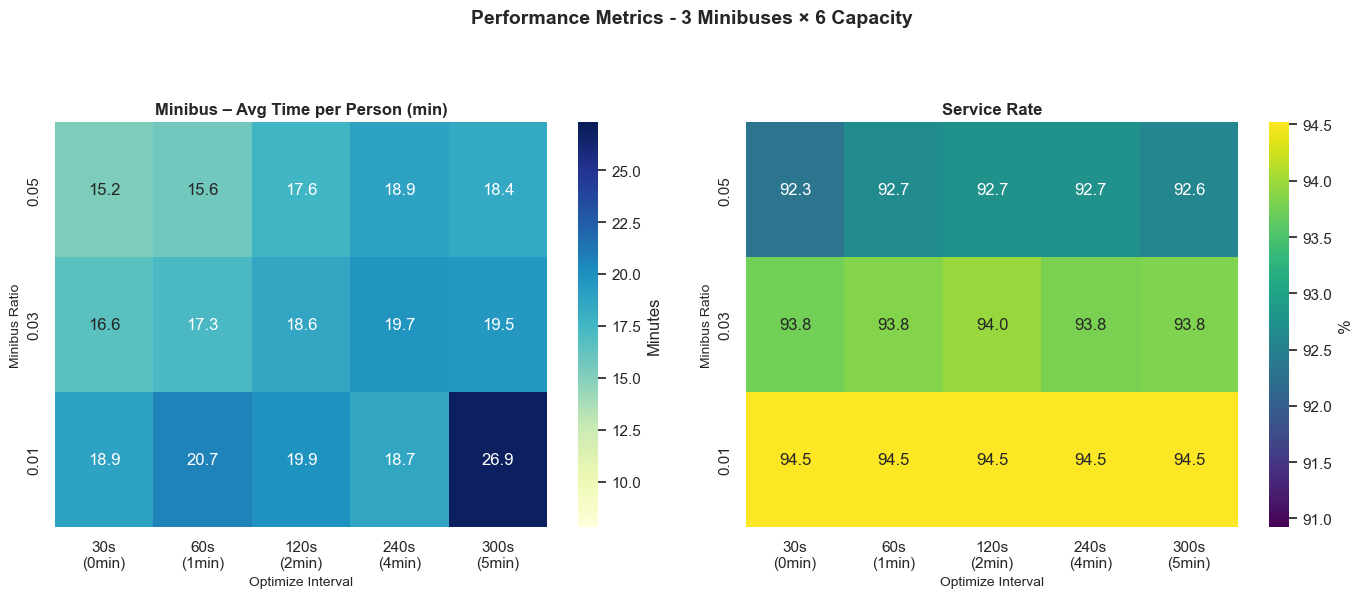

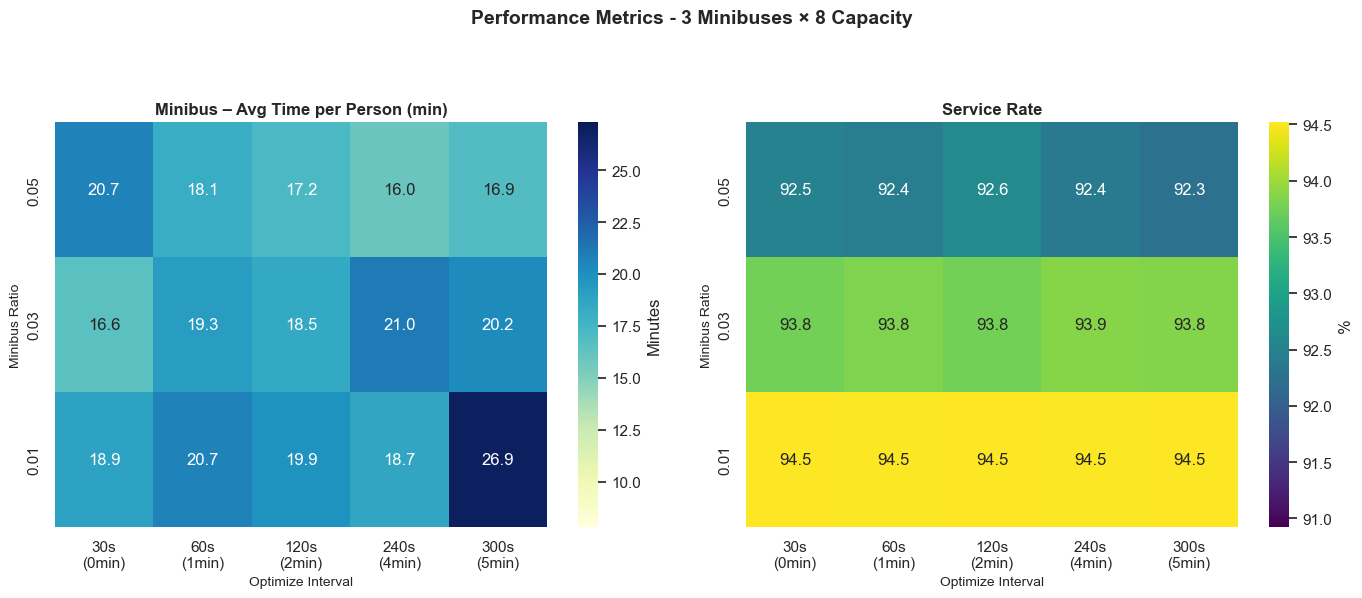

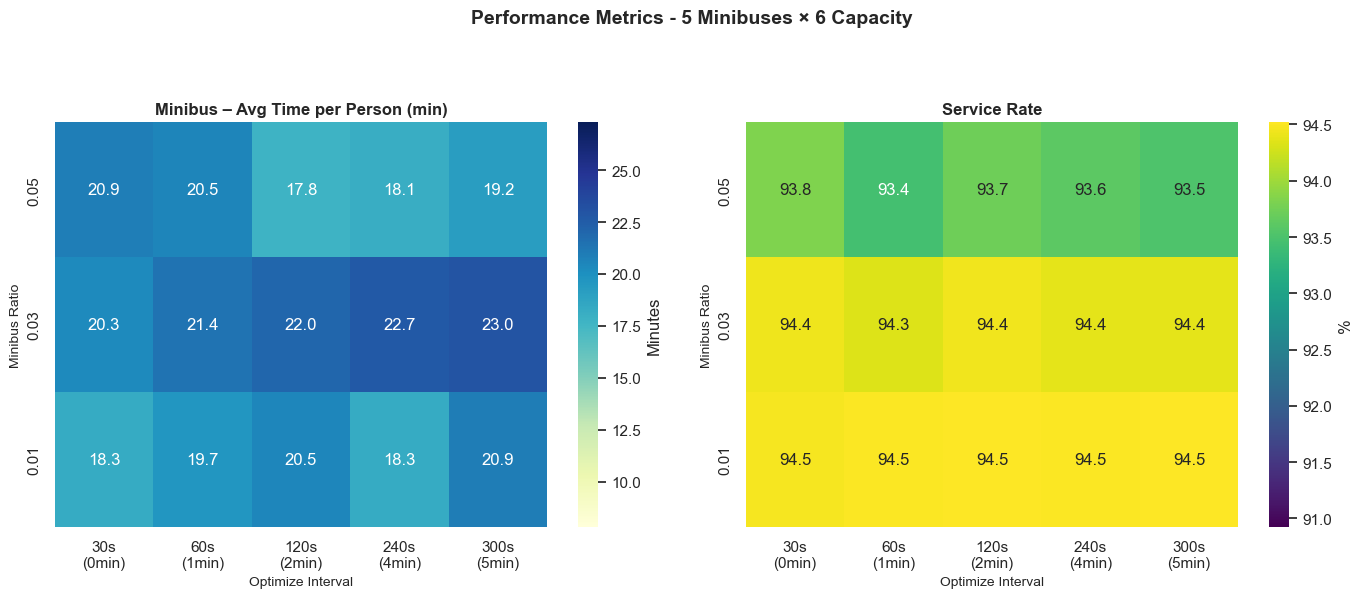

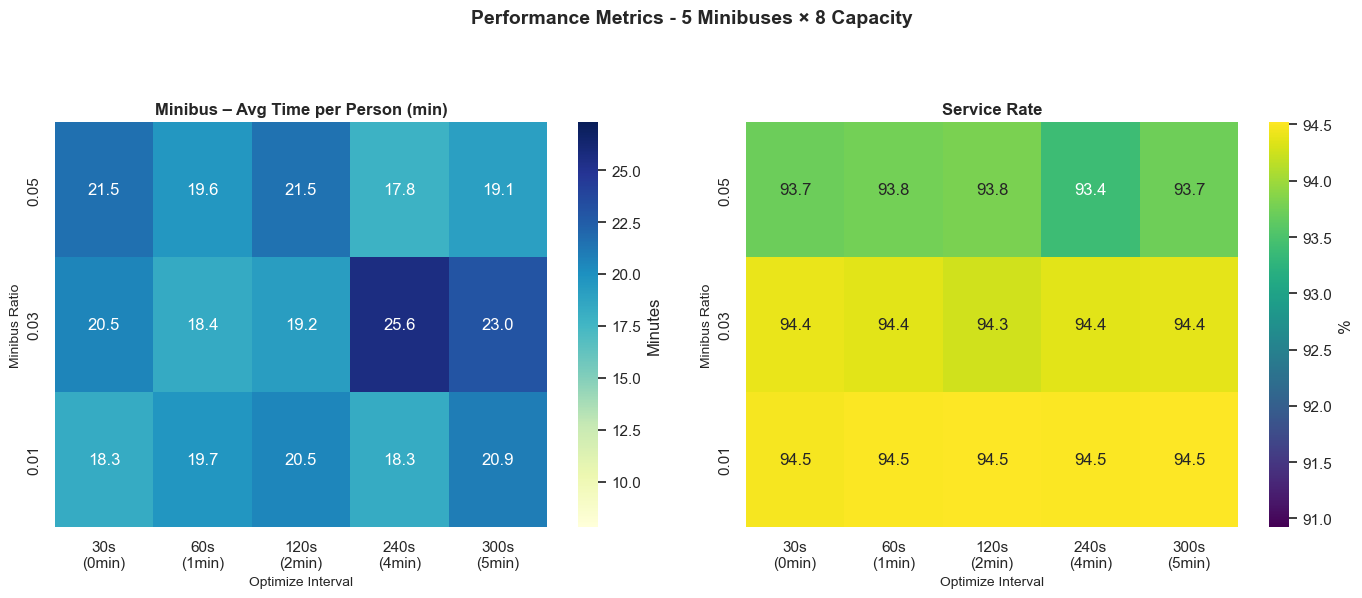

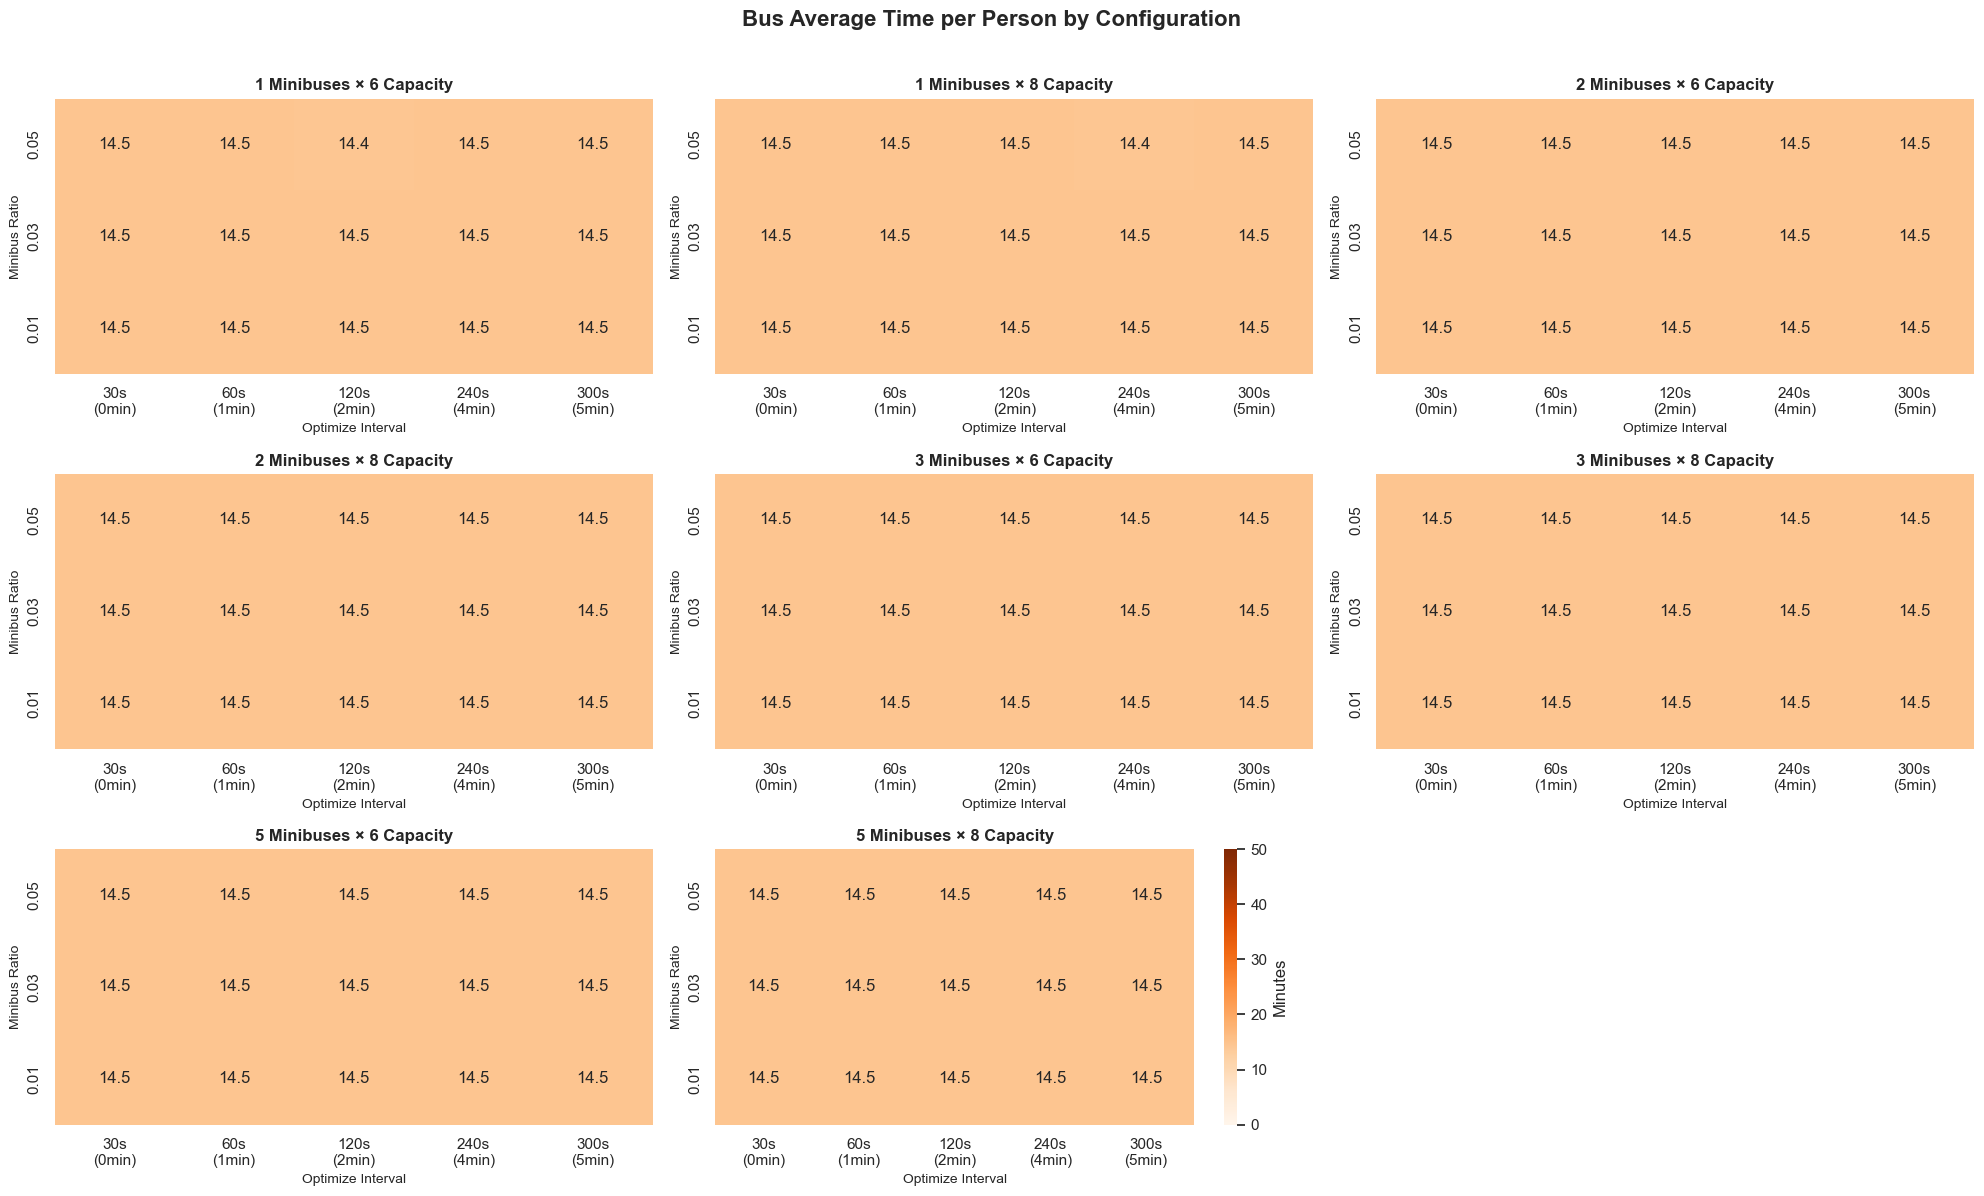

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

# =========================
# 0) Read CSV
# =========================
df = pd.read_csv('batch_results/Minibus_ratio_results_pre/experiment_summary.csv')

# Check if optimization_interval column exists
if 'optimization_interval' not in df.columns:
    print("Warning: 'optimization_interval' column not found. Using original visualization.")
    has_optimize_interval = False
else:
    has_optimize_interval = True
    print(f"Found optimization_interval values: {sorted(df['optimization_interval'].unique())}")

# Check if vehicle-specific columns exist
has_vehicle_specific = all(col in df.columns for col in [
    'bus_avg_total_time', 'bus_total_total_time_hours',
    'minibus_avg_total_time', 'minibus_total_total_time_hours'
])

if has_vehicle_specific:
    print("Found vehicle-specific total time columns!")
else:
    print("Warning: Vehicle-specific columns not found in CSV")

# =========================
# 1) Calculate avg time per person (paper-safe metrics)
# =========================
# Bus
if 'bus_total_total_time' in df.columns and 'bus_passenger_count' in df.columns:
    df['bus_avg_time_per_person'] = df['bus_total_total_time'] / df['bus_passenger_count']
    df['bus_avg_time_per_person_minutes'] = df['bus_avg_time_per_person'] / 60
    print("Calculated bus_avg_time_per_person")
else:
    if 'bus_total_total_time_hours' in df.columns and 'bus_passenger_count' in df.columns:
        df['bus_avg_time_per_person_hours'] = df['bus_total_total_time_hours'] / df['bus_passenger_count']
        df['bus_avg_time_per_person_minutes'] = df['bus_avg_time_per_person_hours'] * 60
        print("Calculated bus_avg_time_per_person from hours")

# Minibus
if 'minibus_total_total_time' in df.columns and 'minibus_passenger_count' in df.columns:
    df['minibus_avg_time_per_person'] = df['minibus_total_total_time'] / df['minibus_passenger_count']
    df['minibus_avg_time_per_person_minutes'] = df['minibus_avg_time_per_person'] / 60
    print("Calculated minibus_avg_time_per_person")
else:
    if 'minibus_total_total_time_hours' in df.columns and 'minibus_passenger_count' in df.columns:
        df['minibus_avg_time_per_person_hours'] = df['minibus_total_total_time_hours'] / df['minibus_passenger_count']
        df['minibus_avg_time_per_person_minutes'] = df['minibus_avg_time_per_person_hours'] * 60
        print("Calculated minibus_avg_time_per_person from hours")

# Labels & sorting
df['capacity_label'] = df['num_minibuses'].astype(str) + '×' + df['minibus_capacity'].astype(str)
df['sort_key'] = df['num_minibuses'] * 100 + df['minibus_capacity']

print("\nUnique capacity labels:")
print(df[['num_minibuses', 'minibus_capacity', 'capacity_label', 'sort_key']]
      .drop_duplicates()
      .sort_values('sort_key'))

capacity_configs = df.groupby(['num_minibuses', 'minibus_capacity']).size().index.tolist()

# =========================
# 2) PAPER-SAFE: Global color normalization for each metric
#    (This is what fixes "same numbers but different colors")
# =========================
def safe_minmax(series, pad_ratio=0.02):
    """Return (vmin, vmax) with a small padding to avoid ultra-compressed color range."""
    s = pd.to_numeric(series, errors='coerce').dropna()
    if len(s) == 0:
        return None, None
    vmin, vmax = float(s.min()), float(s.max())
    if np.isclose(vmin, vmax):
        # If truly constant, create a tiny span so colormap is defined.
        eps = 1e-6 if vmin == 0 else abs(vmin) * 1e-6
        return vmin - eps, vmax + eps
    pad = (vmax - vmin) * pad_ratio
    return vmin - pad, vmax + pad

GLOBAL = {}

# Abandoned count (integers)
if 'abandoned_count' in df.columns:
    GLOBAL['abandoned'] = safe_minmax(df['abandoned_count'], pad_ratio=0.0)  # no padding needed for counts
else:
    GLOBAL['abandoned'] = (None, None)

# Bus / Minibus time per person (minutes)
if 'bus_avg_time_per_person_minutes' in df.columns:
    GLOBAL['bus_minutes'] = safe_minmax(df['bus_avg_time_per_person_minutes'], pad_ratio=0.02)
else:
    GLOBAL['bus_minutes'] = (None, None)

if 'minibus_avg_time_per_person_minutes' in df.columns:
    GLOBAL['minibus_minutes'] = safe_minmax(df['minibus_avg_time_per_person_minutes'], pad_ratio=0.02)
else:
    GLOBAL['minibus_minutes'] = (None, None)

# Service rate (assume already in %; if it's 0-1 you can adapt)
if 'service_rate' in df.columns:
    # If service_rate is 0-100 -> keep 0-100
    # If service_rate is 0-1 -> you may want (0,1) or convert to %
    s = pd.to_numeric(df['service_rate'], errors='coerce').dropna()
    if len(s) and s.max() <= 1.01:
        # likely 0-1; keep 0-1 for colorbar
        GLOBAL['service_rate'] = (0.0, 1.0)
        service_fmt = '.2f'
        service_label = 'Rate (0–1)'
    else:
        GLOBAL['service_rate'] = (0.0, 100.0)
        service_fmt = '.1f'
        service_label = '%'
else:
    GLOBAL['service_rate'] = (None, None)
    service_fmt = '.1f'
    service_label = '%'

print("\nGLOBAL NORMALIZATION (paper-safe):")
for k, (a, b) in GLOBAL.items():
    print(f"  {k}: vmin={a}, vmax={b}")

# =========================
# 3) Helper: build pivot + consistent column labels
# =========================
def make_pivot(df_config, value_col):
    pivot = df_config.pivot_table(
        values=value_col,
        index='minibus_ratio',
        columns='optimization_interval',
        aggfunc='mean'
    ).sort_index(axis=1)
    pivot.columns = [f'{int(col)}s\n({int(col // 60)}min)' for col in pivot.columns]
    return pivot

# =========================
# 4) NEW: Abandoned Count — fixed 3×3, all configs (paged)
# =========================
if has_optimize_interval and 'abandoned_count' in df.columns:
    print("\n" + "="*70)
    print("Creating Abandoned Count visualizations (paper-safe)...")
    print("="*70)

    plots_per_fig = 9  # 3 × 3
    total_configs = len(capacity_configs)
    num_figs = math.ceil(total_configs / plots_per_fig)

    # Global vmin/vmax for abandoned_count
    ab_vmin, ab_vmax = GLOBAL['abandoned']

    for fig_idx in range(num_figs):
        fig, axes = plt.subplots(3, 3, figsize=(20, 12))
        fig.suptitle(
            f'Abandoned Passenger Count by Configuration (Page {fig_idx + 1}/{num_figs})',
            fontsize=16, fontweight='bold', y=0.995
        )
        axes = axes.flatten()

        start = fig_idx * plots_per_fig
        end = min(start + plots_per_fig, total_configs)

        for ax_idx, cfg_idx in enumerate(range(start, end)):
            num_minibuses, capacity = capacity_configs[cfg_idx]
            ax = axes[ax_idx]

            df_config = df[
                (df['num_minibuses'] == num_minibuses) &
                (df['minibus_capacity'] == capacity)
            ]

            pivot_abandoned = make_pivot(df_config, 'abandoned_count')

            sns.heatmap(
                pivot_abandoned,
                annot=True,
                fmt='.0f',
                cmap='Reds',
                vmin=ab_vmin, vmax=ab_vmax,          # ✅ paper-safe: global normalization
                ax=ax,
                cbar=(ax_idx == (end - start - 1)),  # only one colorbar per page (optional)
                cbar_kws={'label': 'Count'} if (ax_idx == (end - start - 1)) else None
            )

            ax.set_title(f'{num_minibuses} Minibuses × {capacity} Capacity',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            ax.invert_yaxis()

        # Turn off unused axes
        for j in range(end - start, 9):
            axes[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.985])
# =========================
# 5) NEW: Avg Time per Person (paper-safe)
#     ONLY keep:
#       - Minibus avg time per person
#       - Service rate (with stronger color contrast)
# =========================
if has_optimize_interval and has_vehicle_specific:
    print("\n" + "=" * 70)
    print("Creating Average Time per Person visualizations (paper-safe, simplified)...")
    print("=" * 70)

    mini_vmin, mini_vmax = GLOBAL['minibus_minutes']

    # 🔥 Stronger contrast for service rate:
    # use robust range instead of full 0–100 (or 0–1)
    if 'service_rate' in df.columns:
        s = pd.to_numeric(df['service_rate'], errors='coerce').dropna()
        if len(s):
            srv_vmin = s.quantile(0.05)
            srv_vmax = s.quantile(0.95)
        else:
            srv_vmin, srv_vmax = GLOBAL['service_rate']
    else:
        srv_vmin, srv_vmax = GLOBAL['service_rate']

    for num_minibuses, capacity in capacity_configs:
        df_config = df[
            (df['num_minibuses'] == num_minibuses) &
            (df['minibus_capacity'] == capacity)
        ]

        # ⬇️ 现在只有 2 个子图
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.suptitle(
            f'Performance Metrics - {num_minibuses} Minibuses × {capacity} Capacity',
            fontsize=14, fontweight='bold', y=0.995
        )

        # =====================
        # (1) Minibus avg time per person
        # =====================
        ax = axes[0]
        if (
            'minibus_avg_time_per_person_minutes' in df_config.columns and
            df_config['minibus_avg_time_per_person_minutes'].notna().any()
        ):
            pivot = make_pivot(df_config, 'minibus_avg_time_per_person_minutes')

            sns.heatmap(
                pivot,
                annot=True,
                fmt='.1f',
                cmap='YlGnBu',
                vmin=mini_vmin,
                vmax=mini_vmax,
                ax=ax,
                cbar=True,
                cbar_kws={'label': 'Minutes'}
            )

            ax.set_title('Minibus – Avg Time per Person (min)',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, 'Data not available', ha='center', va='center')
            ax.axis('off')

        # =====================
        # (2) Service rate — HIGH CONTRAST
        # =====================
        ax = axes[1]
        if 'service_rate' in df_config.columns and df_config['service_rate'].notna().any():
            pivot = make_pivot(df_config, 'service_rate')

            sns.heatmap(
                pivot,
                annot=True,
                fmt=service_fmt,
                cmap='viridis',              # ✅ 高区分度、论文友好
                vmin=srv_vmin,
                vmax=srv_vmax,
                ax=ax,
                cbar=True,
                cbar_kws={'label': service_label}
            )

            ax.set_title('Service Rate',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            ax.invert_yaxis()
        else:
            ax.text(0.5, 0.5, 'Data not available', ha='center', va='center')
            ax.axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.93])

# =========================
# 5) NEW: Bus Average Time per Person — fixed 3×3, all configs (paged)
# =========================
if has_optimize_interval and 'bus_avg_time_per_person_minutes' in df.columns:
    print("\n" + "=" * 70)
    print("Creating Bus Average Time per Person visualizations (fixed range, no normalization)...")
    print("=" * 70)

    plots_per_fig = 9  # 3 × 3
    total_configs = len(capacity_configs)
    num_figs = math.ceil(total_configs / plots_per_fig)

    # Fixed vmin/vmax for bus_avg_time_per_person_minutes
    bus_vmin, bus_vmax = 0, 50  # Set a large fixed range so all colors are consistent

    for fig_idx in range(num_figs):
        fig, axes = plt.subplots(3, 3, figsize=(20, 12))
        fig.suptitle(
            f'Bus Average Time per Person by Configuration',
            fontsize=16, fontweight='bold', y=0.995
        )
        axes = axes.flatten()

        start = fig_idx * plots_per_fig
        end = min(start + plots_per_fig, total_configs)

        for ax_idx, cfg_idx in enumerate(range(start, end)):
            num_minibuses, capacity = capacity_configs[cfg_idx]
            ax = axes[ax_idx]

            df_config = df[
                (df['num_minibuses'] == num_minibuses) &
                (df['minibus_capacity'] == capacity)
            ]

            pivot_bus_time = make_pivot(df_config, 'bus_avg_time_per_person_minutes')

            sns.heatmap(
                pivot_bus_time,
                annot=True,
                fmt='.1f',
                cmap='Oranges',  # Use 'Oranges' color map (orange shades)
                vmin=bus_vmin, vmax=bus_vmax,  # Fixed range for uniform color appearance
                ax=ax,
                cbar=(ax_idx == (end - start - 1)),  # only one colorbar per page (optional)
                cbar_kws={'label': 'Minutes'} if (ax_idx == (end - start - 1)) else None
            )

            ax.set_title(f'{num_minibuses} Minibuses × {capacity} Capacity',
                         fontsize=12, fontweight='bold')
            ax.set_xlabel('Optimize Interval', fontsize=10)
            ax.set_ylabel('Minibus Ratio', fontsize=10)
            ax.invert_yaxis()

        # Turn off unused axes
        for j in range(end - start, 9):
            axes[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.985])

# =========================
# 6) Summary Statistics (keep yours)
# =========================
print("\n" + "=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

if has_optimize_interval:
    print(f"\nData Overview:")
    print(f"- Capacity combinations: {sorted(df['capacity_label'].unique(), key=lambda x: df[df['capacity_label'] == x]['sort_key'].iloc[0])}")
    print(f"- Minibus Ratios: {sorted(df['minibus_ratio'].unique())}")
    print(f"- Optimize Intervals: {sorted(df['optimization_interval'].unique())} seconds")
    print(f"- Total Experiments: {len(df)}")

    print("\n" + "-" * 70)
    print("BEST CONFIGURATIONS:")
    print("-" * 70)

    if 'bus_avg_time_per_person_minutes' in df.columns:
        best_row = df.loc[df['bus_avg_time_per_person_minutes'].idxmin()]
        print(f"\nLowest Bus Average Time per Person:")
        print(f"  Value: {best_row['bus_avg_time_per_person_minutes']:.2f} minutes")
        print(f"  Configuration: {int(best_row['num_minibuses'])} minibuses × {int(best_row['minibus_capacity'])} capacity")
        print(f"  Ratio: {best_row['minibus_ratio']:.2f}")
        print(f"  Optimize Interval: {int(best_row['optimization_interval'])}s")

print("\n" + "=" * 70)
print("All visualizations generated successfully! (fixed range, no normalization)")
print("=" * 70)

plt.show()

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Config
# =============================
CSV_PATH = "batch_results/Minibus_ratio_results_pre/experiment_summary.csv"

# output filenames
OUT1_PNG, OUT1_PDF = "policy_time_heatmap.png", "policy_time_heatmap.pdf"
OUT2_PNG, OUT2_PDF = "service_rate_heatmap.png", "service_rate_heatmap.pdf"
OUT3_PNG, OUT3_PDF = "abandoned_heatmap.png", "abandoned_heatmap.pdf"
OUT4_PNG, OUT4_PDF = "tradeoff_scatter.png", "tradeoff_scatter.pdf"

# tie-break when minibus avg time ties:
# "larger" => choose larger optimization_interval (more efficient)
# "smaller" => choose smaller optimization_interval (more responsive)
TIE_BREAK_INTERVAL = "larger"

# service rate typically 0-100 (%)
SERVICE_RATE_VMIN, SERVICE_RATE_VMAX = 0, 100

# seaborn style similar to your plots
sns.set_theme(style="white")


def ensure_minibus_avg_time_minutes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has 'minibus_avg_time_per_person_minutes'.
    Priority:
      1) existing minibus_avg_time_per_person_minutes
      2) minibus_total_total_time (seconds) / minibus_passenger_count / 60
      3) minibus_total_total_time_hours / minibus_passenger_count * 60
    """
    if "minibus_avg_time_per_person_minutes" in df.columns:
        return df

    if "minibus_total_total_time" in df.columns and "minibus_passenger_count" in df.columns:
        df["minibus_avg_time_per_person_minutes"] = (
            pd.to_numeric(df["minibus_total_total_time"], errors="coerce")
            / pd.to_numeric(df["minibus_passenger_count"], errors="coerce")
            / 60.0
        )
        return df

    if "minibus_total_total_time_hours" in df.columns and "minibus_passenger_count" in df.columns:
        df["minibus_avg_time_per_person_minutes"] = (
            pd.to_numeric(df["minibus_total_total_time_hours"], errors="coerce")
            / pd.to_numeric(df["minibus_passenger_count"], errors="coerce")
            * 60.0
        )
        return df

    raise ValueError(
        "Cannot compute minibus_avg_time_per_person_minutes.\n"
        "Need one of:\n"
        "  - minibus_avg_time_per_person_minutes\n"
        "  - (minibus_total_total_time AND minibus_passenger_count)\n"
        "  - (minibus_total_total_time_hours AND minibus_passenger_count)"
    )


def format_interval_label(seconds: float) -> str:
    if pd.isna(seconds):
        return ""
    s = int(round(float(seconds)))
    if s >= 60 and s % 60 == 0:
        return f"{s//60}m"
    return f"{s}s"


def save_both(fig, png_path, pdf_path, dpi=320):
    fig.savefig(png_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


def df_to_annot_strings(df_values: pd.DataFrame, fmt: str, na_str: str = "") -> pd.DataFrame:
    """Convert numeric DF to string annotations with NaN -> empty."""
    out = df_values.copy()
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            v = out.iat[r, c]
            if pd.isna(v):
                out.iat[r, c] = na_str
            else:
                out.iat[r, c] = fmt.format(v)
    return out.astype(str)


def main():
    print("[1/9] Load CSV...")
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found at: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
    print(f"    Loaded df: {df.shape}")

    required = [
        "num_minibuses", "minibus_capacity", "minibus_ratio",
        "optimization_interval", "service_rate", "abandoned_count"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}\nAvailable: {list(df.columns)}")

    print("[2/9] Numeric typing + dropna...")
    for c in required:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=required).copy()

    print("[3/9] Ensure minibus avg time (minutes/person)...")
    df = ensure_minibus_avg_time_minutes(df)
    df["minibus_avg_time_per_person_minutes"] = pd.to_numeric(
        df["minibus_avg_time_per_person_minutes"], errors="coerce"
    )
    df = df.dropna(subset=["minibus_avg_time_per_person_minutes"]).copy()

    print("[4/9] Build config labels + sorting...")
    df["capacity_label"] = (
        df["num_minibuses"].astype(int).astype(str)
        + "×"
        + df["minibus_capacity"].astype(int).astype(str)
    )
    df["sort_key"] = df["num_minibuses"].astype(int) * 100 + df["minibus_capacity"].astype(int)

    print("[5/9] Aggregate (config, ratio, interval) means...")
    agg = (
        df.groupby(["capacity_label", "sort_key", "minibus_ratio", "optimization_interval"], as_index=False)
          .agg(
              minibus_time=("minibus_avg_time_per_person_minutes", "mean"),
              service_rate=("service_rate", "mean"),
              abandoned=("abandoned_count", "mean"),
              n_runs=("service_rate", "size")
          )
    )

    print("[6/9] Select policy: interval minimizing minibus_time...")
    if TIE_BREAK_INTERVAL not in {"larger", "smaller"}:
        raise ValueError("TIE_BREAK_INTERVAL must be 'larger' or 'smaller'")
    interval_asc = True if TIE_BREAK_INTERVAL == "smaller" else False

    agg_sorted = agg.sort_values(
        by=["capacity_label", "minibus_ratio", "minibus_time", "optimization_interval"],
        ascending=[True, True, True, interval_asc]
    )
    policy = (
        agg_sorted.groupby(["capacity_label", "sort_key", "minibus_ratio"], as_index=False)
                  .first()
                  .rename(columns={"optimization_interval": "opt_interval"})
    )

    print("[7/9] Build pivots (shared axes)...")
    config_order = (
        policy[["capacity_label", "sort_key"]]
        .drop_duplicates()
        .sort_values("sort_key")["capacity_label"]
        .tolist()
    )
    ratio_order = sorted(policy["minibus_ratio"].unique())

    pivot_interval = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="opt_interval")
              .reindex(index=ratio_order, columns=config_order)
    )
    pivot_time = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="minibus_time")
              .reindex(index=ratio_order, columns=config_order)
    )
    pivot_service = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="service_rate")
              .reindex(index=ratio_order, columns=config_order)
    )
    pivot_aband = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="abandoned")
              .reindex(index=ratio_order, columns=config_order)
    )
    # =============================
    # Plot 1: Minibus avg time heatmap
    # color = avg time, text = avg time
    # =============================
    annot_time = df_to_annot_strings(pivot_time, "{:.2f}")

    fig_w = max(10, 1.2 * len(config_order))
    fig_h = max(6, 0.6 * len(ratio_order))

    fig1, ax1 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_time,
        annot=annot_time,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="white",
        ax=ax1,
        cbar_kws={"label": "Minibus avg time (min/person)"}
    )

    ax1.set_title("Minibus average time per person (policy-optimal)")
    ax1.set_xlabel("Minibus configuration (num × capacity)")
    ax1.set_ylabel("Minibus ratio")
    ax1.invert_yaxis()

    fig1.tight_layout()
    save_both(fig1, OUT1_PNG, OUT1_PDF)
    plt.show()

    # =============================
    # Plot 2: Service rate heatmap (enhanced contrast, paper-safe)
    # =============================
    annot_service = df_to_annot_strings(pivot_service, "{:.1f}")

    sr_min = pivot_service.min().min()
    sr_max = pivot_service.max().max()
    pad = (sr_max - sr_min) * 0.05
    sr_vmin = max(0, sr_min - pad)
    sr_vmax = min(100, sr_max + pad)

    fig2, ax2 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_service,
        annot=annot_service,
        fmt="",
        cmap="RdYlGn",
        vmin=sr_vmin,
        vmax=sr_vmax,
        linewidths=0.5,
        linecolor="white",
        ax=ax2,
        cbar_kws={"label": "Service rate (%)"}
    )

    ax2.set_title("Service rate under the time-optimal policy")
    ax2.set_xlabel("Minibus configuration (num × capacity)")
    ax2.set_ylabel("Minibus ratio")
    ax2.invert_yaxis()

    fig2.tight_layout()
    save_both(fig2, OUT2_PNG, OUT2_PDF)
    plt.show()

    # =============================
    # Plot 3: Abandoned heatmap (color=abandoned, text=abandoned)
    # =============================
    annot_aband = df_to_annot_strings(pivot_aband, "{:.1f}")  # change to "{:.0f}" if you want ints
    fig3, ax3 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_aband,
        annot=annot_aband,
        fmt="",
        cmap="Reds",            # same as your code
        linewidths=0.5,
        linecolor="white",
        ax=ax3,
        cbar_kws={"label": "Abandoned passengers (mean)"}
    )
    ax3.set_title("Abandoned passengers under the time-optimal policy")
    ax3.set_xlabel("Minibus configuration (num × capacity)")
    ax3.set_ylabel("Minibus ratio")
    ax3.invert_yaxis()
    fig3.tight_layout()
    save_both(fig3, OUT3_PNG, OUT3_PDF)
    plt.show()

    # =============================
    # Plot 4: Trade-off scatter (all aggregated points)
    # x=minibus_time, y=service_rate, color=abandoned
    # overlay = policy-selected points
    # =============================
    print("[9/9] Plot 4 trade-off scatter...")
    mapping = df[["capacity_label", "sort_key", "num_minibuses"]].drop_duplicates()
    scatter_df = agg.merge(mapping, on=["capacity_label", "sort_key"], how="left").dropna(subset=["num_minibuses"])
    scatter_df["num_minibuses"] = scatter_df["num_minibuses"].astype(int)

    unique_nums = sorted(scatter_df["num_minibuses"].unique())
    markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
    marker_map = {n: markers[i % len(markers)] for i, n in enumerate(unique_nums)}

    fig4, ax4 = plt.subplots(figsize=(10, 7))
    vmin_ab = np.nanmin(scatter_df["abandoned"].to_numpy())
    vmax_ab = np.nanmax(scatter_df["abandoned"].to_numpy())

    last_sc = None
    for n in unique_nums:
        sub = scatter_df[scatter_df["num_minibuses"] == n]
        last_sc = ax4.scatter(
            sub["minibus_time"],
            sub["service_rate"],
            c=sub["abandoned"],
            vmin=vmin_ab,
            vmax=vmax_ab,
            cmap="viridis",
            marker=marker_map[n],
            s=35,
            alpha=0.85,
            edgecolors="none",
            label=f"{n} minibuses"
        )

    ax4.set_title("Trade-off: time vs service rate (color = abandoned)")
    ax4.set_xlabel("Minibus avg time per person (min)  ↓ better")
    ax4.set_ylabel("Service rate (%)  ↑ better")
    ax4.grid(True, alpha=0.25)
    ax4.legend(title="Marker = #minibuses", loc="best", fontsize=9)

    cbar4 = fig4.colorbar(last_sc, ax=ax4)
    cbar4.set_label("Abandoned (mean)  ↓ better")

    # overlay policy-selected points
    policy_key = policy[["capacity_label", "sort_key", "minibus_ratio", "opt_interval"]].copy()
    overlay = scatter_df.merge(policy_key, on=["capacity_label", "sort_key", "minibus_ratio"], how="inner")
    overlay = overlay[overlay["optimization_interval"] == overlay["opt_interval"]]

    ax4.scatter(
        overlay["minibus_time"],
        overlay["service_rate"],
        facecolors="none",
        edgecolors="black",
        linewidths=1.0,
        s=90
    )

    fig4.tight_layout()
    save_both(fig4, OUT4_PNG, OUT4_PDF)
    plt.show()


if __name__ == "__main__":
    main()

[1/9] Load CSV...


FileNotFoundError: CSV not found at: batch_results/Minibus_ratio_results_pre/experiment_summary.csv

[1/9] Load CSV...
    Loaded df: (200, 33)
[2/9] Numeric typing + dropna...
[3/9] Ensure minibus avg time (minutes/person)...
[4/9] Build config labels + sorting...
[5/9] Aggregate (config, ratio, interval) means...
[6/9] Select policy: interval minimizing minibus_time...
[7/9] Build pivots (shared axes)...


/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.75' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.75' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '12.38' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r,

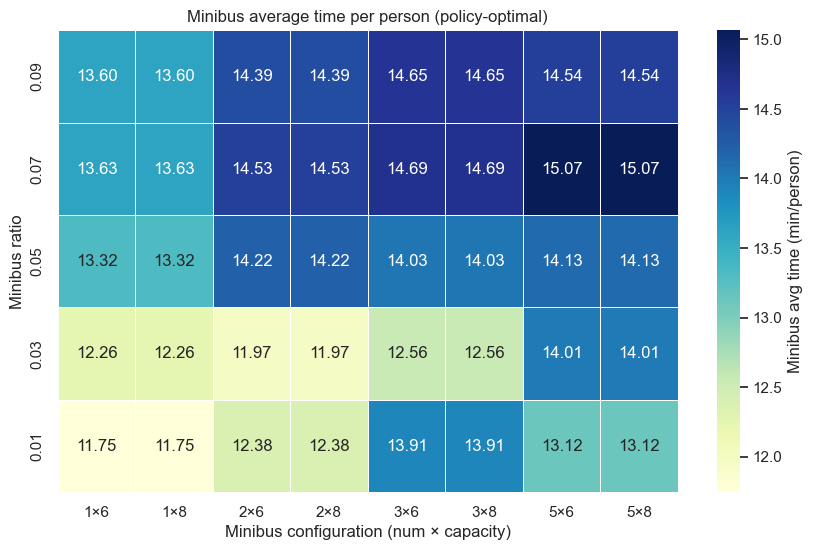

/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '94.5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '94.5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '94.5' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c]

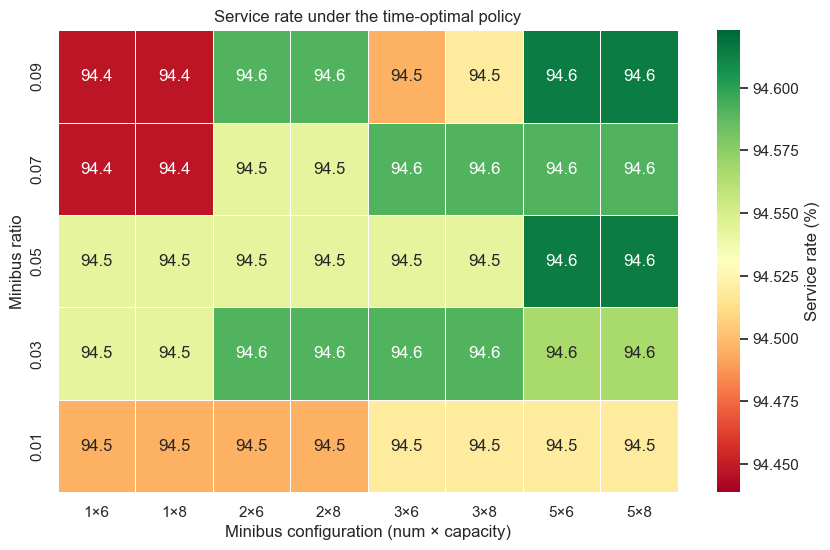

/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '229.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '229.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '229.0' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r,

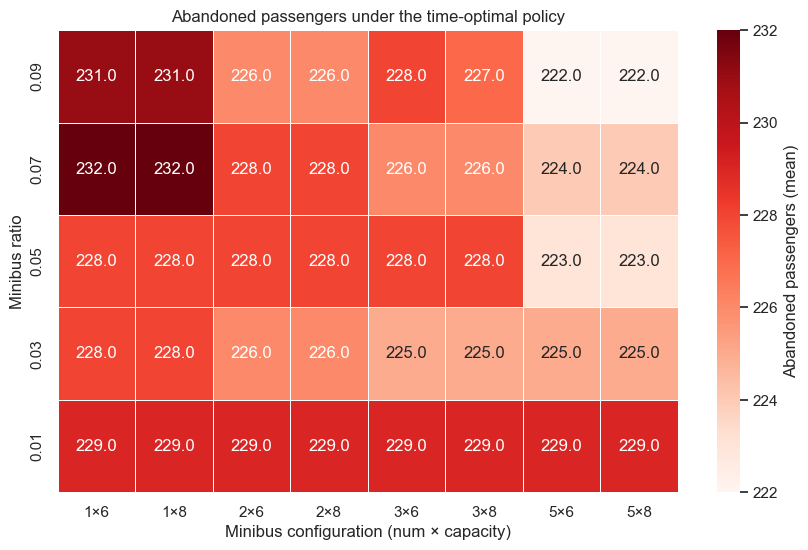

/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.50' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.50' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '14.50' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r,

[8/9] Ensure bus avg time (minutes/person)...


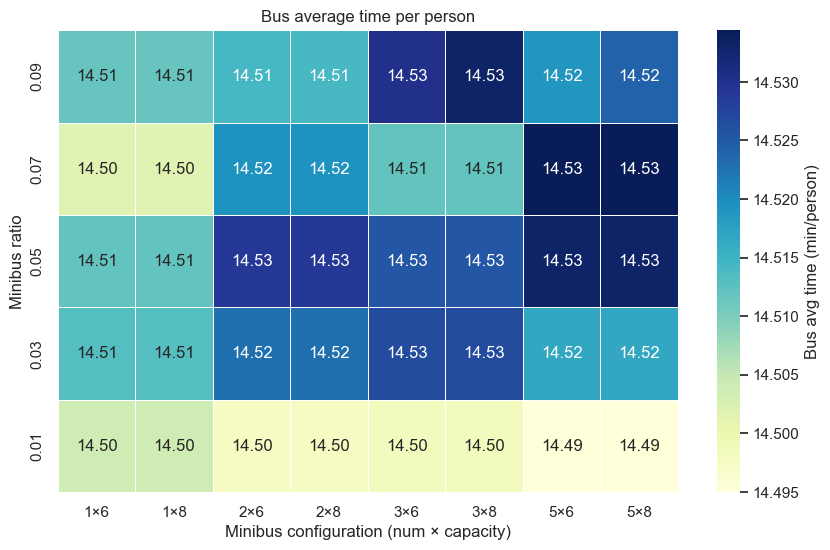

[9/9] Minibus passengers served heatmap...


/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt.format(v)
/var/folders/58/tx0yktsx2rn9t9y3z4q7lcmc0000gn/T/ipykernel_26018/3023825624.py:78: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '22' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.iat[r, c] = fmt

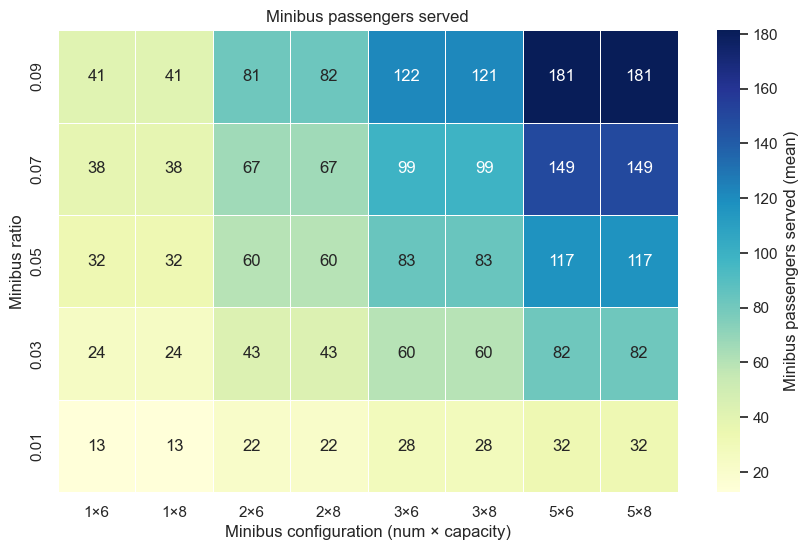

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Config
# =============================
CSV_PATH = "batch_results/Minibus_ratio_results/experiment_summary.csv"

# tie-break when minibus avg time ties:
# "larger" => choose larger optimization_interval (more efficient)
# "smaller" => choose smaller optimization_interval (more responsive)
TIE_BREAK_INTERVAL = "larger"

# service rate typically 0-100 (%)
SERVICE_RATE_VMIN, SERVICE_RATE_VMAX = 0, 100

# seaborn style similar to your plots
sns.set_theme(style="white")


def ensure_minibus_avg_time_minutes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has 'minibus_avg_time_per_person_minutes'.
    Priority:
      1) existing minibus_avg_time_per_person_minutes
      2) minibus_total_total_time (seconds) / minibus_passenger_count / 60
      3) minibus_total_total_time_hours / minibus_passenger_count * 60
    """
    if "minibus_avg_time_per_person_minutes" in df.columns:
        return df

    if "minibus_total_total_time" in df.columns and "minibus_passenger_count" in df.columns:
        df["minibus_avg_time_per_person_minutes"] = (
            pd.to_numeric(df["minibus_total_total_time"], errors="coerce")
            / pd.to_numeric(df["minibus_passenger_count"], errors="coerce")
            / 60.0
        )
        return df

    if "minibus_total_total_time_hours" in df.columns and "minibus_passenger_count" in df.columns:
        df["minibus_avg_time_per_person_minutes"] = (
            pd.to_numeric(df["minibus_total_total_time_hours"], errors="coerce")
            / pd.to_numeric(df["minibus_passenger_count"], errors="coerce")
            * 60.0
        )
        return df

    raise ValueError(
        "Cannot compute minibus_avg_time_per_person_minutes.\n"
        "Need one of:\n"
        "  - minibus_avg_time_per_person_minutes\n"
        "  - (minibus_total_total_time AND minibus_passenger_count)\n"
        "  - (minibus_total_total_time_hours AND minibus_passenger_count)"
    )


def format_interval_label(seconds: float) -> str:
    if pd.isna(seconds):
        return ""
    s = int(round(float(seconds)))
    if s >= 60 and s % 60 == 0:
        return f"{s//60}m"
    return f"{s}s"


def df_to_annot_strings(df_values: pd.DataFrame, fmt: str, na_str: str = "") -> pd.DataFrame:
    """Convert numeric DF to string annotations with NaN -> empty."""
    out = df_values.copy()
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            v = out.iat[r, c]
            if pd.isna(v):
                out.iat[r, c] = na_str
            else:
                out.iat[r, c] = fmt.format(v)
    return out.astype(str)


def main():
    print("[1/9] Load CSV...")
    if not os.path.exists(CSV_PATH):
        raise FileNotFoundError(f"CSV not found at: {CSV_PATH}")
    df = pd.read_csv(CSV_PATH)
    print(f"    Loaded df: {df.shape}")

    required = [
        "num_minibuses", "minibus_capacity", "minibus_ratio",
        "optimization_interval", "service_rate", "abandoned_count"
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}\nAvailable: {list(df.columns)}")

    print("[2/9] Numeric typing + dropna...")
    for c in required:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=required).copy()

    print("[3/9] Ensure minibus avg time (minutes/person)...")
    df = ensure_minibus_avg_time_minutes(df)
    df["minibus_avg_time_per_person_minutes"] = pd.to_numeric(
        df["minibus_avg_time_per_person_minutes"], errors="coerce"
    )
    df = df.dropna(subset=["minibus_avg_time_per_person_minutes"]).copy()

    print("[4/9] Build config labels + sorting...")
    df["capacity_label"] = (
        df["num_minibuses"].astype(int).astype(str)
        + "×"
        + df["minibus_capacity"].astype(int).astype(str)
    )
    df["sort_key"] = df["num_minibuses"].astype(int) * 100 + df["minibus_capacity"].astype(int)

    print("[5/9] Aggregate (config, ratio, interval) means...")
    agg = (
        df.groupby(["capacity_label", "sort_key", "minibus_ratio", "optimization_interval"], as_index=False)
          .agg(
              minibus_time=("minibus_avg_time_per_person_minutes", "mean"),
              service_rate=("service_rate", "mean"),
              abandoned=("abandoned_count", "mean"),
              n_runs=("service_rate", "size")
          )
    )

    print("[6/9] Select policy: interval minimizing minibus_time...")
    if TIE_BREAK_INTERVAL not in {"larger", "smaller"}:
        raise ValueError("TIE_BREAK_INTERVAL must be 'larger' or 'smaller'")
    interval_asc = True if TIE_BREAK_INTERVAL == "smaller" else False

    agg_sorted = agg.sort_values(
        by=["capacity_label", "minibus_ratio", "minibus_time", "optimization_interval"],
        ascending=[True, True, True, interval_asc]
    )
    policy = (
        agg_sorted.groupby(["capacity_label", "sort_key", "minibus_ratio"], as_index=False)
                  .first()
                  .rename(columns={"optimization_interval": "opt_interval"})
    )

    print("[7/9] Build pivots (shared axes)...")
    config_order = (
        policy[["capacity_label", "sort_key"]]
        .drop_duplicates()
        .sort_values("sort_key")["capacity_label"]
        .tolist()
    )
    ratio_order = sorted(policy["minibus_ratio"].unique())

    pivot_interval = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="opt_interval")
              .reindex(index=ratio_order, columns=config_order)
    )
    pivot_time = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="minibus_time")
              .reindex(index=ratio_order, columns=config_order)
    )
    pivot_service = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="service_rate")
              .reindex(index=ratio_order, columns=config_order)
    )
    pivot_aband = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="abandoned")
              .reindex(index=ratio_order, columns=config_order)
    )

    # =============================
    # Plot 1: Minibus avg time heatmap
    # =============================
    annot_time = df_to_annot_strings(pivot_time, "{:.2f}")
    fig_w = max(10, 1.2 * len(config_order))
    fig_h = max(6, 0.6 * len(ratio_order))

    fig1, ax1 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_time,
        annot=annot_time,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="white",
        ax=ax1,
        cbar_kws={"label": "Minibus avg time (min/person)"}
    )

    ax1.set_title("Minibus average time per person (policy-optimal)")
    ax1.set_xlabel("Minibus configuration (num × capacity)")
    ax1.set_ylabel("Minibus ratio")
    ax1.invert_yaxis()
    plt.show()

    # =============================
    # Plot 2: Service rate heatmap (enhanced contrast, paper-safe)
    # =============================
    annot_service = df_to_annot_strings(pivot_service, "{:.1f}")
    sr_min = pivot_service.min().min()
    sr_max = pivot_service.max().max()
    pad = (sr_max - sr_min) * 0.05
    sr_vmin = max(0, sr_min - pad)
    sr_vmax = min(100, sr_max + pad)

    fig2, ax2 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_service,
        annot=annot_service,
        fmt="",
        cmap="RdYlGn",
        vmin=sr_vmin,
        vmax=sr_vmax,
        linewidths=0.5,
        linecolor="white",
        ax=ax2,
        cbar_kws={"label": "Service rate (%)"}
    )

    ax2.set_title("Service rate under the time-optimal policy")
    ax2.set_xlabel("Minibus configuration (num × capacity)")
    ax2.set_ylabel("Minibus ratio")
    ax2.invert_yaxis()
    plt.show()

    # =============================
    # Plot 3: Abandoned heatmap (color=abandoned, text=abandoned)
    # =============================
    annot_aband = df_to_annot_strings(pivot_aband, "{:.1f}")
    fig3, ax3 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_aband,
        annot=annot_aband,
        fmt="",
        cmap="Reds",  # same as your code
        linewidths=0.5,
        linecolor="white",
        ax=ax3,
        cbar_kws={"label": "Abandoned passengers (mean)"}
    )
    ax3.set_title("Abandoned passengers under the time-optimal policy")
    ax3.set_xlabel("Minibus configuration (num × capacity)")
    ax3.set_ylabel("Minibus ratio")
    ax3.invert_yaxis()
    plt.show()

    # =============================
    # Plot 4: Bus avg time heatmap (new)
    # =============================
    print("[8/9] Ensure bus avg time (minutes/person)...")
    if "bus_avg_time_per_person_minutes" not in df.columns:
        if "bus_total_total_time" in df.columns and "bus_passenger_count" in df.columns:
            df["bus_avg_time_per_person_minutes"] = (
                pd.to_numeric(df["bus_total_total_time"], errors="coerce")
                / pd.to_numeric(df["bus_passenger_count"], errors="coerce")
                / 60.0
            )
        elif "bus_total_total_time_hours" in df.columns and "bus_passenger_count" in df.columns:
            df["bus_avg_time_per_person_minutes"] = (
                pd.to_numeric(df["bus_total_total_time_hours"], errors="coerce")
                / pd.to_numeric(df["bus_passenger_count"], errors="coerce")
                * 60.0
            )
        else:
            raise ValueError(
                "Cannot compute bus_avg_time_per_person_minutes.\n"
                "Need one of:\n"
                "  - bus_avg_time_per_person_minutes\n"
                "  - (bus_total_total_time AND bus_passenger_count)\n"
                "  - (bus_total_total_time_hours AND bus_passenger_count)"
            )

    df["bus_avg_time_per_person_minutes"] = pd.to_numeric(
        df["bus_avg_time_per_person_minutes"], errors="coerce"
    )
    df = df.dropna(subset=["bus_avg_time_per_person_minutes"]).copy()

    # Aggregate the data to remove duplicates before pivot
    df_agg = df.groupby(["capacity_label", "minibus_ratio"], as_index=False).agg(
        bus_avg_time=("bus_avg_time_per_person_minutes", "mean")
    )

    pivot_bus_time = (
        df_agg.pivot(index="minibus_ratio", columns="capacity_label", values="bus_avg_time")
          .reindex(index=ratio_order, columns=config_order)
    )

    annot_bus_time = df_to_annot_strings(pivot_bus_time, "{:.2f}")
    fig4, ax4 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_bus_time,
        annot=annot_bus_time,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="white",
        ax=ax4,
        cbar_kws={"label": "Bus avg time (min/person)"}
    )

    ax4.set_title("Bus average time per person")
    ax4.set_xlabel("Minibus configuration (num × capacity)")
    ax4.set_ylabel("Minibus ratio")
    ax4.invert_yaxis()
    plt.show()


    # =============================
    # Plot 5: Minibus passengers served heatmap
    # =============================
    print("[9/9] Minibus passengers served heatmap...")
    df_minibus_count = df.groupby(["capacity_label", "minibus_ratio"], as_index=False).agg(
        minibus_count=("minibus_passenger_count", "mean")
    )

    pivot_minibus_count = (
        df_minibus_count.pivot(index="minibus_ratio", columns="capacity_label", values="minibus_count")
        .reindex(index=ratio_order, columns=config_order)
    )

    annot_minibus_count = df_to_annot_strings(pivot_minibus_count, "{:.0f}")
    fig5, ax5 = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_minibus_count,
        annot=annot_minibus_count,
        fmt="",
        cmap="YlGnBu",
        linewidths=0.5,
        linecolor="white",
        ax=ax5,
        cbar_kws={"label": "Minibus passengers served (mean)"}
    )
    ax5.set_title("Minibus passengers served")
    ax5.set_xlabel("Minibus configuration (num × capacity)")
    ax5.set_ylabel("Minibus ratio")
    ax5.invert_yaxis()
    plt.show()


if __name__ == "__main__":
    main()

Number of passengers who took Minibus: 84
Minibus passenger IDs: ['P22', 'P25', 'P54', 'P61', 'P102', 'P129', 'P150', 'P192', 'P198', 'P293', 'P309', 'P331', 'P354', 'P525', 'P534', 'P553', 'P612', 'P614', 'P708', 'P741', 'P783', 'P845', 'P892', 'P895', 'P958', 'P1038', 'P1059', 'P1108', 'P1109', 'P1162', 'P1282', 'P1328', 'P1336', 'P1369', 'P1387', 'P1402', 'P1528', 'P1597', 'P1599', 'P1628', 'P1711', 'P1809', 'P1821', 'P1945', 'P2101', 'P2105', 'P2493', 'P2507', 'P2540', 'P2620', 'P2651', 'P2668', 'P2707', 'P2749', 'P2892', 'P3009', 'P3040', 'P3061', 'P3131', 'P3188', 'P3236', 'P3237', 'P3290', 'P3431', 'P3442', 'P3456', 'P3491', 'P3495', 'P3561', 'P3588', 'P3594', 'P3632', 'P3650', 'P3657', 'P3793', 'P3819', 'P3841', 'P3855', 'P3963', 'P3972', 'P4025', 'P4028', 'P4140', 'P4142']

Number of matching passengers in bus-only scenario: 84
Passengers who didn't arrive in bus-only scenario: 9

Comparison Results:
   passenger_id  total_time_minibus  total_time_bus   status  time_difference

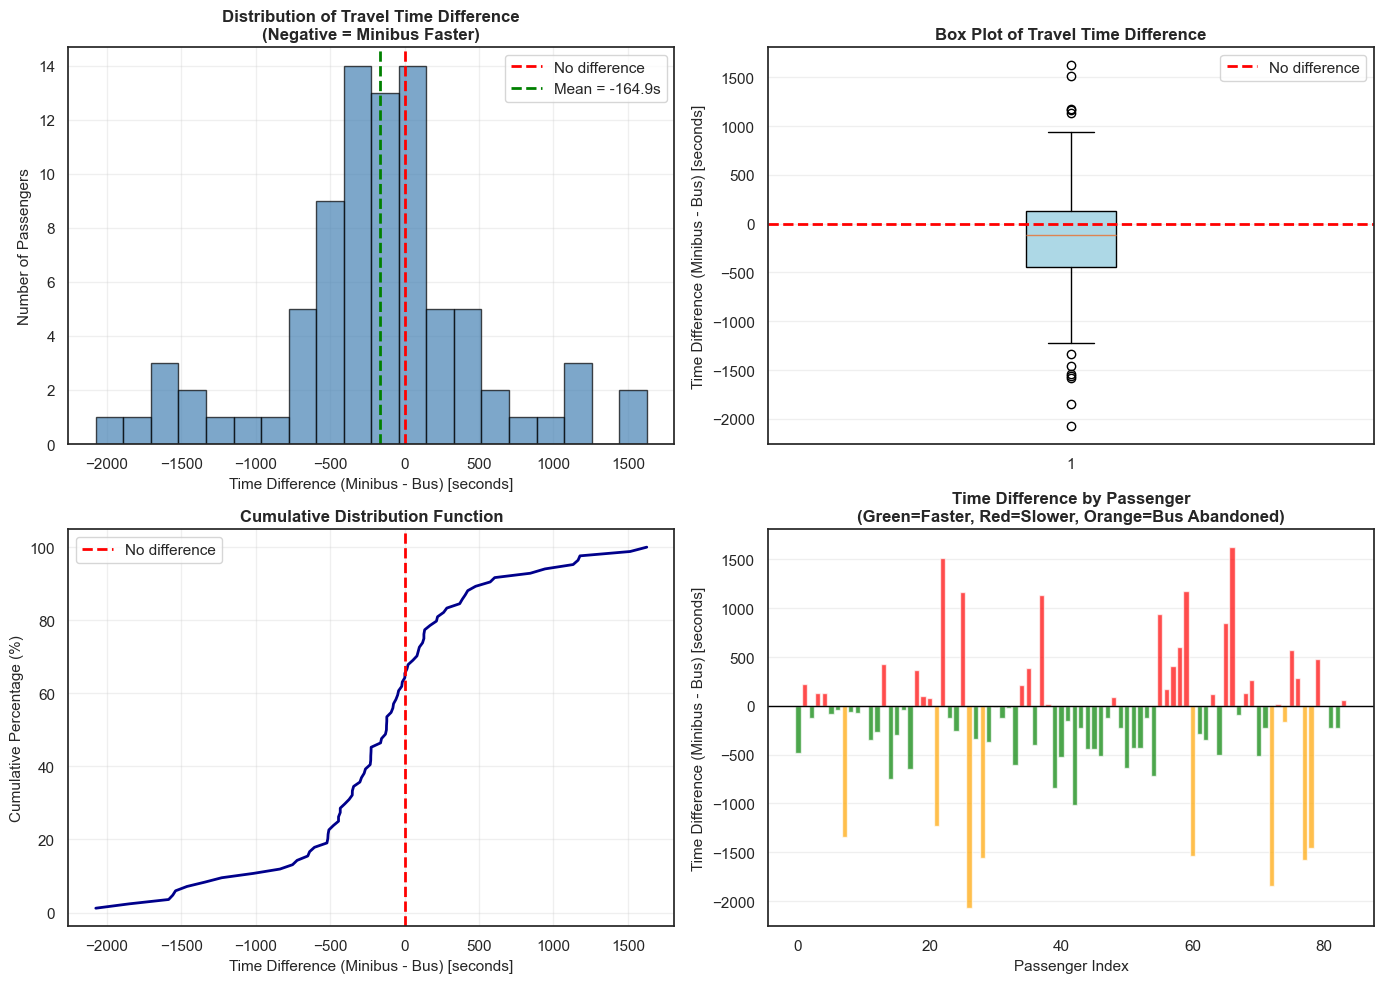


Results saved to 'passenger_time_comparison.csv' and 'minibus_vs_bus_time_comparison.png'


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the two CSV files
bus_only_df = pd.read_csv('bus_simulation_results/passengers.csv')
minibus_df = pd.read_csv('batch_results/Minibus_ratio_results/exp_113_n3_c6_r0.05_opt120/passengers.csv')

# Step 1: From minibus scenario, find passengers who actually took Minibus (not Bus)
minibus_passengers = minibus_df[minibus_df['vehicle_type'] == 'Minibus'].copy()

# Only keep passengers who successfully arrived
minibus_passengers = minibus_passengers[minibus_passengers['status'] == 'ARRIVED'].copy()

# Get the list of passenger IDs who took minibus
minibus_passenger_ids = minibus_passengers['passenger_id'].tolist()

print(f"Number of passengers who took Minibus: {len(minibus_passenger_ids)}")
print(f"Minibus passenger IDs: {minibus_passenger_ids}")

# Step 2: Find these same passengers in the bus-only scenario (regardless of status)
bus_passengers = bus_only_df[
    bus_only_df['passenger_id'].isin(minibus_passenger_ids)
].copy()

# For passengers who did not arrive (ABANDONED), set total_time to 3600
bus_passengers['total_time'] = bus_passengers.apply(
    lambda row:  2400 if row['status'] != 'ARRIVED' else row['total_time'],
    axis=1
)

print(f"\nNumber of matching passengers in bus-only scenario: {len(bus_passengers)}")
print(f"Passengers who didn't arrive in bus-only scenario: {(bus_passengers['status'] != 'ARRIVED').sum()}")

# Step 3: Merge the two dataframes to calculate time difference
# Sort both by passenger_id to ensure correct matching
minibus_passengers = minibus_passengers.sort_values('passenger_id').reset_index(drop=True)
bus_passengers = bus_passengers.sort_values('passenger_id').reset_index(drop=True)

# Create comparison dataframe
comparison_df = pd.merge(
    minibus_passengers[['passenger_id', 'total_time']],
    bus_passengers[['passenger_id', 'total_time', 'status']],
    on='passenger_id',
    suffixes=('_minibus', '_bus')
)

# Calculate time difference: Minibus - Bus
comparison_df['time_difference'] = comparison_df['total_time_minibus'] - comparison_df['total_time_bus']

# Display results
print("\n" + "="*60)
print("Comparison Results:")
print("="*60)
print(comparison_df)
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
print(f"Number of passengers compared: {len(comparison_df)}")
print(f"Passengers who didn't arrive in bus scenario: {(comparison_df['status'] != 'ARRIVED').sum()}")
print(f"Average time difference (Minibus - Bus): {comparison_df['time_difference'].mean():.2f} seconds")
print(f"Median time difference: {comparison_df['time_difference'].median():.2f} seconds")
print(f"Min time difference: {comparison_df['time_difference'].min():.2f} seconds")
print(f"Max time difference: {comparison_df['time_difference'].max():.2f} seconds")
print(f"\nPassengers saved time with minibus: {(comparison_df['time_difference'] < 0).sum()}")
print(f"Passengers lost time with minibus: {(comparison_df['time_difference'] > 0).sum()}")

# Step 4: Plot the distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(comparison_df['time_difference'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[0, 0].axvline(x=comparison_df['time_difference'].mean(), color='green', linestyle='--', linewidth=2, 
                   label=f'Mean = {comparison_df["time_difference"].mean():.1f}s')
axes[0, 0].set_xlabel('Time Difference (Minibus - Bus) [seconds]', fontsize=11)
axes[0, 0].set_ylabel('Number of Passengers', fontsize=11)
axes[0, 0].set_title('Distribution of Travel Time Difference\n(Negative = Minibus Faster)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Box plot
bp = axes[0, 1].boxplot(comparison_df['time_difference'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[0, 1].set_ylabel('Time Difference (Minibus - Bus) [seconds]', fontsize=11)
axes[0, 1].set_title('Box Plot of Travel Time Difference', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Cumulative distribution
sorted_diff = np.sort(comparison_df['time_difference'])
cumulative = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff) * 100
axes[1, 0].plot(sorted_diff, cumulative, linewidth=2, color='darkblue')
axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[1, 0].set_xlabel('Time Difference (Minibus - Bus) [seconds]', fontsize=11)
axes[1, 0].set_ylabel('Cumulative Percentage (%)', fontsize=11)
axes[1, 0].set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bar chart comparing individual passengers
colors = []
for idx, row in comparison_df.iterrows():
    if row['status'] != 'ARRIVED':
        colors.append('orange')  # Orange for passengers who didn't arrive in bus scenario
    elif row['time_difference'] < 0:
        colors.append('green')  # Green for faster with minibus
    else:
        colors.append('red')  # Red for slower with minibus

axes[1, 1].bar(range(len(comparison_df)), comparison_df['time_difference'], 
               color=colors, alpha=0.7)
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1, 1].set_xlabel('Passenger Index', fontsize=11)
axes[1, 1].set_ylabel('Time Difference (Minibus - Bus) [seconds]', fontsize=11)
axes[1, 1].set_title('Time Difference by Passenger\n(Green=Faster, Red=Slower, Orange=Bus Abandoned)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('minibus_vs_bus_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save comparison results
comparison_df.to_csv('passenger_time_comparison.csv', index=False)
print("\n" + "="*60)
print("Results saved to 'passenger_time_comparison.csv' and 'minibus_vs_bus_time_comparison.png'")
print("="*60)

Number of passengers who took Minibus: 84
Minibus passenger IDs: ['P22', 'P25', 'P54', 'P61', 'P102', 'P129', 'P150', 'P192', 'P198', 'P293', 'P309', 'P331', 'P354', 'P525', 'P534', 'P553', 'P612', 'P614', 'P708', 'P741', 'P783', 'P845', 'P892', 'P895', 'P958', 'P1038', 'P1059', 'P1108', 'P1109', 'P1162', 'P1282', 'P1328', 'P1336', 'P1369', 'P1387', 'P1402', 'P1528', 'P1597', 'P1599', 'P1628', 'P1711', 'P1809', 'P1821', 'P1945', 'P2101', 'P2105', 'P2493', 'P2507', 'P2540', 'P2620', 'P2651', 'P2668', 'P2707', 'P2749', 'P2892', 'P3009', 'P3040', 'P3061', 'P3131', 'P3188', 'P3236', 'P3237', 'P3290', 'P3431', 'P3442', 'P3456', 'P3491', 'P3495', 'P3561', 'P3588', 'P3594', 'P3632', 'P3650', 'P3657', 'P3793', 'P3819', 'P3841', 'P3855', 'P3963', 'P3972', 'P4025', 'P4028', 'P4140', 'P4142']

Number of matching passengers in bus-only scenario: 84
Passengers who didn't arrive in bus-only scenario: 9

Comparison Results:
   passenger_id  total_time_minibus  total_time_bus   status  time_difference

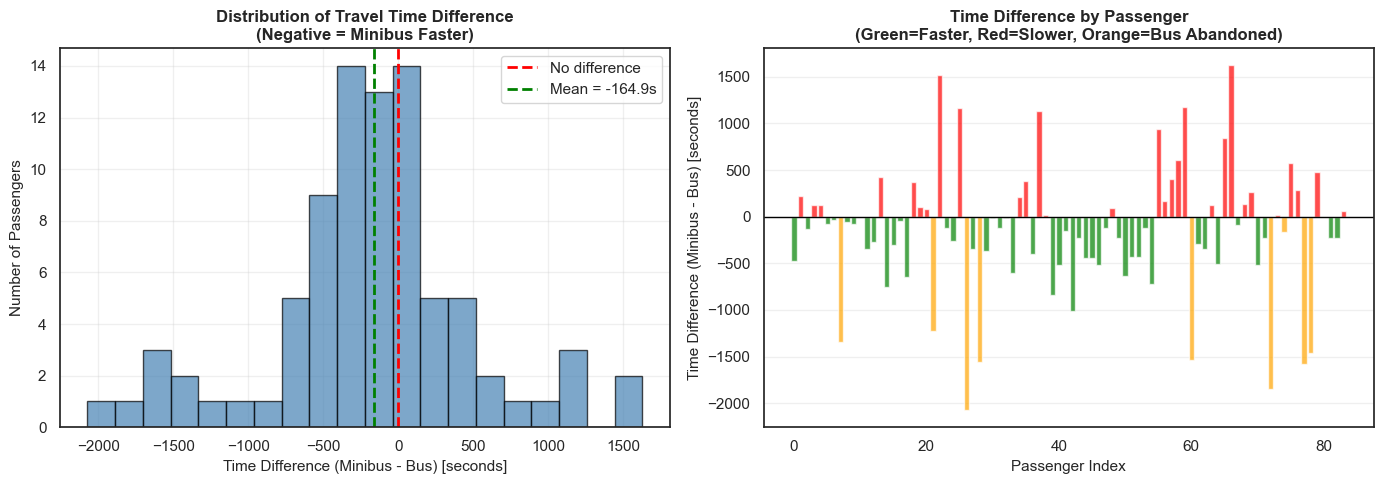


Results saved to 'passenger_time_comparison.csv' and 'minibus_vs_bus_time_comparison.png'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the two CSV files
bus_only_df = pd.read_csv('bus_simulation_results/passengers.csv')
minibus_df = pd.read_csv('batch_results/Minibus_ratio_results/exp_113_n3_c6_r0.05_opt120/passengers.csv')

# Step 1: From minibus scenario, find passengers who actually took Minibus (not Bus)
minibus_passengers = minibus_df[minibus_df['vehicle_type'] == 'Minibus'].copy()
minibus_passengers = minibus_passengers[minibus_passengers['status'] == 'ARRIVED'].copy()
minibus_passenger_ids = minibus_passengers['passenger_id'].tolist()

print(f"Number of passengers who took Minibus: {len(minibus_passenger_ids)}")
print(f"Minibus passenger IDs: {minibus_passenger_ids}")

# Step 2: Find these same passengers in the bus-only scenario
bus_passengers = bus_only_df[
    bus_only_df['passenger_id'].isin(minibus_passenger_ids)
].copy()

bus_passengers['total_time'] = bus_passengers.apply(
    lambda row: 2400 if row['status'] != 'ARRIVED' else row['total_time'],
    axis=1
)

print(f"\nNumber of matching passengers in bus-only scenario: {len(bus_passengers)}")
print(f"Passengers who didn't arrive in bus-only scenario: {(bus_passengers['status'] != 'ARRIVED').sum()}")

# Step 3: Merge the two dataframes
minibus_passengers = minibus_passengers.sort_values('passenger_id').reset_index(drop=True)
bus_passengers = bus_passengers.sort_values('passenger_id').reset_index(drop=True)

comparison_df = pd.merge(
    minibus_passengers[['passenger_id', 'total_time']],
    bus_passengers[['passenger_id', 'total_time', 'status']],
    on='passenger_id',
    suffixes=('_minibus', '_bus')
)

comparison_df['time_difference'] = comparison_df['total_time_minibus'] - comparison_df['total_time_bus']

print("\n" + "="*60)
print("Comparison Results:")
print("="*60)
print(comparison_df)
print("\n" + "="*60)
print("Summary Statistics:")
print("="*60)
print(f"Number of passengers compared: {len(comparison_df)}")
print(f"Passengers who didn't arrive in bus scenario: {(comparison_df['status'] != 'ARRIVED').sum()}")
print(f"Average time difference (Minibus - Bus): {comparison_df['time_difference'].mean():.2f} seconds")
print(f"Median time difference: {comparison_df['time_difference'].median():.2f} seconds")
print(f"Min time difference: {comparison_df['time_difference'].min():.2f} seconds")
print(f"Max time difference: {comparison_df['time_difference'].max():.2f} seconds")
print(f"\nPassengers saved time with minibus: {(comparison_df['time_difference'] < 0).sum()}")
print(f"Passengers lost time with minibus: {(comparison_df['time_difference'] > 0).sum()}")

# Step 4: Plot - only figure 1 and figure 4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (原第一张)
axes[0].hist(comparison_df['time_difference'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[0].axvline(x=comparison_df['time_difference'].mean(), color='green', linestyle='--', linewidth=2,
                label=f'Mean = {comparison_df["time_difference"].mean():.1f}s')
axes[0].set_xlabel('Time Difference (Minibus - Bus) [seconds]', fontsize=11)
axes[0].set_ylabel('Number of Passengers', fontsize=11)
axes[0].set_title('Distribution of Travel Time Difference\n(Negative = Minibus Faster)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart (原第四张)
colors = []
for idx, row in comparison_df.iterrows():
    if row['status'] != 'ARRIVED':
        colors.append('orange')
    elif row['time_difference'] < 0:
        colors.append('green')
    else:
        colors.append('red')

axes[1].bar(range(len(comparison_df)), comparison_df['time_difference'],
            color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Passenger Index', fontsize=11)
axes[1].set_ylabel('Time Difference (Minibus - Bus) [seconds]', fontsize=11)
axes[1].set_title('Time Difference by Passenger\n(Green=Faster, Red=Slower, Orange=Bus Abandoned)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('minibus_vs_bus_time_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save comparison results
comparison_df.to_csv('passenger_time_comparison.csv', index=False)
print("\n" + "="*60)
print("Results saved to 'passenger_time_comparison.csv' and 'minibus_vs_bus_time_comparison.png'")
print("="*60)

[1] Loading bus baseline: bus_simulation_results/passengers.csv
[2] Scanning experiment folders in: batch_results/Minibus_ratio_results
[3] Collected 200 experiment rows.
   num_minibuses  minibus_capacity  minibus_ratio  optimization_interval  \
0              1                 6           0.01                     30   
1              1                 6           0.01                     60   
2              1                 6           0.01                    120   
3              1                 6           0.01                    240   
4              1                 6           0.01                    300   

   total_saved_minutes  n_minibus_passengers  
0           125.813964                    14  
1           107.903964                    12  
2           109.707298                    13  
3           124.123964                    11  
4           100.667297                    11  


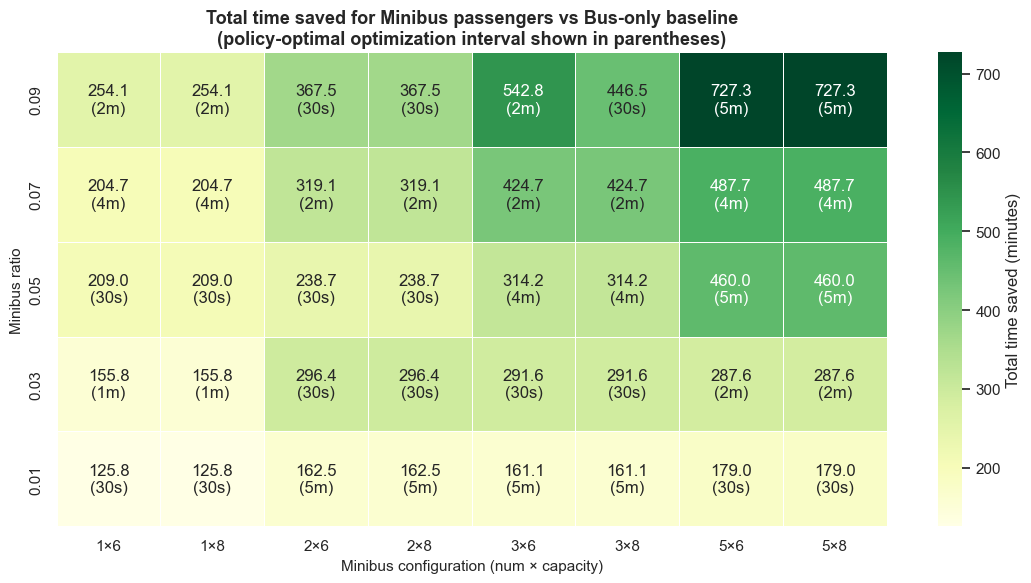

[Done] Saved to time_saved_heatmap.png
[Done] Policy table saved to time_saved_policy.csv


In [10]:
"""
Heatmap: Total time saved for Minibus passengers vs Bus-only baseline
-----------------------------------------------------------------------
For each experiment folder, finds passengers who rode Minibus (ARRIVED),
looks them up in the bus-only baseline, computes:
    time_saved = bus_total_time - minibus_total_time  (seconds)
    (positive = minibus was faster)

Then aggregates to total time saved per experiment,
picks the best optimization_interval per (config, ratio),
and draws a heatmap identical in structure to the second script.
"""

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Config
# =============================
BATCH_DIR   = "batch_results/Minibus_ratio_results"
BUS_CSV     = "bus_simulation_results/passengers.csv"

# When minibus times tie across intervals, prefer larger or smaller interval
TIE_BREAK_INTERVAL = "larger"   # "larger" | "smaller"

# Penalty time (seconds) for passengers who didn't arrive in bus scenario
BUS_NO_ARRIVE_PENALTY = 2400

sns.set_theme(style="white")


# =============================
# Helper: parse folder name
# =============================
EXP_RE = re.compile(
    r"exp_\d+_n(?P<n>\d+)_c(?P<c>\d+)_r(?P<r>[0-9.]+)_opt(?P<opt>\d+)"
)

def parse_exp_folder(name: str):
    m = EXP_RE.fullmatch(name)
    if not m:
        return None
    return dict(
        num_minibuses=int(m.group("n")),
        minibus_capacity=int(m.group("c")),
        minibus_ratio=float(m.group("r")),
        optimization_interval=int(m.group("opt")),
    )


# =============================
# Main
# =============================
def main():
    # --- Load bus baseline ---
    print(f"[1] Loading bus baseline: {BUS_CSV}")
    bus_df = pd.read_csv(BUS_CSV)

    # --- Walk experiment folders ---
    print(f"[2] Scanning experiment folders in: {BATCH_DIR}")
    records = []

    for folder in sorted(os.listdir(BATCH_DIR)):
        meta = parse_exp_folder(folder)
        if meta is None:
            continue

        passengers_csv = os.path.join(BATCH_DIR, folder, "passengers.csv")
        if not os.path.exists(passengers_csv):
            print(f"    [SKIP] no passengers.csv in {folder}")
            continue

        exp_df = pd.read_csv(passengers_csv)

        # Step 1: passengers who actually rode Minibus and arrived
        minibus_p = exp_df[
            (exp_df["vehicle_type"] == "Minibus") & (exp_df["status"] == "ARRIVED")
        ].copy()

        if minibus_p.empty:
            continue

        minibus_ids = minibus_p["passenger_id"].tolist()

        # Step 2: same passengers in bus-only scenario
        bus_match = bus_df[bus_df["passenger_id"].isin(minibus_ids)].copy()
        bus_match["total_time"] = bus_match.apply(
            lambda r: BUS_NO_ARRIVE_PENALTY if r["status"] != "ARRIVED" else r["total_time"],
            axis=1,
        )

        # Step 3: merge & compute time saved
        merged = pd.merge(
            minibus_p[["passenger_id", "total_time"]],
            bus_match[["passenger_id", "total_time"]],
            on="passenger_id",
            suffixes=("_minibus", "_bus"),
        )
        merged["time_saved"] = merged["total_time_bus"] - merged["total_time_minibus"]

        total_saved_seconds = merged["time_saved"].sum()
        total_saved_minutes = total_saved_seconds / 60.0

        records.append({
            **meta,
            "total_saved_minutes": total_saved_minutes,
            "n_minibus_passengers": len(merged),
        })

    if not records:
        raise RuntimeError("No records found. Check BATCH_DIR and BUS_CSV paths.")

    results = pd.DataFrame(records)
    print(f"[3] Collected {len(results)} experiment rows.")
    print(results.head())

    # --- Build config labels ---
    results["capacity_label"] = (
        results["num_minibuses"].astype(int).astype(str)
        + "×"
        + results["minibus_capacity"].astype(int).astype(str)
    )
    results["sort_key"] = results["num_minibuses"] * 100 + results["minibus_capacity"]

    # --- Aggregate over any repeated seeds ---
    agg = (
        results.groupby(
            ["capacity_label", "sort_key", "minibus_ratio", "optimization_interval"],
            as_index=False,
        )
        .agg(total_saved_minutes=("total_saved_minutes", "mean"))
    )

    # --- Select best interval per (config, ratio) ---
    interval_asc = TIE_BREAK_INTERVAL == "smaller"
    agg_sorted = agg.sort_values(
        by=["capacity_label", "minibus_ratio", "total_saved_minutes", "optimization_interval"],
        ascending=[True, True, False, interval_asc],   # descending on saved time (best first)
    )
    policy = (
        agg_sorted.groupby(
            ["capacity_label", "sort_key", "minibus_ratio"], as_index=False
        )
        .first()
        .rename(columns={"optimization_interval": "opt_interval"})
    )

    # --- Pivot ---
    config_order = (
        policy[["capacity_label", "sort_key"]]
        .drop_duplicates()
        .sort_values("sort_key")["capacity_label"]
        .tolist()
    )
    ratio_order = sorted(policy["minibus_ratio"].unique())

    pivot = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="total_saved_minutes")
        .reindex(index=ratio_order, columns=config_order)
    )
    pivot_interval = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="opt_interval")
        .reindex(index=ratio_order, columns=config_order)
    )

    # Annotation: "saved_minutes\n(opt Xs)"
    def make_annot(saved_df, interval_df):
        out = saved_df.copy().astype(object)
        for r in range(saved_df.shape[0]):
            for c in range(saved_df.shape[1]):
                v = saved_df.iat[r, c]
                iv = interval_df.iat[r, c]
                if pd.isna(v):
                    out.iat[r, c] = ""
                else:
                    iv_s = int(iv) if not pd.isna(iv) else "?"
                    iv_label = f"{iv_s//60}m" if iv_s % 60 == 0 and iv_s >= 60 else f"{iv_s}s"
                    out.iat[r, c] = f"{v:.1f}\n({iv_label})"
        return out.astype(str)

    annot = make_annot(pivot, pivot_interval)

    # --- Plot ---
    fig_w = max(10, 1.4 * len(config_order))
    fig_h = max(6, 0.8 * len(ratio_order))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot,
        annot=annot,
        fmt="",
        cmap="YlGn",
        linewidths=0.5,
        linecolor="white",
        ax=ax,
        cbar_kws={"label": "Total time saved (minutes)"},
    )

    ax.set_title(
        "Total time saved for Minibus passengers vs Bus-only baseline\n"
        "(policy-optimal optimization interval shown in parentheses)",
        fontsize=13,
        fontweight="bold",
    )
    ax.set_xlabel("Minibus configuration (num × capacity)", fontsize=11)
    ax.set_ylabel("Minibus ratio", fontsize=11)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig("time_saved_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("[Done] Saved to time_saved_heatmap.png")

    # Also save the policy table
    policy.to_csv("time_saved_policy.csv", index=False)
    print("[Done] Policy table saved to time_saved_policy.csv")


if __name__ == "__main__":
    main()

## Compare different config


In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Config
# =============================
BATCH_DIR = "batch_results"
SUBFOLDERS = [
    "Minibus_ratio_results_bus_pick_when_minibus_not_come",
    "Minibus_ratio_results_detour_150",
    "Minibus_ratio_results_master_thesis",
    "Minibus_ratio_results_minibus_cannot_catch_remove_pending_list_300_detour",
    "Minibus_ratio_results_restrict_waiting_time_everyone",
    "Minibus_ratio_results_waiting_1200_detour_300",
    "Minibus_ratio_results_waiting_1200_detour_600",
]

TIE_BREAK_INTERVAL = "larger"  # "larger" or "smaller"

sns.set_theme(style="white")


def ensure_minibus_avg_time_minutes(df):
    if "minibus_avg_time_per_person_minutes" in df.columns:
        return df
    if "minibus_total_total_time" in df.columns and "minibus_passenger_count" in df.columns:
        df["minibus_avg_time_per_person_minutes"] = (
            pd.to_numeric(df["minibus_total_total_time"], errors="coerce")
            / pd.to_numeric(df["minibus_passenger_count"], errors="coerce")
            / 60.0
        )
        return df
    if "minibus_total_total_time_hours" in df.columns and "minibus_passenger_count" in df.columns:
        df["minibus_avg_time_per_person_minutes"] = (
            pd.to_numeric(df["minibus_total_total_time_hours"], errors="coerce")
            / pd.to_numeric(df["minibus_passenger_count"], errors="coerce")
            * 60.0
        )
        return df
    raise ValueError("Cannot compute minibus_avg_time_per_person_minutes.")


def df_to_annot_strings(df_values, fmt):
    out = df_values.copy().astype(object)
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            v = out.iat[r, c]
            out.iat[r, c] = "" if pd.isna(v) else fmt.format(v)
    return out.astype(str)


def plot_minibus_time(csv_path, title):
    df = pd.read_csv(csv_path)

    required = ["num_minibuses", "minibus_capacity", "minibus_ratio",
                "optimization_interval", "service_rate", "abandoned_count"]
    for c in required:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=required).copy()

    df = ensure_minibus_avg_time_minutes(df)
    df["minibus_avg_time_per_person_minutes"] = pd.to_numeric(
        df["minibus_avg_time_per_person_minutes"], errors="coerce"
    )
    df = df.dropna(subset=["minibus_avg_time_per_person_minutes"]).copy()

    df["capacity_label"] = (
        df["num_minibuses"].astype(int).astype(str) + "×" + df["minibus_capacity"].astype(int).astype(str)
    )
    df["sort_key"] = df["num_minibuses"].astype(int) * 100 + df["minibus_capacity"].astype(int)

    agg = (
        df.groupby(["capacity_label", "sort_key", "minibus_ratio", "optimization_interval"], as_index=False)
          .agg(minibus_time=("minibus_avg_time_per_person_minutes", "mean"))
    )

    interval_asc = TIE_BREAK_INTERVAL == "smaller"
    agg_sorted = agg.sort_values(
        by=["capacity_label", "minibus_ratio", "minibus_time", "optimization_interval"],
        ascending=[True, True, True, interval_asc]
    )
    policy = (
        agg_sorted.groupby(["capacity_label", "sort_key", "minibus_ratio"], as_index=False)
                  .first()
    )

    config_order = (
        policy[["capacity_label", "sort_key"]].drop_duplicates()
        .sort_values("sort_key")["capacity_label"].tolist()
    )
    ratio_order = sorted(policy["minibus_ratio"].unique())

    pivot_time = (
        policy.pivot(index="minibus_ratio", columns="capacity_label", values="minibus_time")
              .reindex(index=ratio_order, columns=config_order)
    )

    annot_time = df_to_annot_strings(pivot_time, "{:.2f}")
    fig_w = max(10, 1.2 * len(config_order))
    fig_h = max(6, 0.6 * len(ratio_order))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot_time, annot=annot_time, fmt="", cmap="YlGnBu",
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"label": "Minibus avg time (min/person)"}
    )
    ax.set_title(f"Minibus avg time per person\n{title}", fontsize=12)
    ax.set_xlabel("Minibus configuration (num × capacity)")
    ax.set_ylabel("Minibus ratio")
    ax.invert_yaxis()
    plt.tight_layout()
    return fig


def main():
    os.makedirs("plots_minibus_time", exist_ok=True)
    for folder in SUBFOLDERS:
        csv_path = os.path.join(BATCH_DIR, folder, "experiment_summary.csv")
        if not os.path.exists(csv_path):
            print(f"[SKIP] Not found: {csv_path}")
            continue
        print(f"[OK] Processing: {folder}")
        fig = plot_minibus_time(csv_path, title=folder)
        out_path = os.path.join("plots_minibus_time", f"{folder}.png")
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"     Saved: {out_path}")

    print("Done.")


if __name__ == "__main__":
    main()

[OK] Processing: Minibus_ratio_results_bus_pick_when_minibus_not_come
     Saved: plots_minibus_time/Minibus_ratio_results_bus_pick_when_minibus_not_come.png
[OK] Processing: Minibus_ratio_results_detour_150
     Saved: plots_minibus_time/Minibus_ratio_results_detour_150.png
[OK] Processing: Minibus_ratio_results_master_thesis
     Saved: plots_minibus_time/Minibus_ratio_results_master_thesis.png
[OK] Processing: Minibus_ratio_results_minibus_cannot_catch_remove_pending_list_300_detour
     Saved: plots_minibus_time/Minibus_ratio_results_minibus_cannot_catch_remove_pending_list_300_detour.png
[OK] Processing: Minibus_ratio_results_restrict_waiting_time_everyone
     Saved: plots_minibus_time/Minibus_ratio_results_restrict_waiting_time_everyone.png
[OK] Processing: Minibus_ratio_results_waiting_1200_detour_300
     Saved: plots_minibus_time/Minibus_ratio_results_waiting_1200_detour_300.png
[OK] Processing: Minibus_ratio_results_waiting_1200_detour_600
     Saved: plots_minibus_time/Mini

In [15]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# Config
# =============================
BATCH_DIR = "batch_results"
SUBFOLDERS = [
    "Minibus_ratio_results_bus_pick_when_minibus_not_come",
    "Minibus_ratio_results_detour_150",
    "Minibus_ratio_results_master_thesis",
    "Minibus_ratio_results_minibus_cannot_catch_remove_pending_list_300_detour",
    "Minibus_ratio_results_restrict_waiting_time_everyone",
    "Minibus_ratio_results_waiting_1200_detour_300",
    "Minibus_ratio_results_waiting_1200_detour_600",
]

sns.set_theme(style="white")


def df_to_annot_strings(df_values, fmt):
    out = df_values.copy().astype(object)
    for r in range(out.shape[0]):
        for c in range(out.shape[1]):
            v = out.iat[r, c]
            out.iat[r, c] = "" if pd.isna(v) else fmt.format(v)
    return out.astype(str)


def plot_minibus_count(csv_path, title):
    df = pd.read_csv(csv_path)

    required = ["num_minibuses", "minibus_capacity", "minibus_ratio", "minibus_passenger_count"]
    for c in required:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=required).copy()

    df["capacity_label"] = (
        df["num_minibuses"].astype(int).astype(str) + "×" + df["minibus_capacity"].astype(int).astype(str)
    )
    df["sort_key"] = df["num_minibuses"].astype(int) * 100 + df["minibus_capacity"].astype(int)

    agg = df.groupby(["capacity_label", "sort_key", "minibus_ratio"], as_index=False).agg(
        minibus_count=("minibus_passenger_count", "mean")
    )

    config_order = (
        agg[["capacity_label", "sort_key"]].drop_duplicates()
        .sort_values("sort_key")["capacity_label"].tolist()
    )
    ratio_order = sorted(agg["minibus_ratio"].unique())

    pivot = (
        agg.pivot(index="minibus_ratio", columns="capacity_label", values="minibus_count")
           .reindex(index=ratio_order, columns=config_order)
    )

    annot = df_to_annot_strings(pivot, "{:.0f}")
    fig_w = max(10, 1.2 * len(config_order))
    fig_h = max(6, 0.6 * len(ratio_order))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        pivot, annot=annot, fmt="", cmap="YlGnBu",
        linewidths=0.5, linecolor="white", ax=ax,
        cbar_kws={"label": "Minibus passengers served (mean)"}
    )
    ax.set_title(f"Minibus passengers served\n{title}", fontsize=12)
    ax.set_xlabel("Minibus configuration (num × capacity)")
    ax.set_ylabel("Minibus ratio")
    ax.invert_yaxis()
    plt.tight_layout()
    return fig


def main():
    os.makedirs("plots_minibus_count", exist_ok=True)
    for folder in SUBFOLDERS:
        csv_path = os.path.join(BATCH_DIR, folder, "experiment_summary.csv")
        if not os.path.exists(csv_path):
            print(f"[SKIP] Not found: {csv_path}")
            continue
        print(f"[OK] Processing: {folder}")
        fig = plot_minibus_count(csv_path, title=folder)
        out_path = os.path.join("plots_minibus_count", f"{folder}.png")
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"     Saved: {out_path}")

    print("Done.")


if __name__ == "__main__":
    main()

[OK] Processing: Minibus_ratio_results_bus_pick_when_minibus_not_come
     Saved: plots_minibus_count/Minibus_ratio_results_bus_pick_when_minibus_not_come.png
[OK] Processing: Minibus_ratio_results_detour_150
     Saved: plots_minibus_count/Minibus_ratio_results_detour_150.png
[OK] Processing: Minibus_ratio_results_master_thesis
     Saved: plots_minibus_count/Minibus_ratio_results_master_thesis.png
[OK] Processing: Minibus_ratio_results_minibus_cannot_catch_remove_pending_list_300_detour
     Saved: plots_minibus_count/Minibus_ratio_results_minibus_cannot_catch_remove_pending_list_300_detour.png
[OK] Processing: Minibus_ratio_results_restrict_waiting_time_everyone
     Saved: plots_minibus_count/Minibus_ratio_results_restrict_waiting_time_everyone.png
[OK] Processing: Minibus_ratio_results_waiting_1200_detour_300
     Saved: plots_minibus_count/Minibus_ratio_results_waiting_1200_detour_300.png
[OK] Processing: Minibus_ratio_results_waiting_1200_detour_600
     Saved: plots_minibus_cou